# Exploratory Data Analysis - PS-S06E08: Predicting Smartphone Addiction

This notebook performs exploratory data analysis (EDA) for **Playground Series – Season 6, Episode 8: Predicting Smartphone Addiction**. The target is `addicted_label` (0 = Not Addicted, 1 = Addicted), and the evaluation metric is **ROC AUC**.

The notebook visualizes feature distributions, analyzes correlation with the target, and profiles the dataset against the test split.

## 1. Approach & Setup

We will follow a structured EDA workflow:
1. **Sweetviz Automated Profiling**: Build interactive HTML profiling reports comparing training and testing datasets. Reports are saved as standalone HTML files for full-page viewing and displayed inline.
2. **Custom Visualizations**: Deep dive into numeric vs. categorical patterns and feature signals using `DataVisualizer`.
3. **Drift Identification**: Inspect KDE plots comparing training and testing splits to identify potential distribution shifts.

### Install Automated Profiling Tools

In [1]:
%pip -q install --upgrade sweetviz

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
import sweetviz as sv
import scipy.stats as st
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e08_experiment_setup import ExperimentSetup
from ps_s06e08_data_visualization import DataVisualizer

# --- Notebook settings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
helper = ExperimentSetup()

# Seed pandas, numpy, and python built-ins
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

TARGET = 'addicted_label'

Random seed set to: 10301
Warnings suppressed.


## 2. Load Datasets

In [4]:
training_df = helper.read_dataset('training')

TRAINING DATASET

   id    age  daily_screen_time_hours  social_media_hours  gaming_hours  \
0   0 24.000                      NaN               1.830         1.590   
1   1 19.000                    5.970               1.080           NaN   
2   2 18.000                    5.090                 NaN           NaN   
3   3 21.000                    6.420               1.260         1.420   
4   4 26.000                   11.200               1.870         2.810   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0             2.110        7.460                122.000             38.000   
1             3.030        8.220                 76.000             19.000   
2               NaN        6.250                134.000             60.000   
3             3.360        8.850                112.000             94.000   
4             1.950        5.250                    NaN                NaN   

   weekend_screen_time  gender stress_level academic_work_impa

### Target Class Distribution Insights

* **Imbalance**: The target `addicted_label` is notably imbalanced:
  * **Addicted (1)**: ~70.9%
  * **Not Addicted (0)**: ~29.1%
* **Implication**: Since the majority class is 70.9%, baseline accuracy is high. We evaluate using **ROC AUC**, which focuses on the ranking of probabilities rather than hard thresholds. However, class imbalance makes Stratified K-Fold cross-validation a strict requirement to keep fold ratios consistent.

In [5]:
test_df = helper.read_dataset('test')

TEST DATASET

       id    age  daily_screen_time_hours  social_media_hours  gaming_hours  \
0  691369 30.000                    9.340                 NaN         0.770   
1  691370    NaN                      NaN               1.910           NaN   
2  691371 26.000                    8.480               3.640           NaN   
3  691372 20.000                    8.370               2.990         1.690   
4  691373 25.000                    8.250               4.020         1.210   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0             4.090        7.150                153.000             16.000   
1             1.200        8.670                239.000            148.000   
2             3.390        7.470                106.000            123.000   
3             2.530        5.450                178.000             55.000   
4             2.320        8.460                 63.000             86.000   

   weekend_screen_time  gender stress_leve

## 3. Sweetviz Automated Reports

### Train vs Test Comparison

Generates a comparison report to spot any feature distribution drift between training and testing sets. 
*(Saved locally as [sweetviz_train_test.html](sweetviz_train_test.html) for full browser display)*

                                             |                                                                …

Report sweetviz_train_test.html was generated.



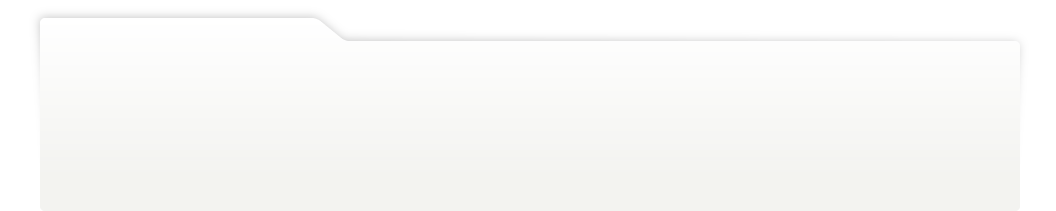
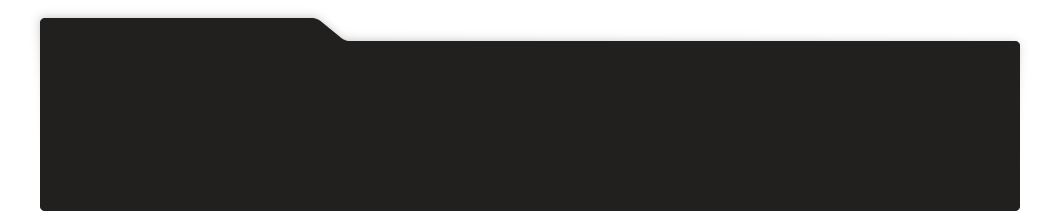
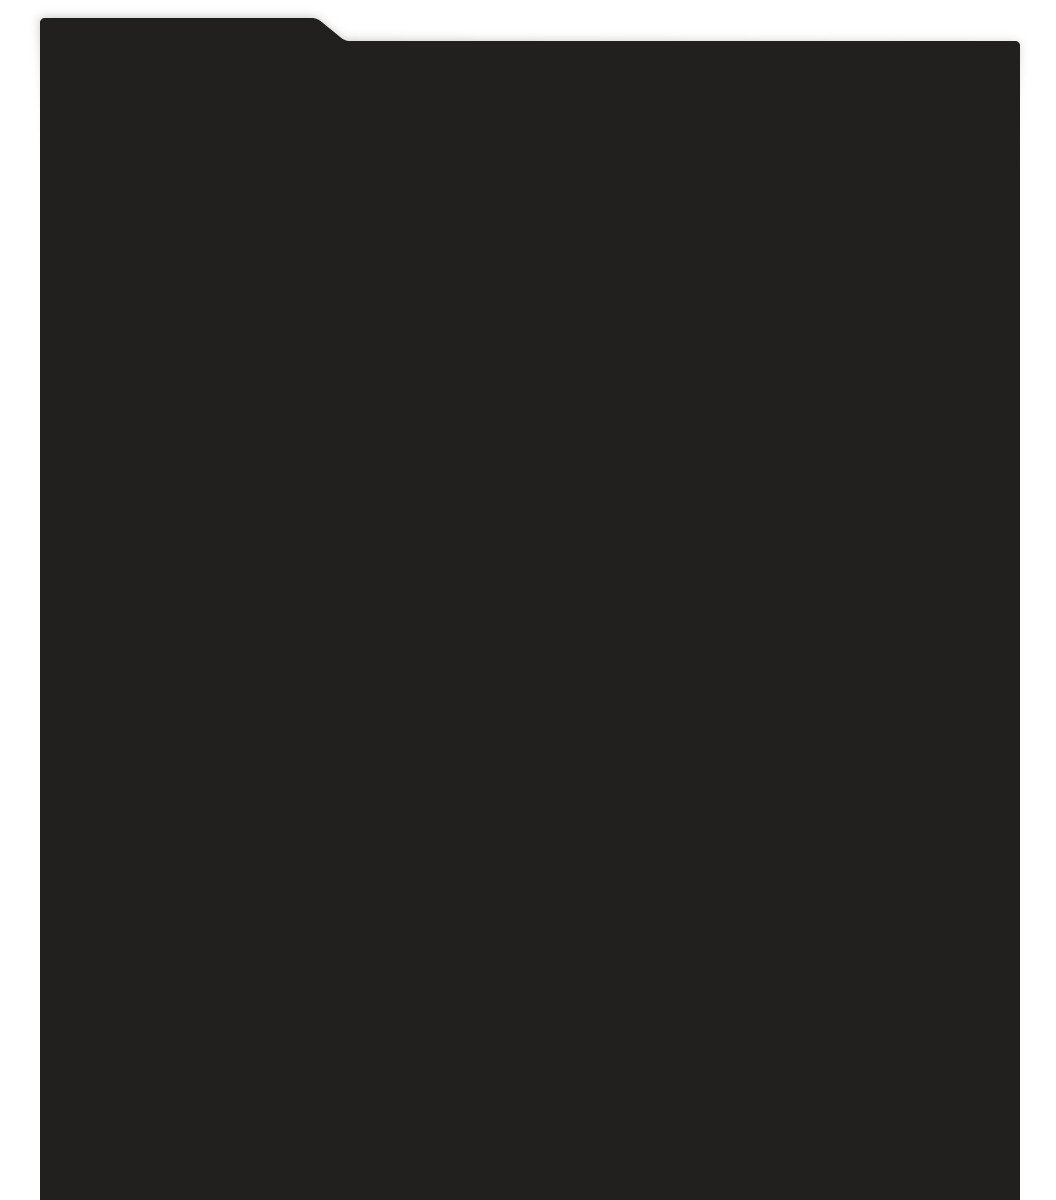
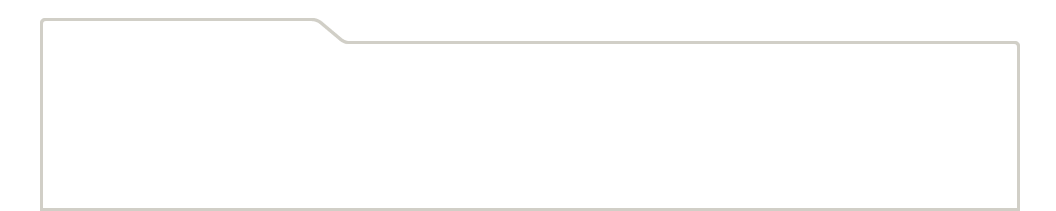
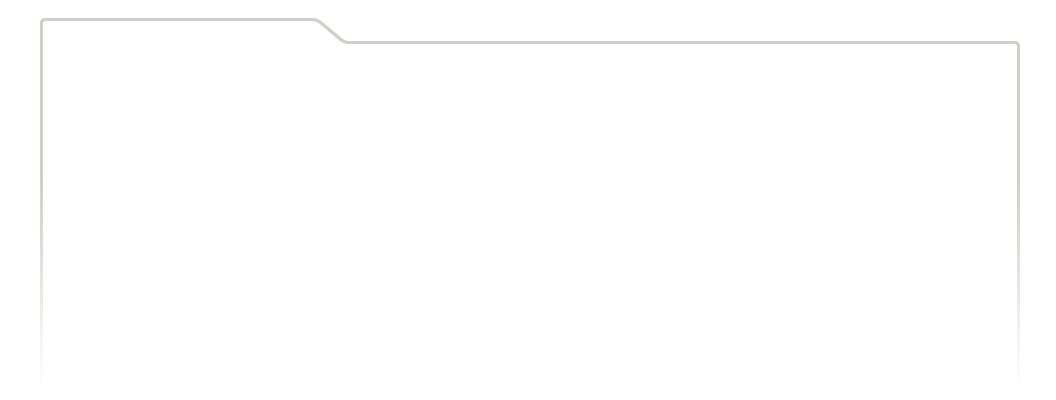
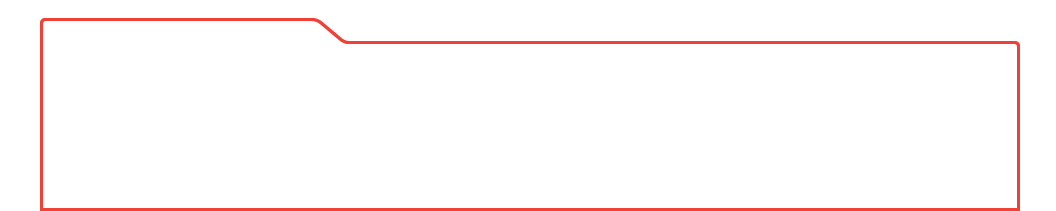
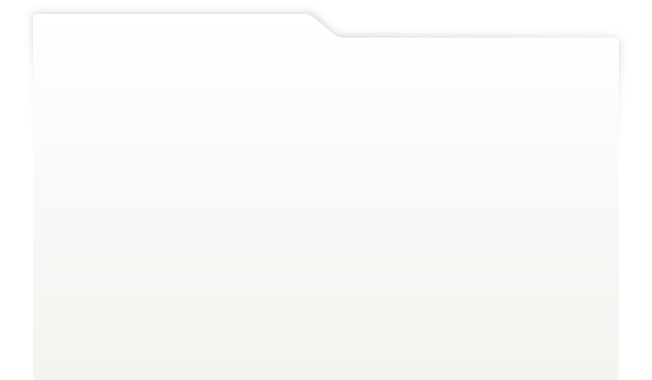
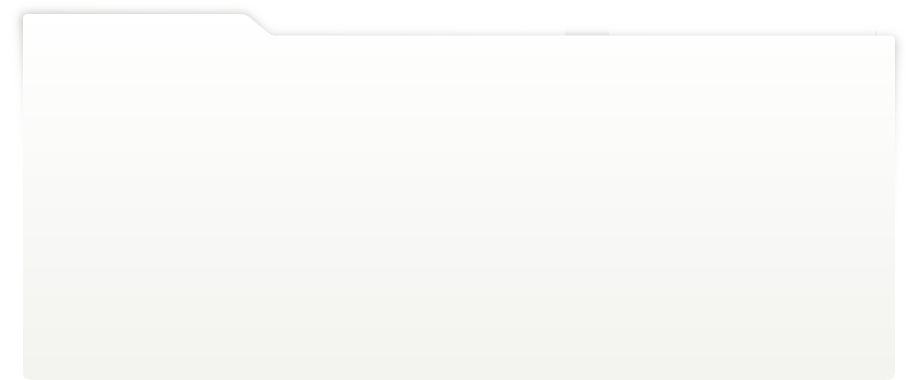
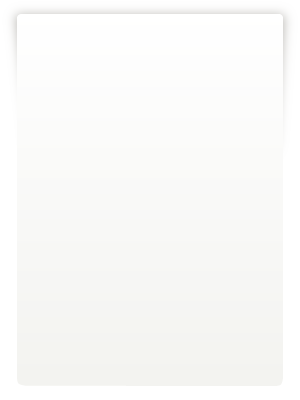
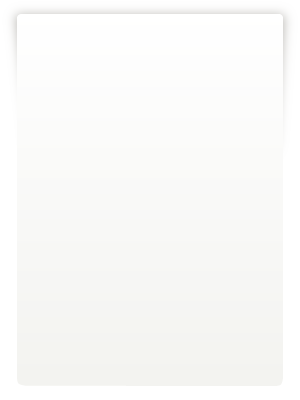
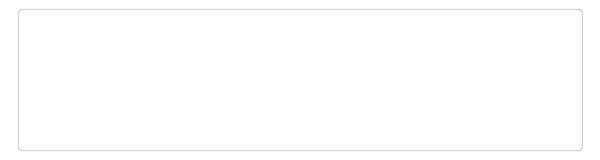
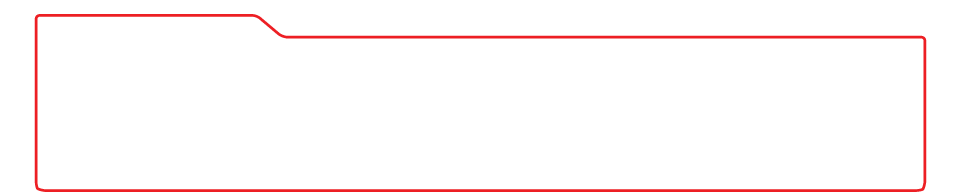
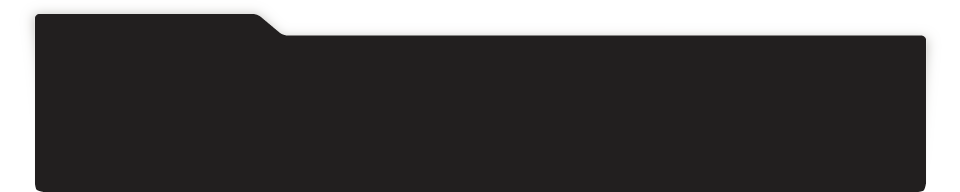
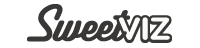
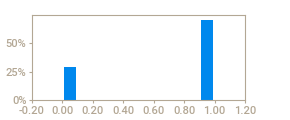
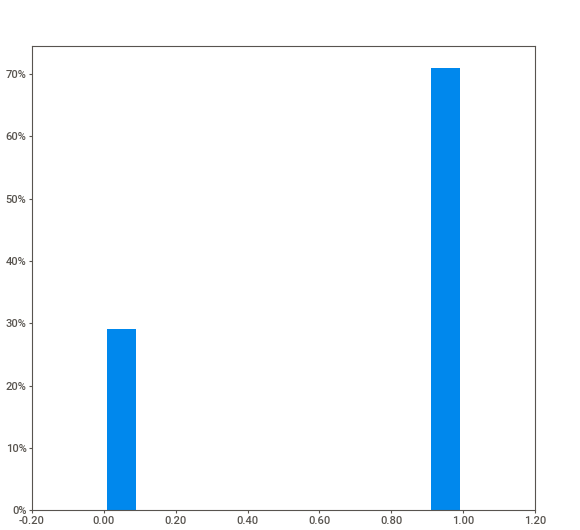
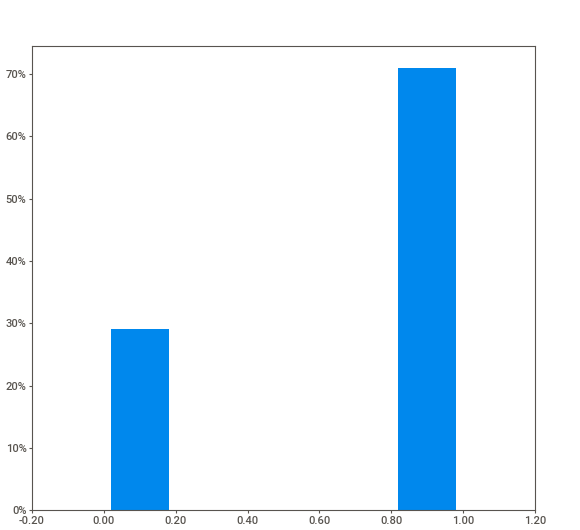
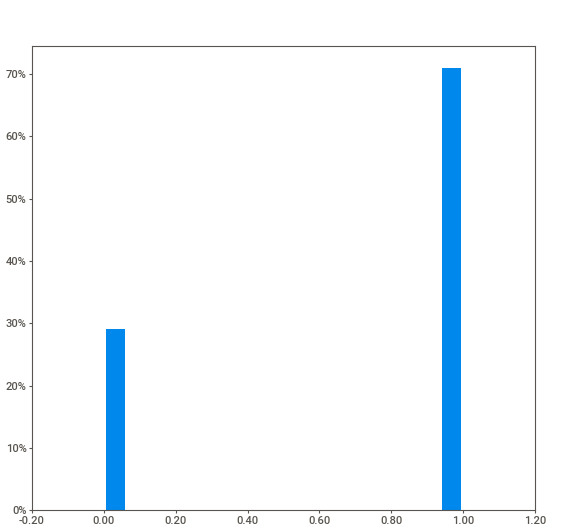
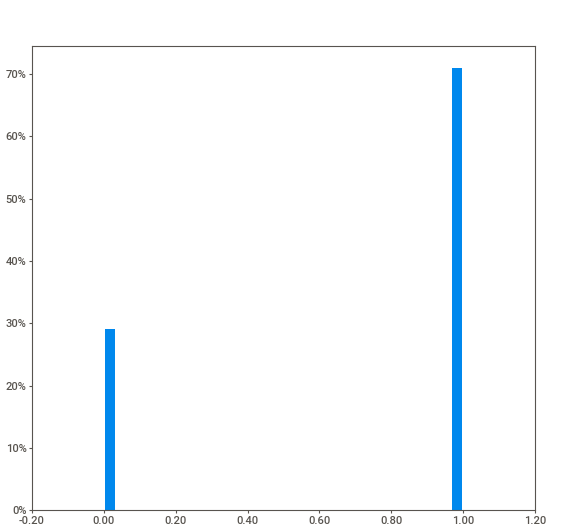
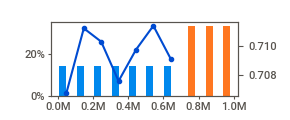
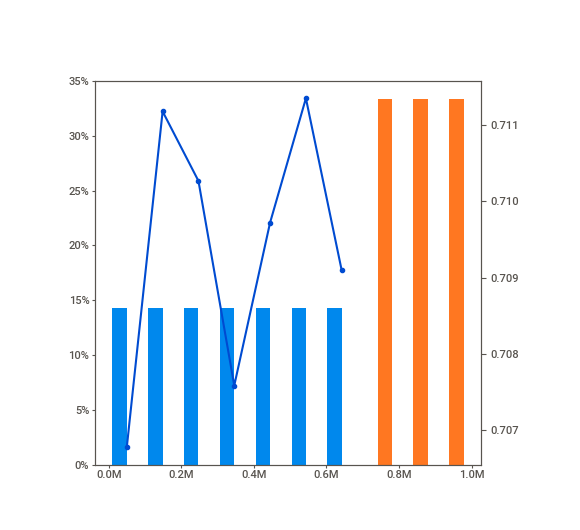
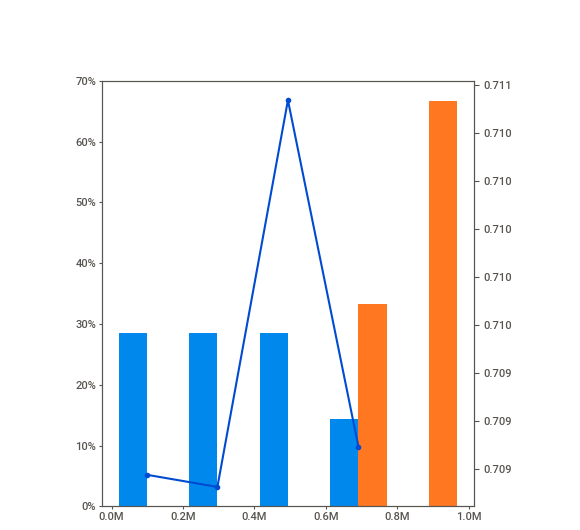
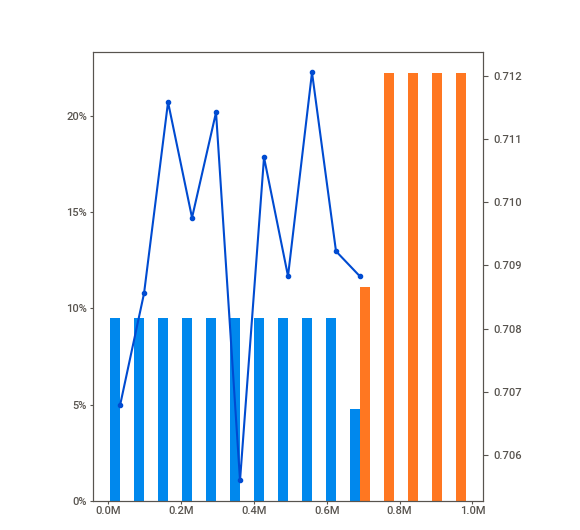
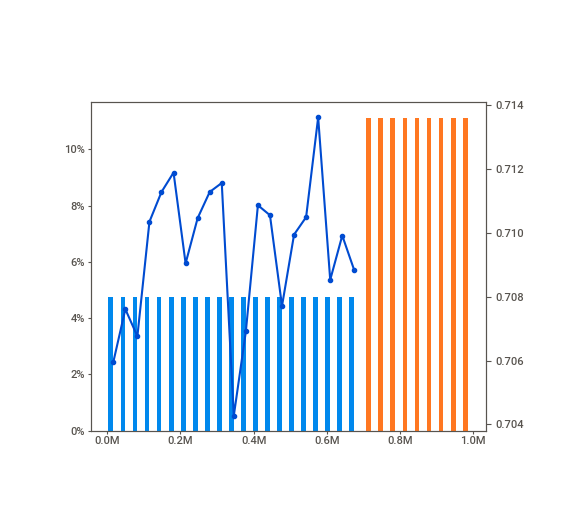
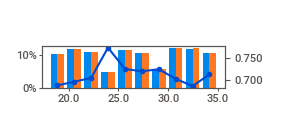
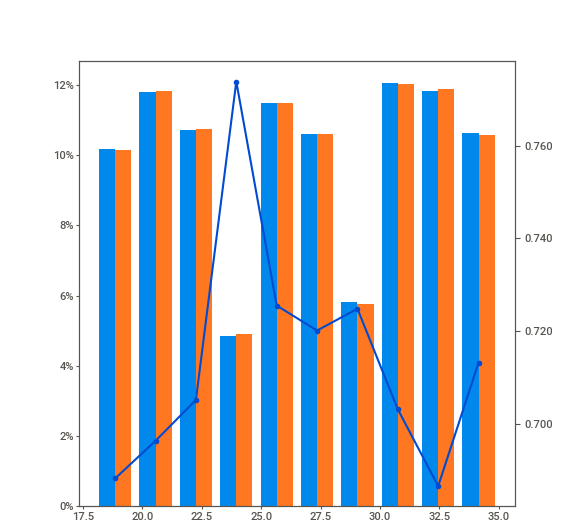
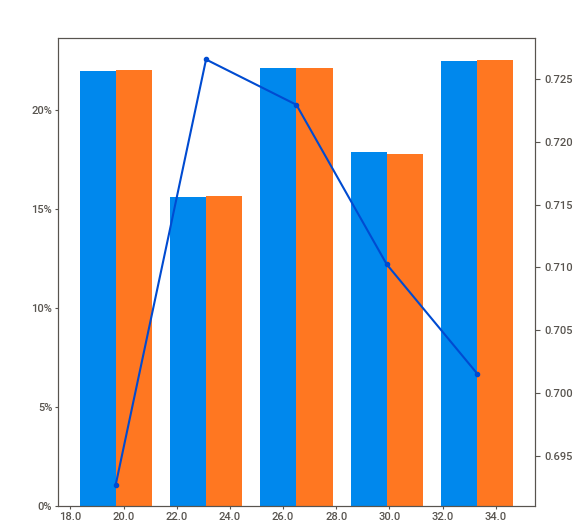
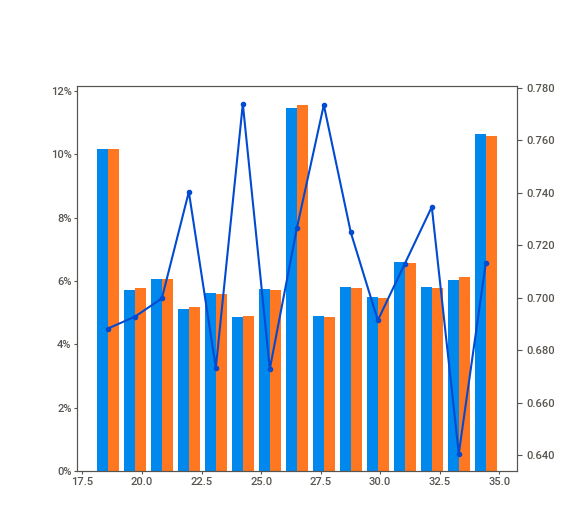
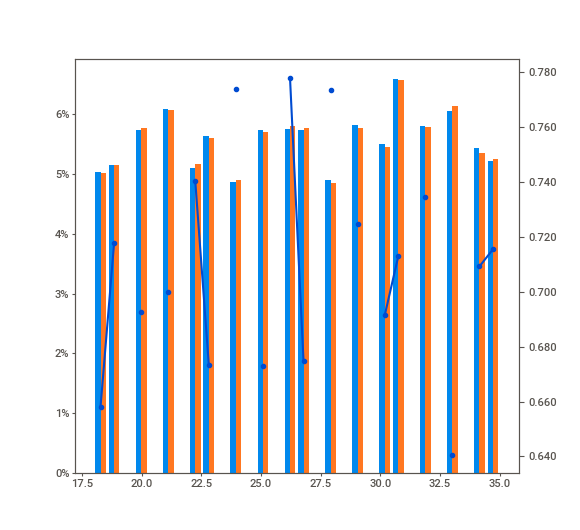
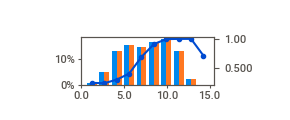
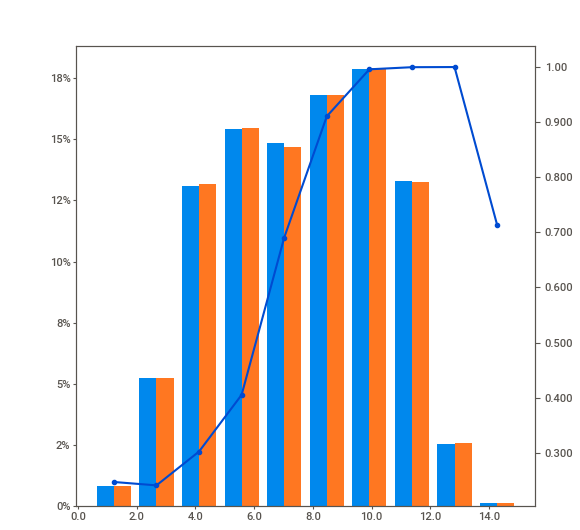
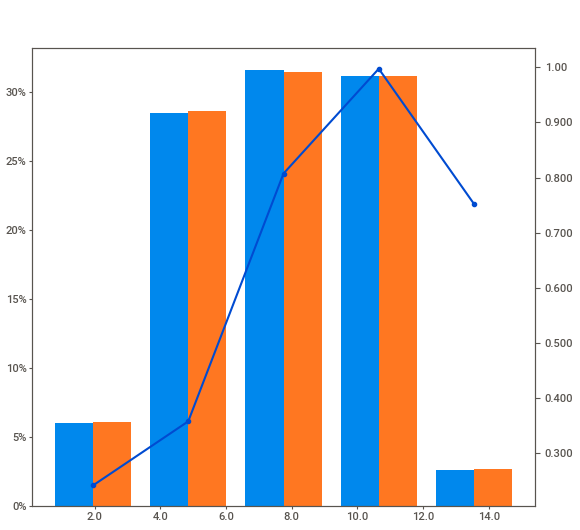
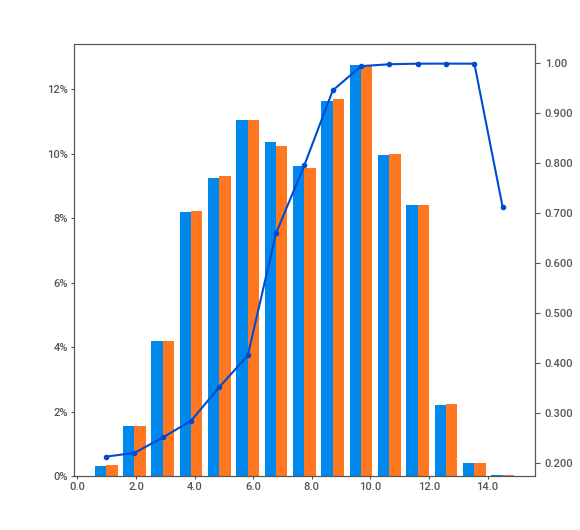
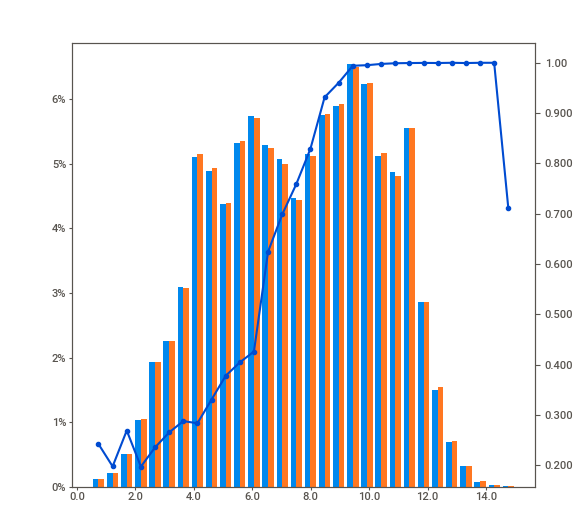
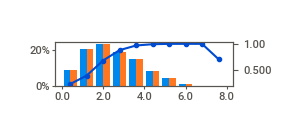
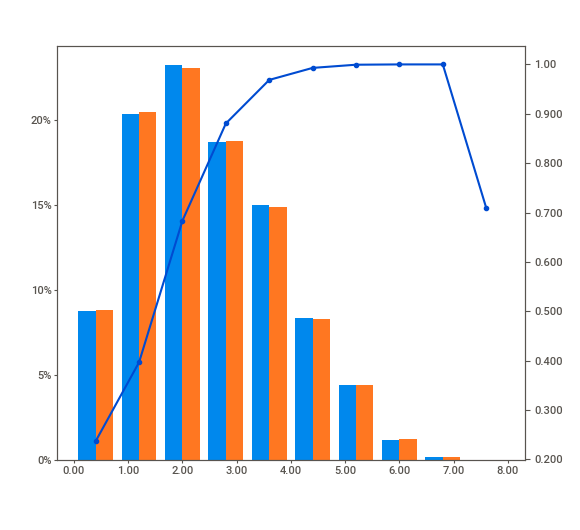
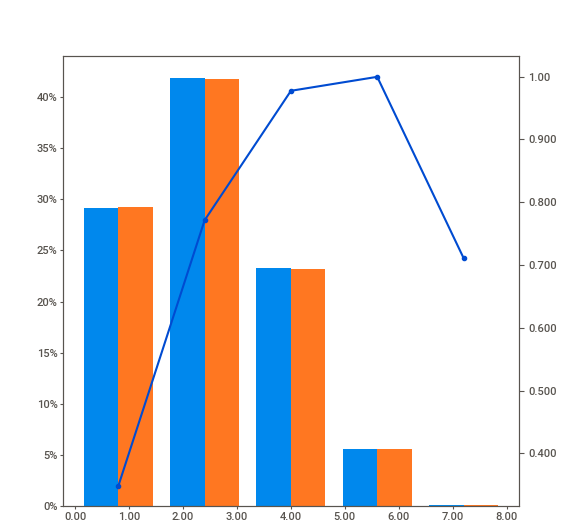
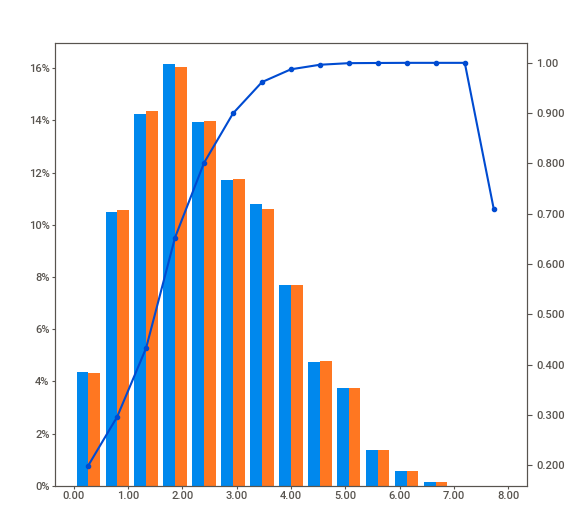
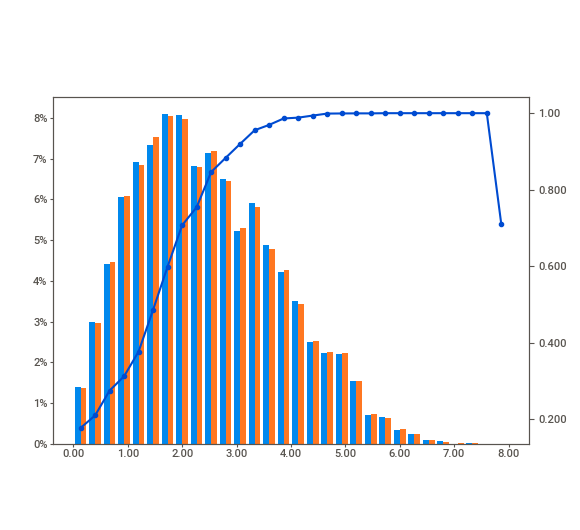
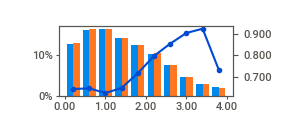
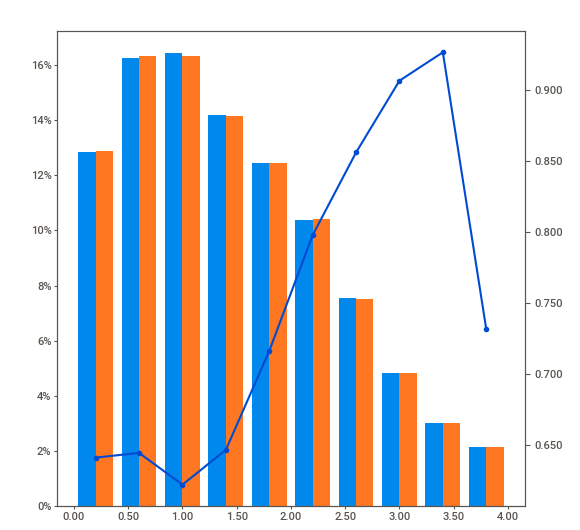
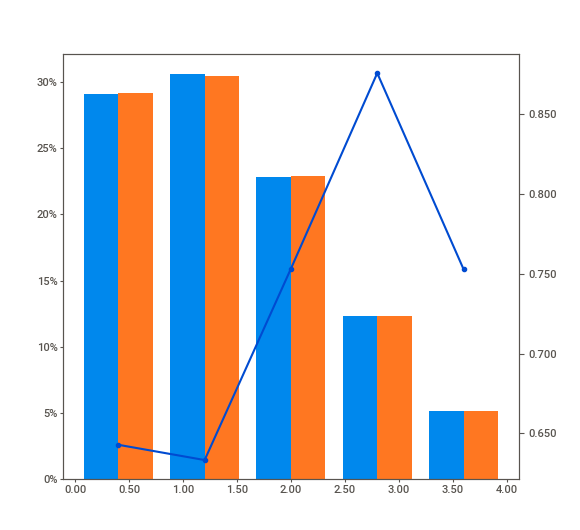
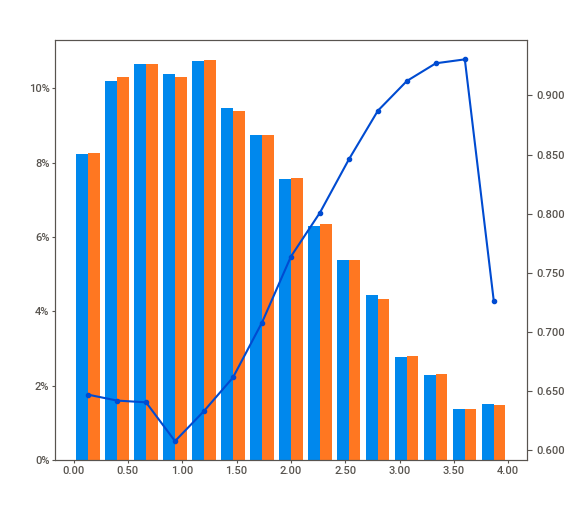
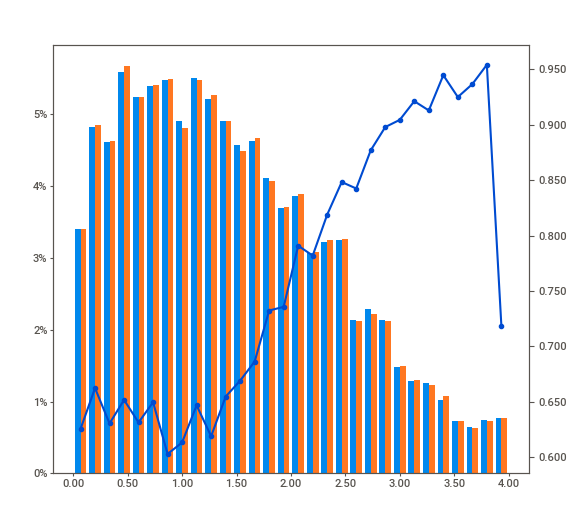
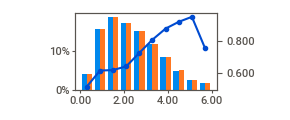
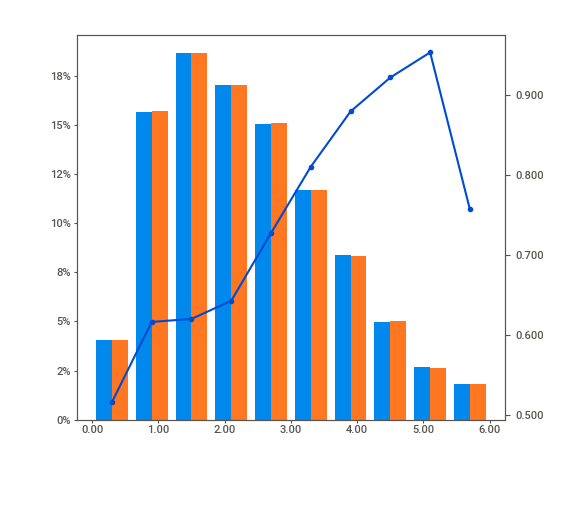
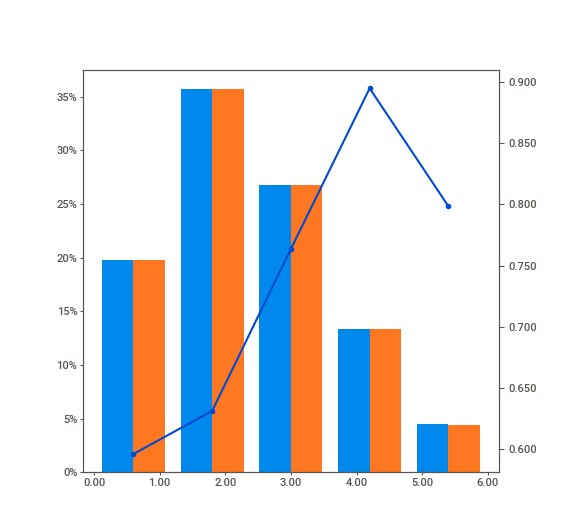
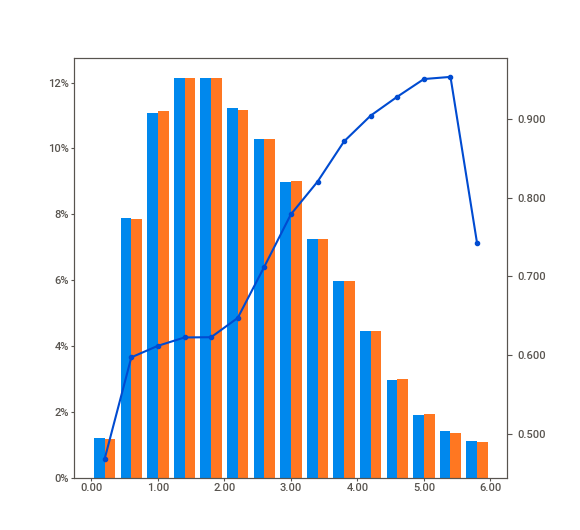
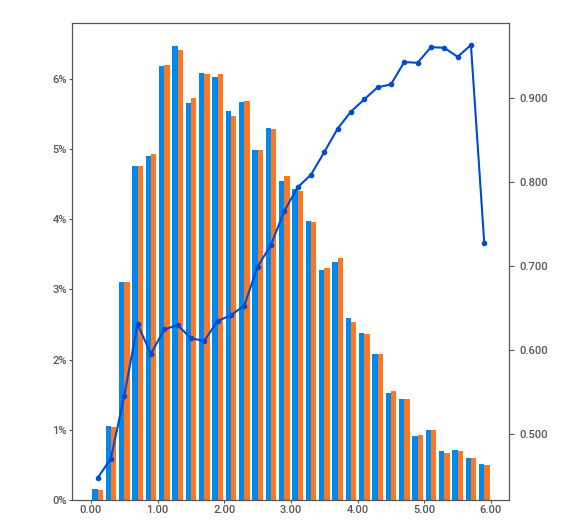
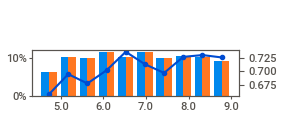
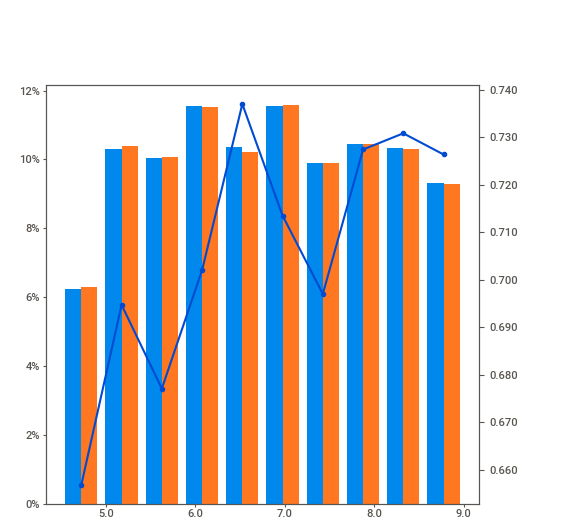
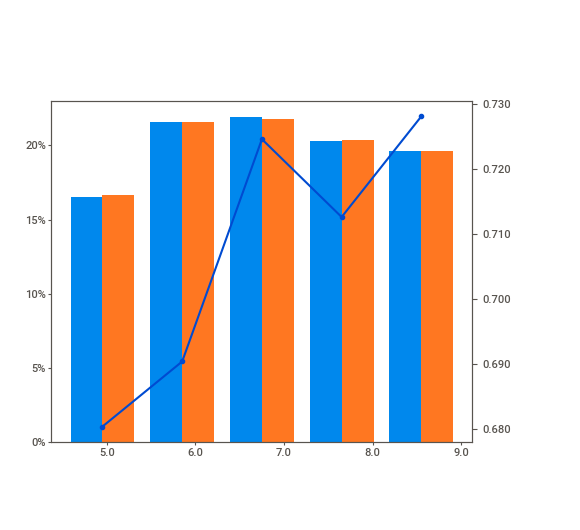
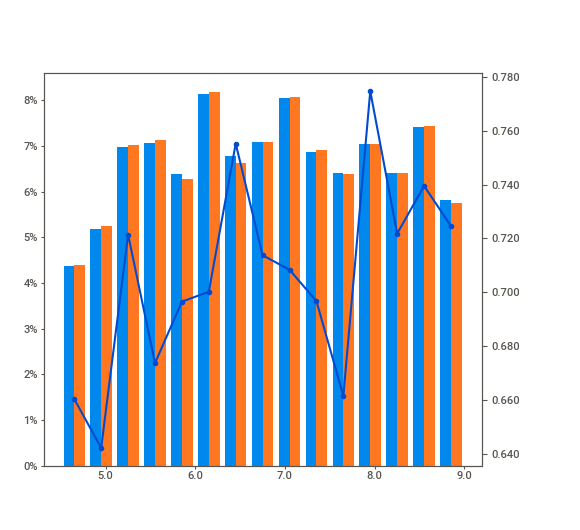
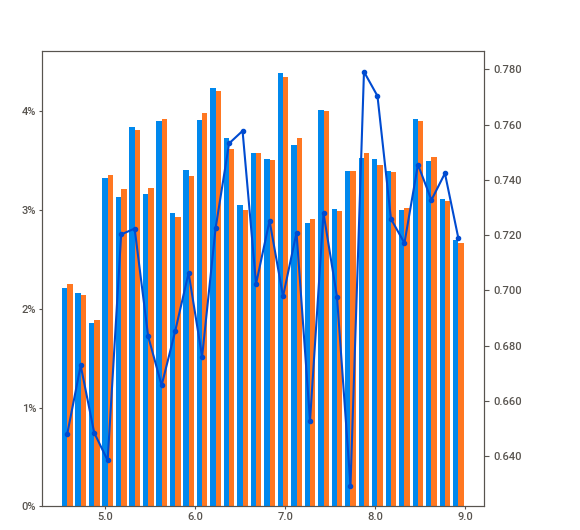
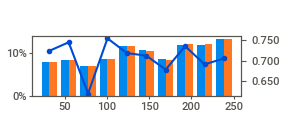
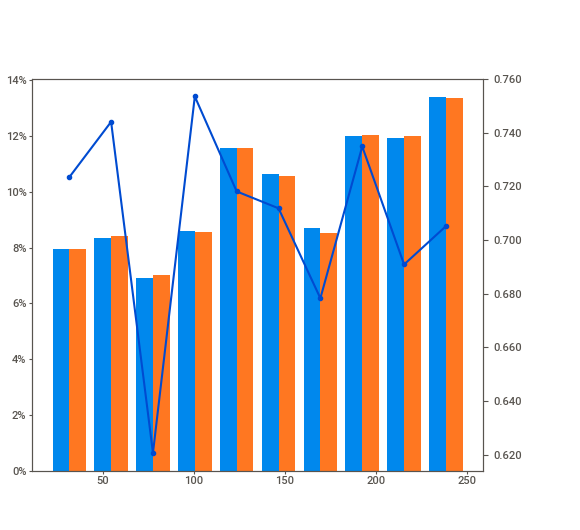
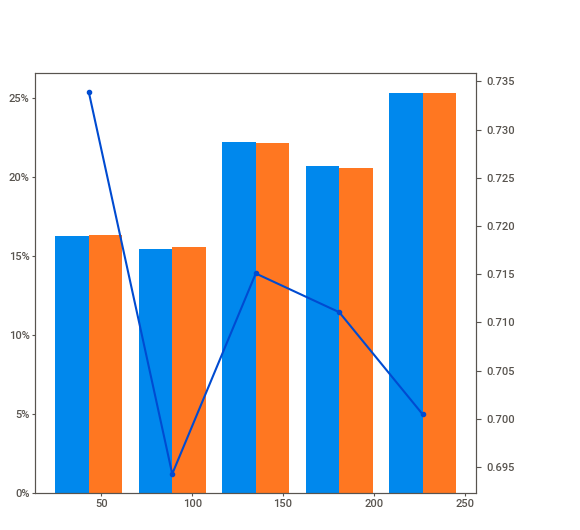
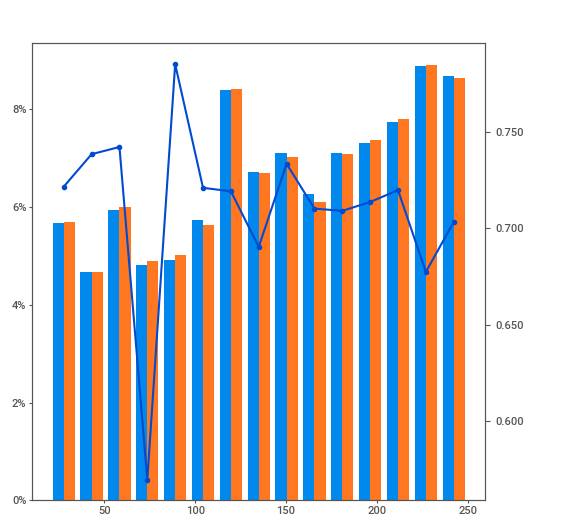
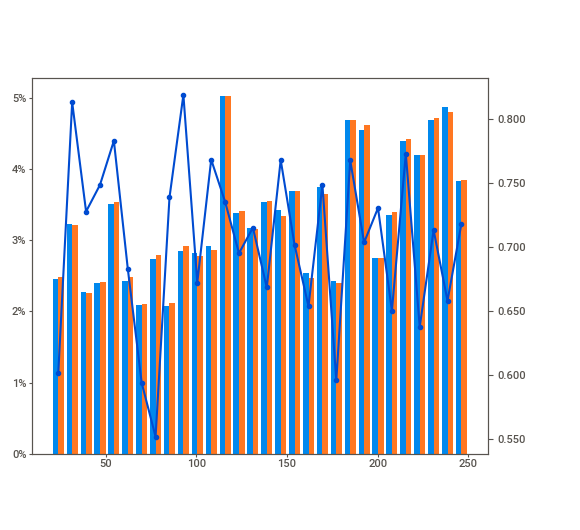
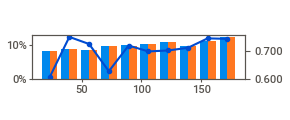
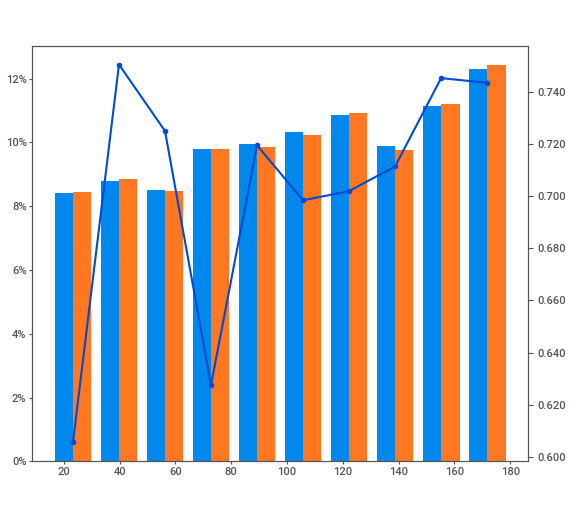
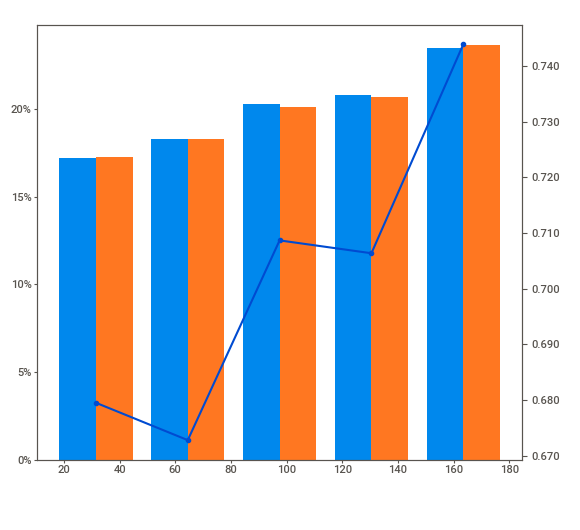
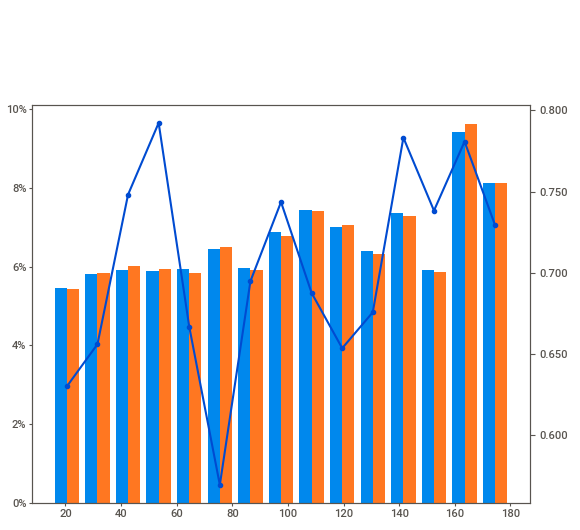
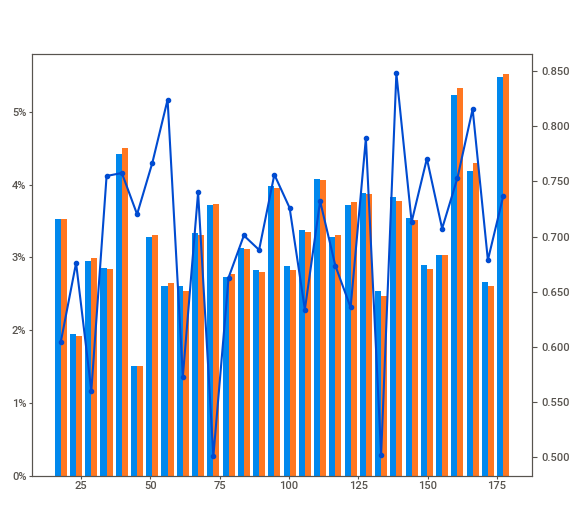
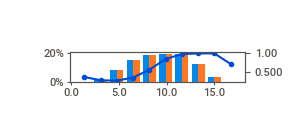
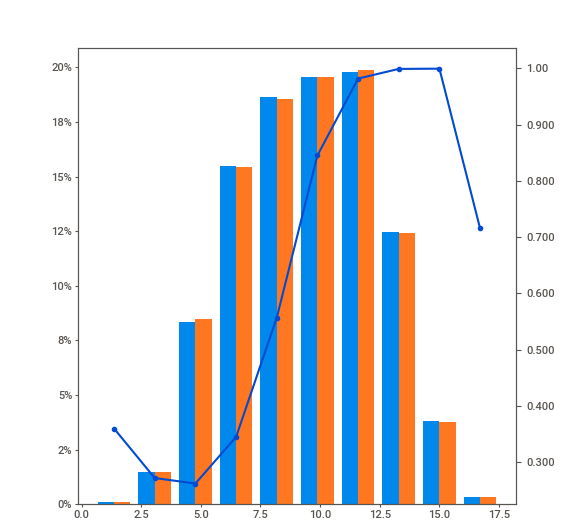
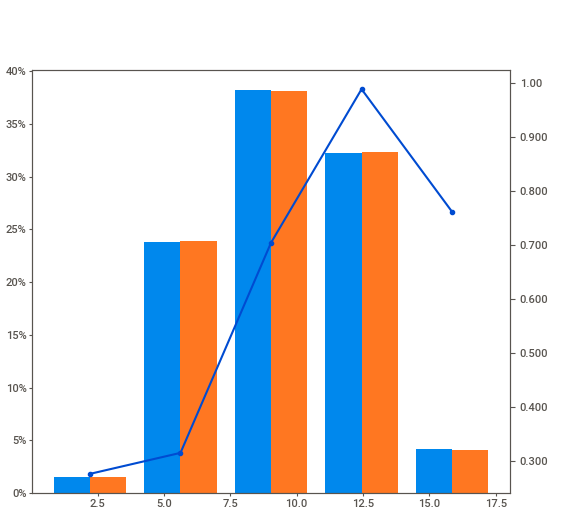
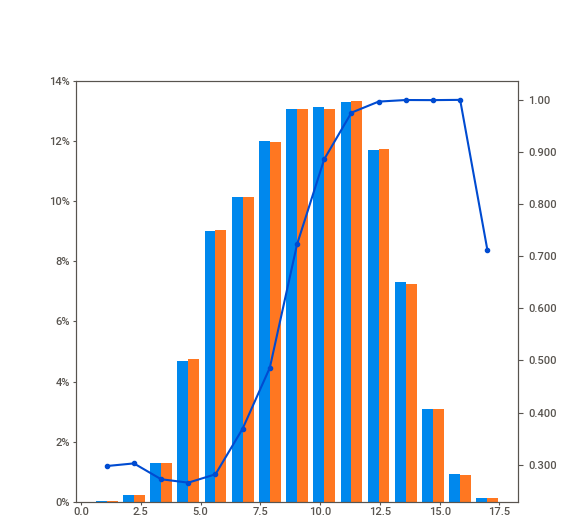
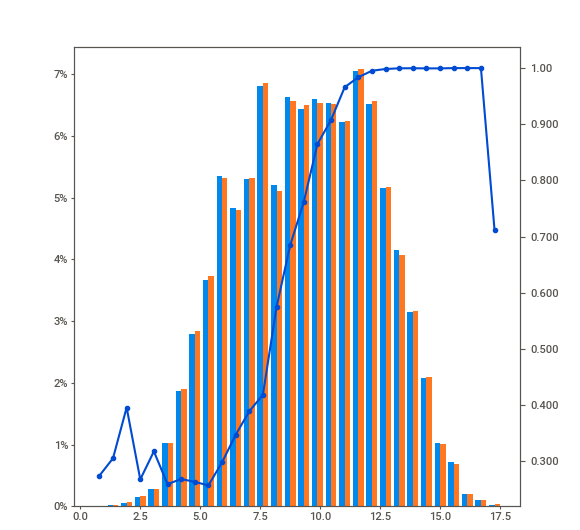
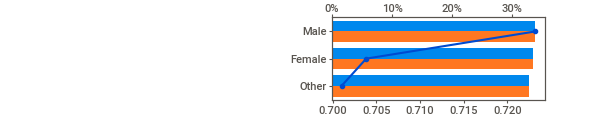
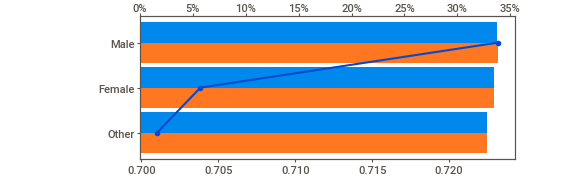
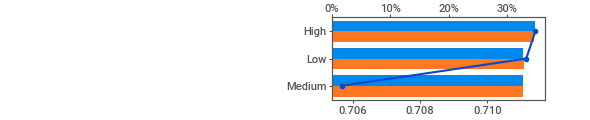
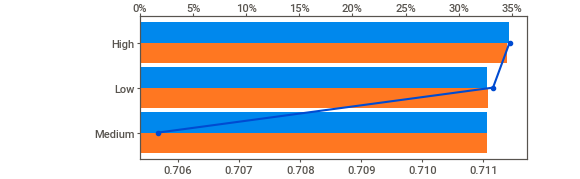
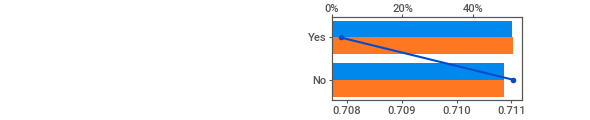
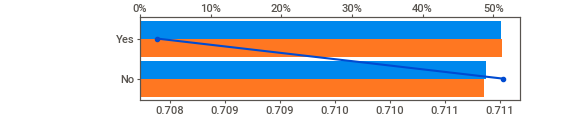
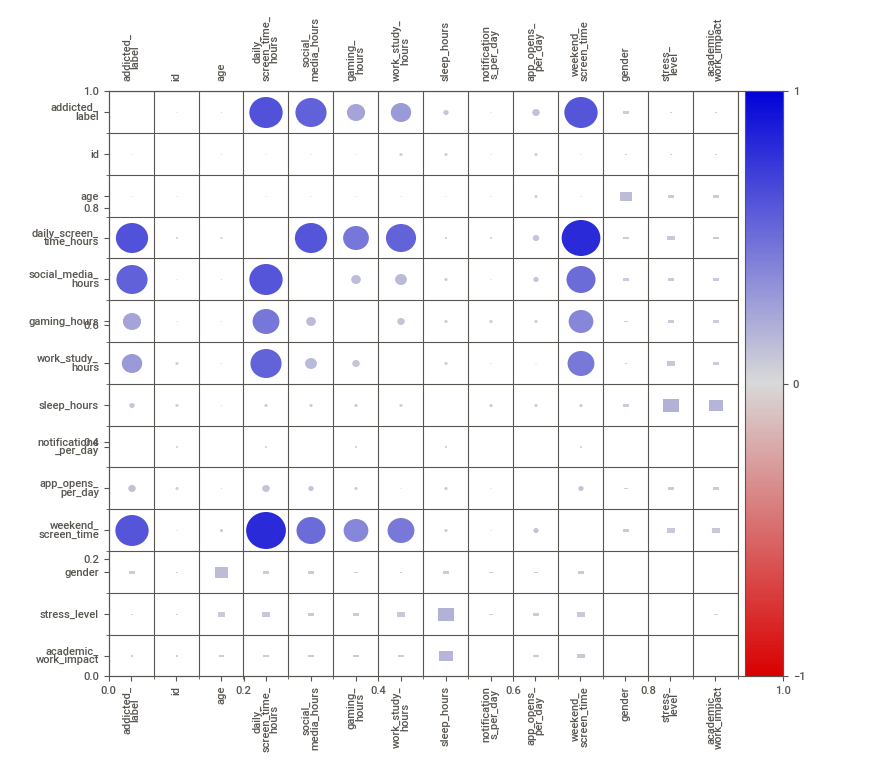
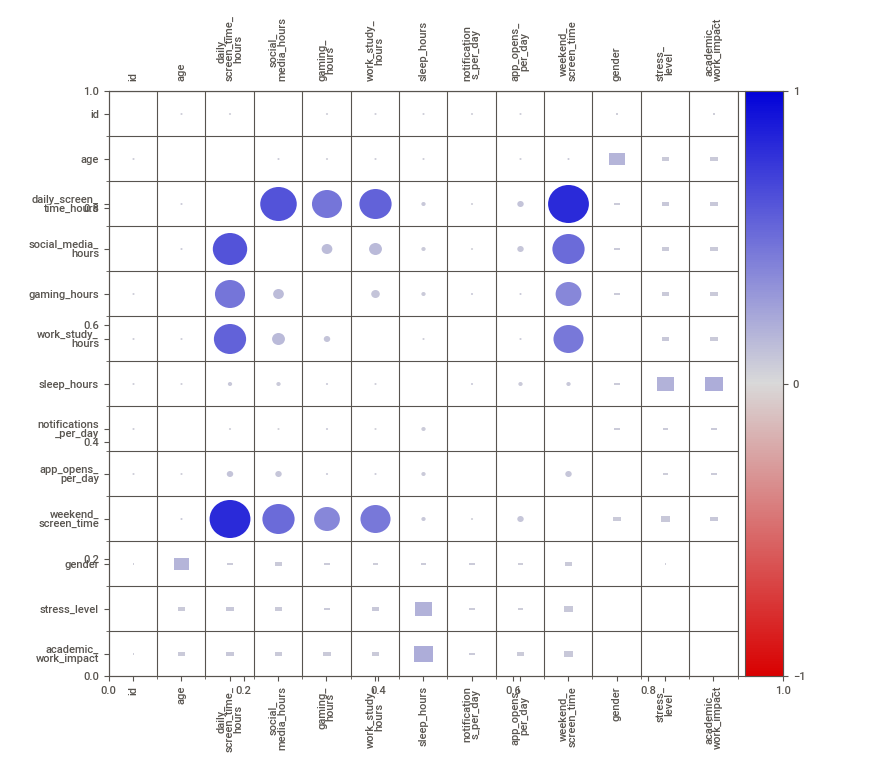

In [6]:
# Force sweetviz to treat the target as numeric
feat_cfg = sv.FeatureConfig(force_num=[TARGET])

train_test_comparison_report = sv.compare(
    [training_df, "Training Data"],
    [test_df, "Test Data"],
    target_feat=TARGET,
    feat_cfg=feat_cfg
)

# Save HTML report file for full tab browsing
train_test_comparison_report.show_html(
    filepath="sweetviz_train_test.html",
    open_browser=False
)

# Render in notebook: expanded height, widescreen layout, scaled down to fit
train_test_comparison_report.show_notebook(
    w="100%",
    h=1000,
    scale=0.85
)

### Train vs Test Drift Analysis Insights

Based on Kolmogorov-Smirnov (KS) tests comparing the feature distributions between the training and testing sets, we observe:
* **Zero Significant Drift**: All features have very high KS p-values (e.g., `age` p-val = 0.804, `daily_screen_time_hours` p-val = 0.647, `social_media_hours` p-val = 0.770).
* **Implication**: The test split is drawn from the exact same synthetic distribution as the train split. Standard local validation scores (e.g., 5-fold cross-validation) should be highly representative of the public and private leaderboard performance.

### Standalone Training Profile Report

*(Saved locally as [sweetviz_training_profile.html](sweetviz_training_profile.html) for full browser display)*

                                             |                                                                …

Report sweetviz_training_profile.html was generated.



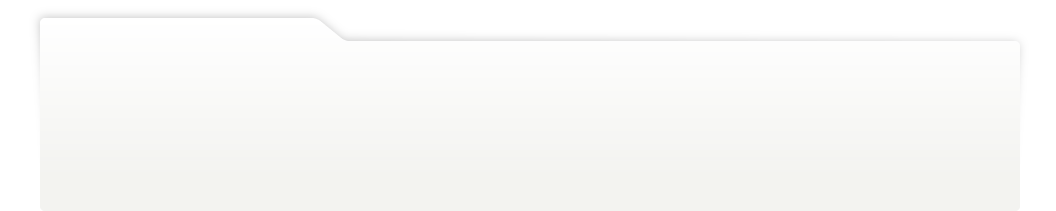
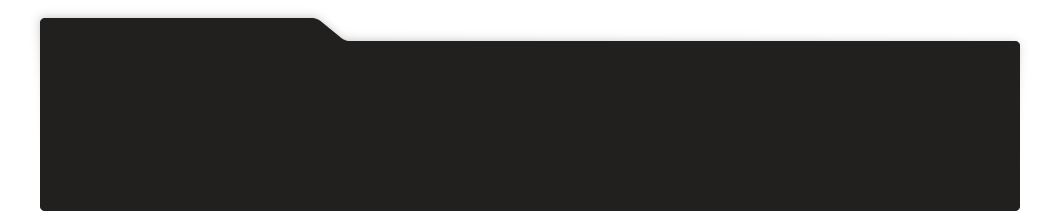
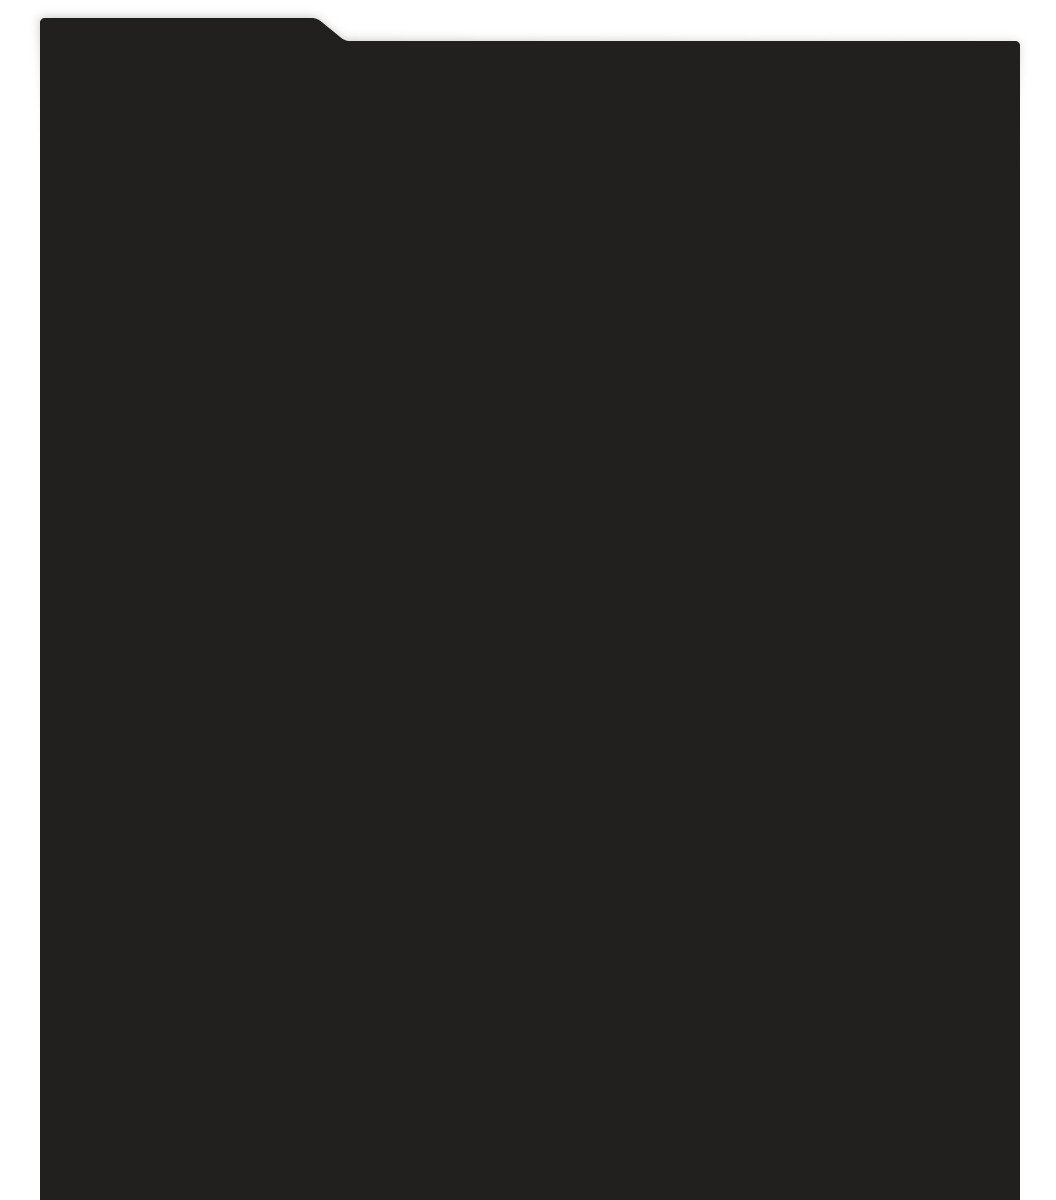
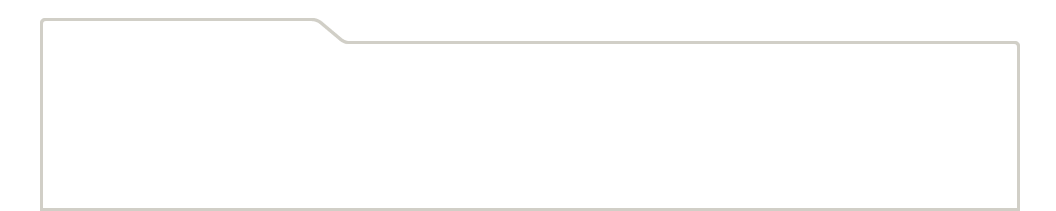
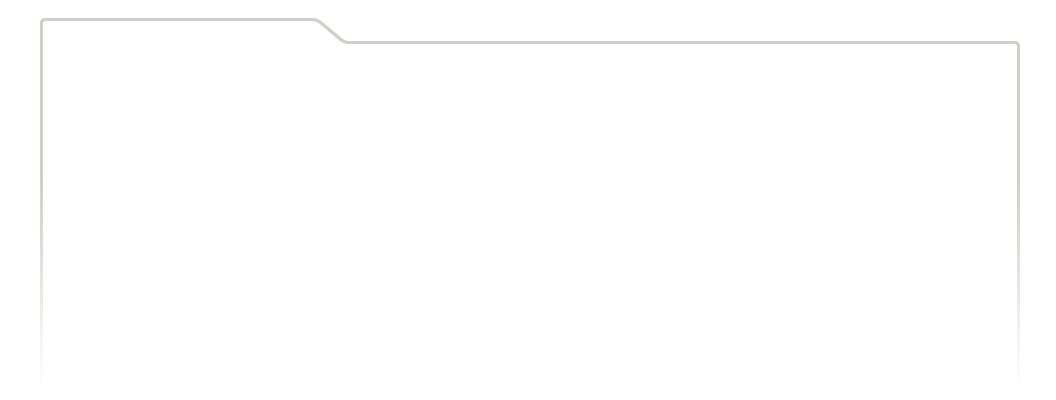
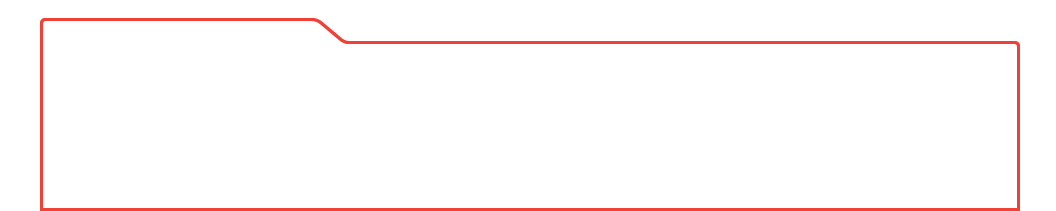
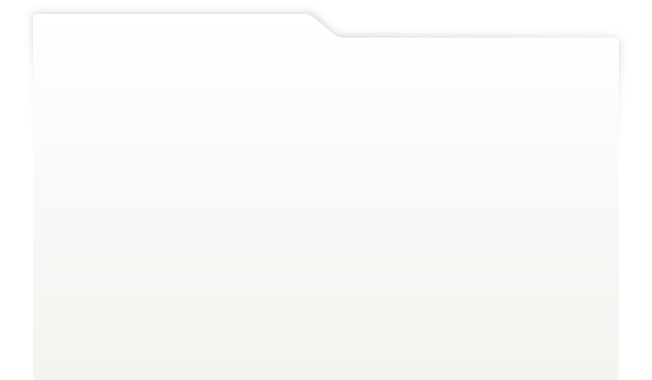
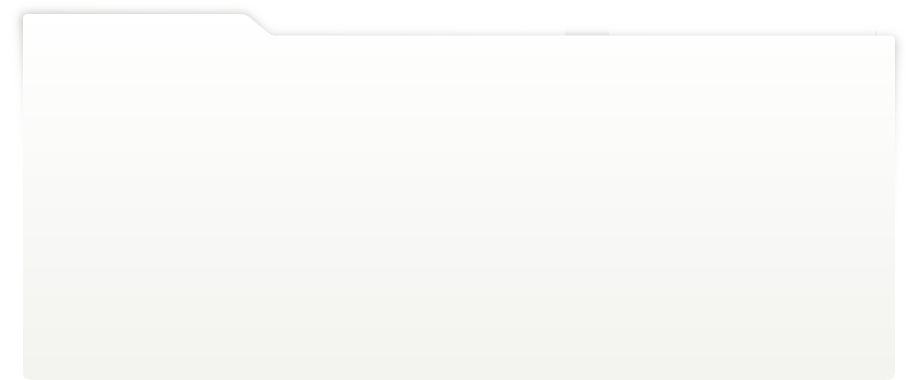
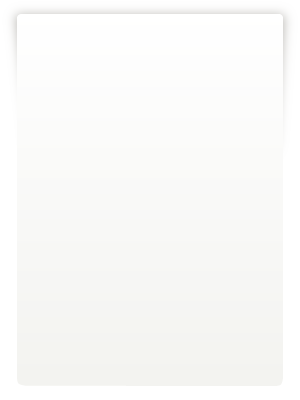
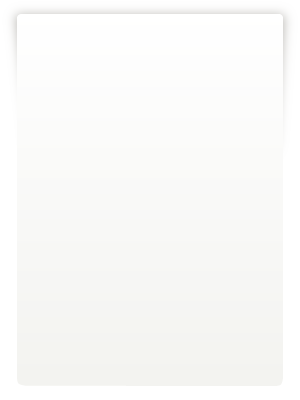
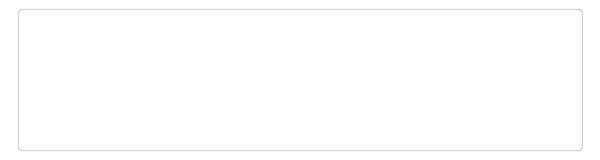
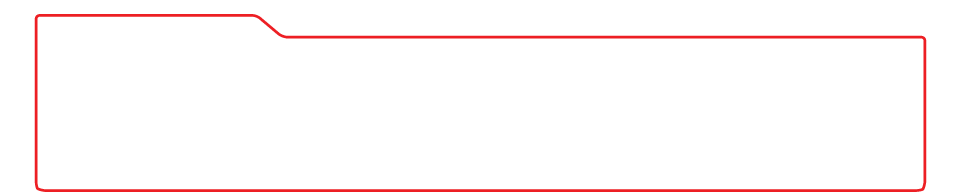
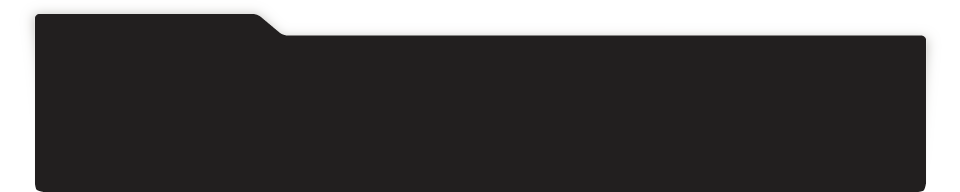
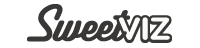
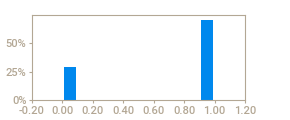
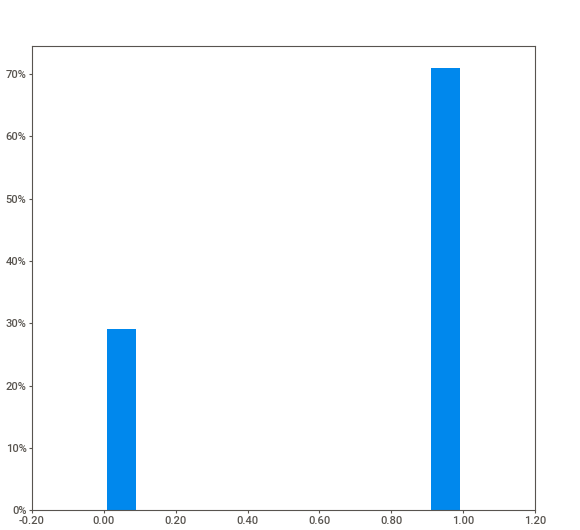
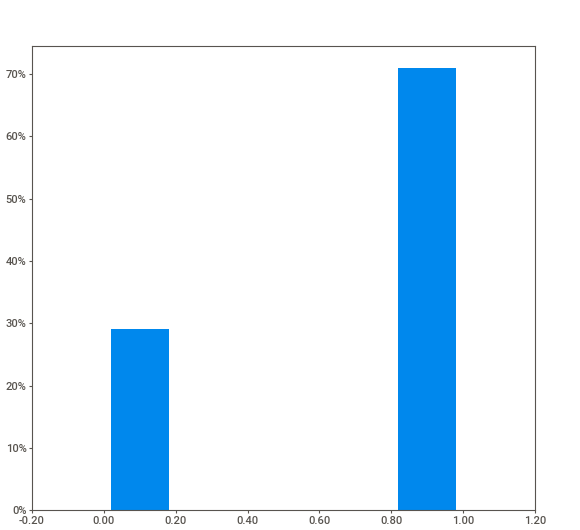
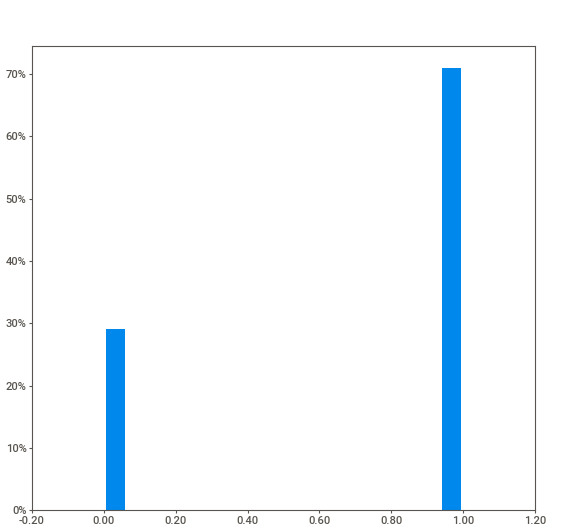
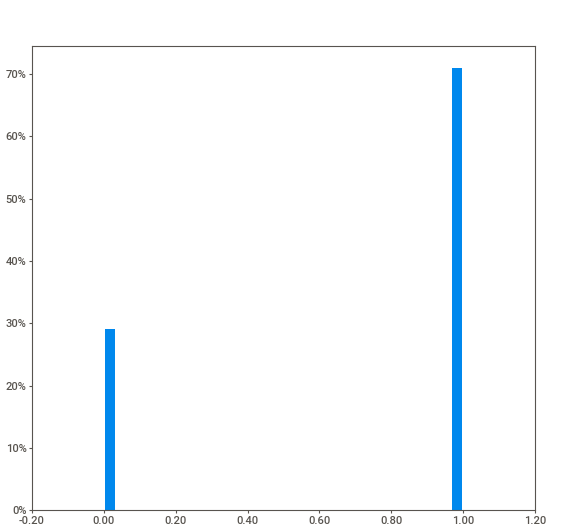
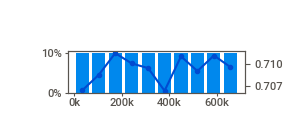
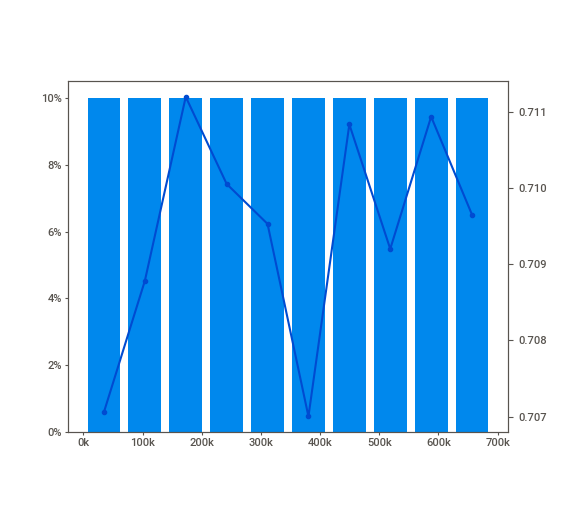
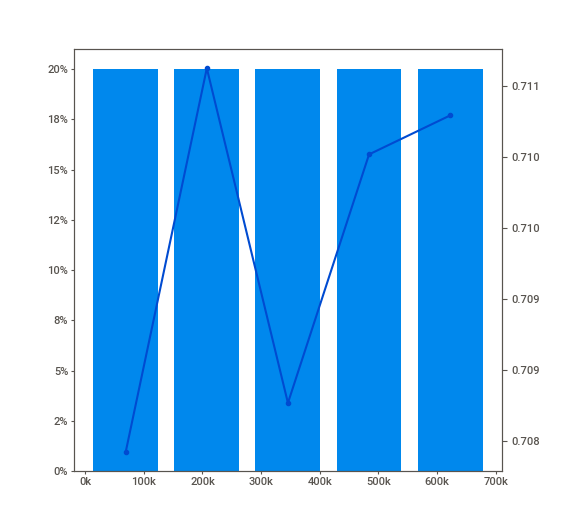
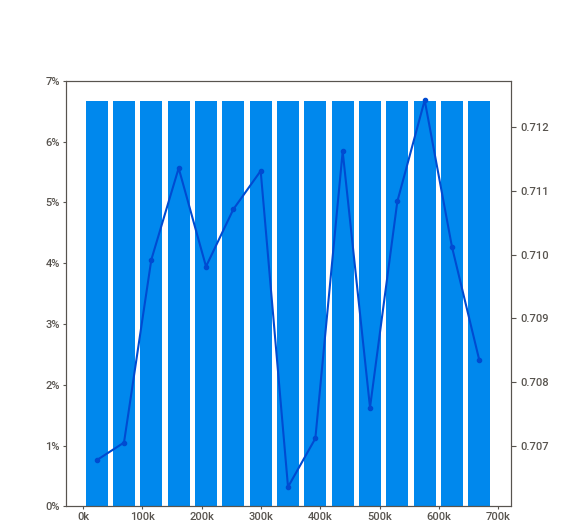
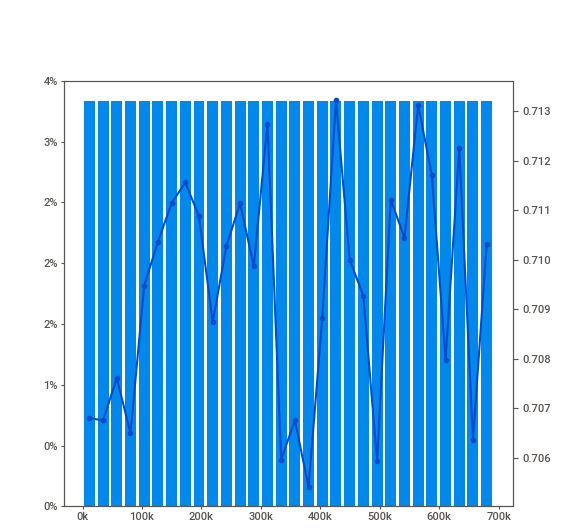
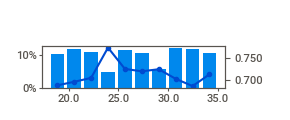
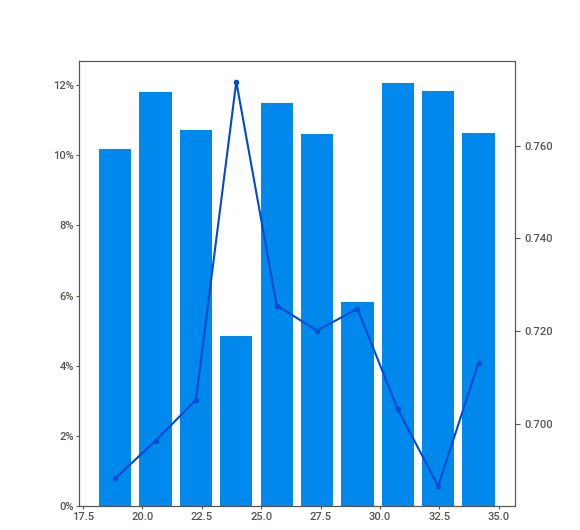
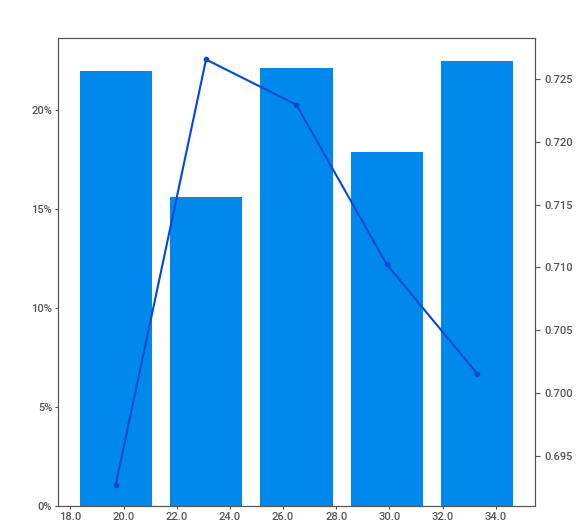
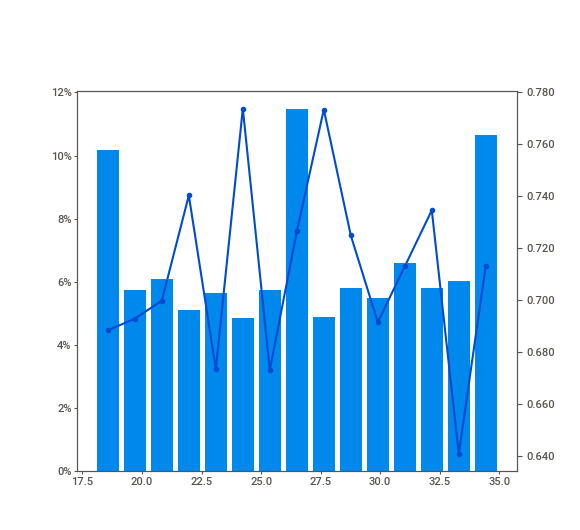
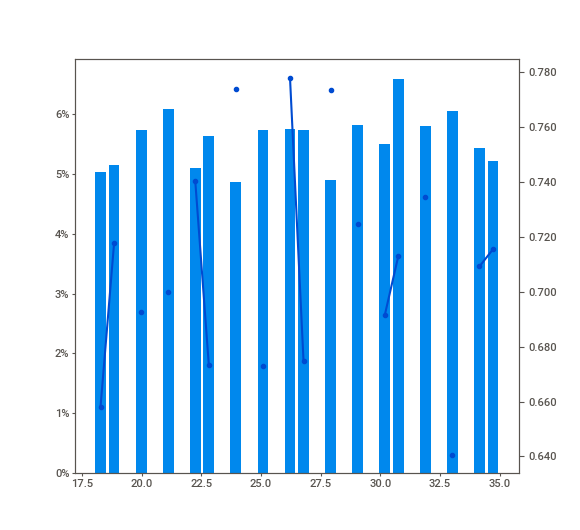
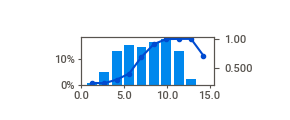
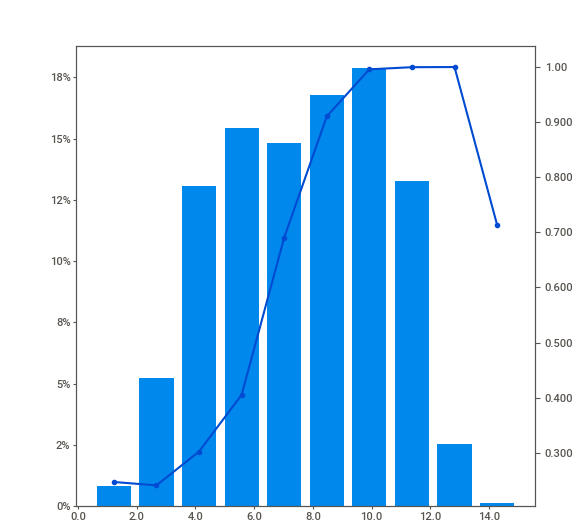
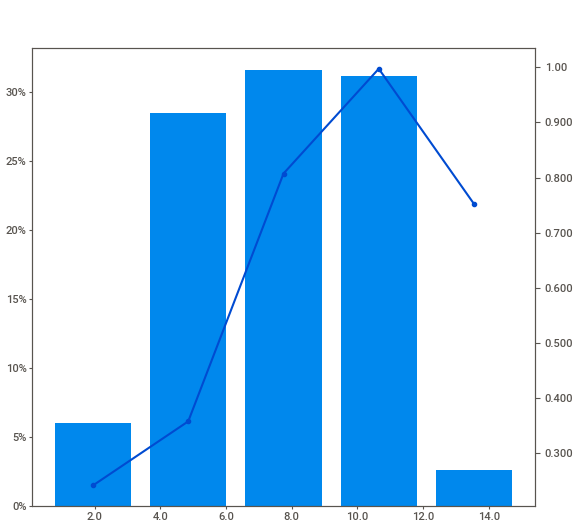
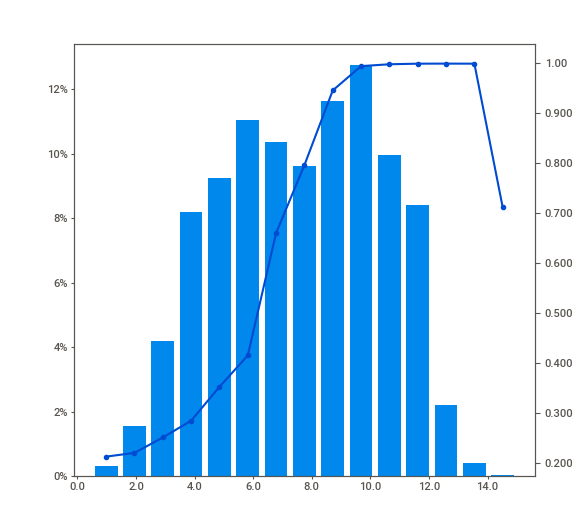
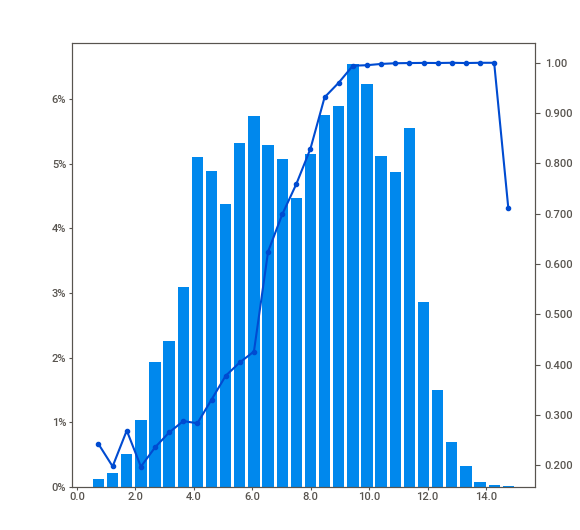
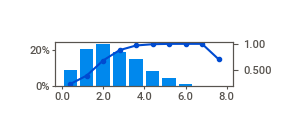
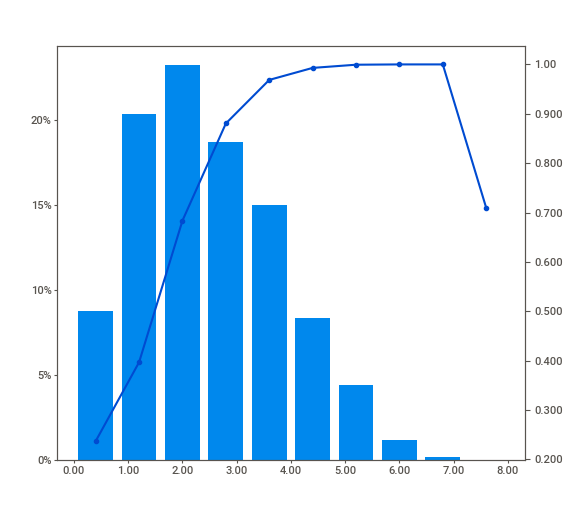
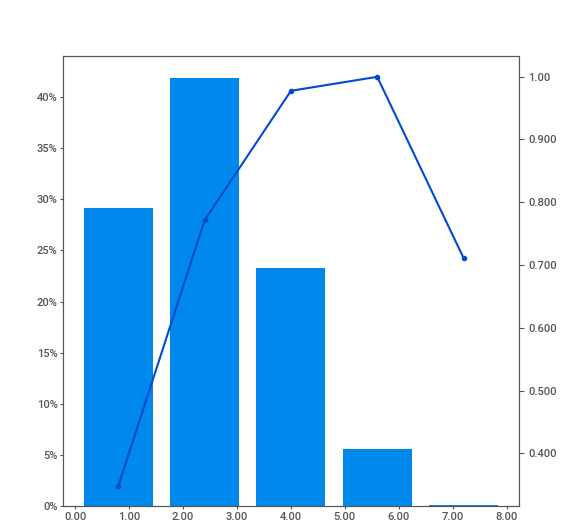
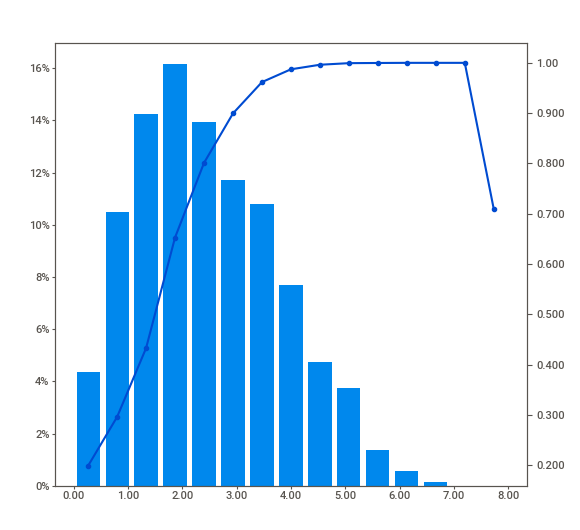
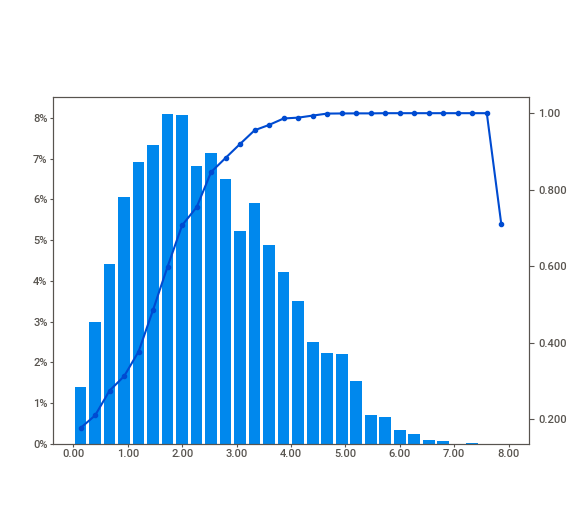
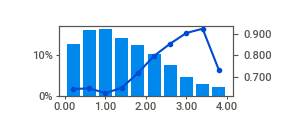
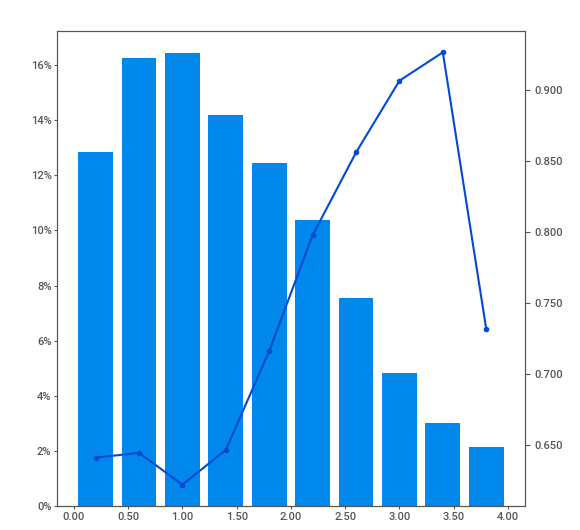
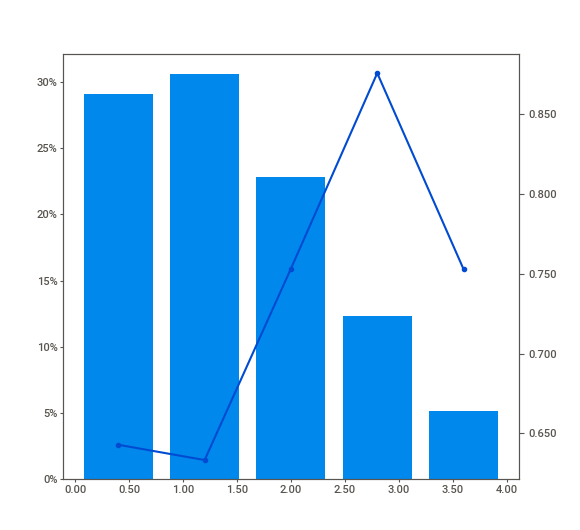
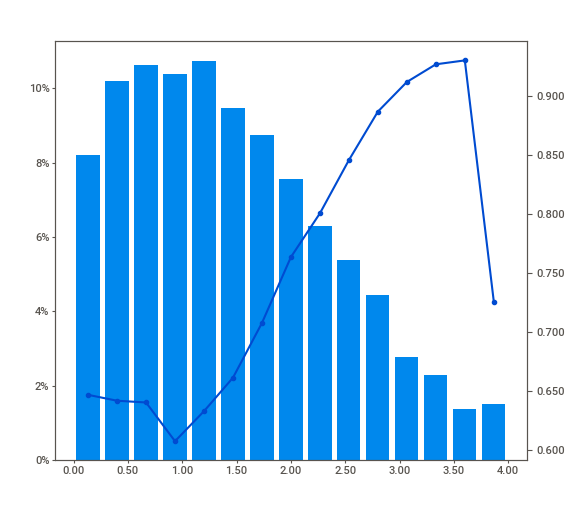
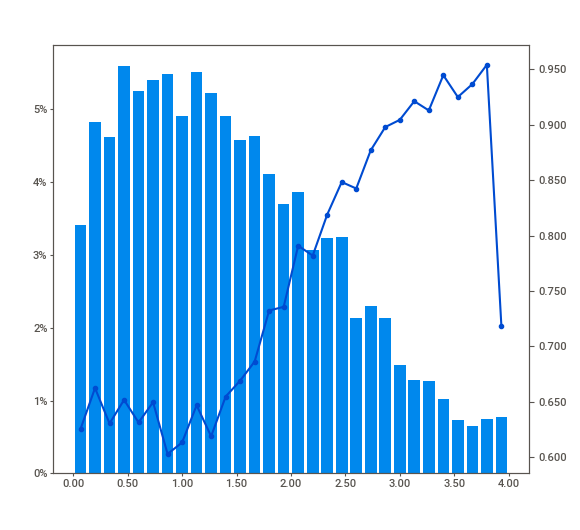
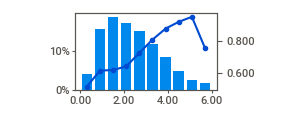
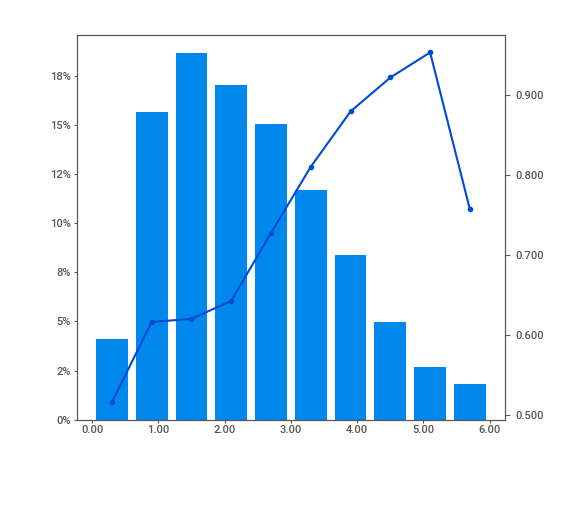
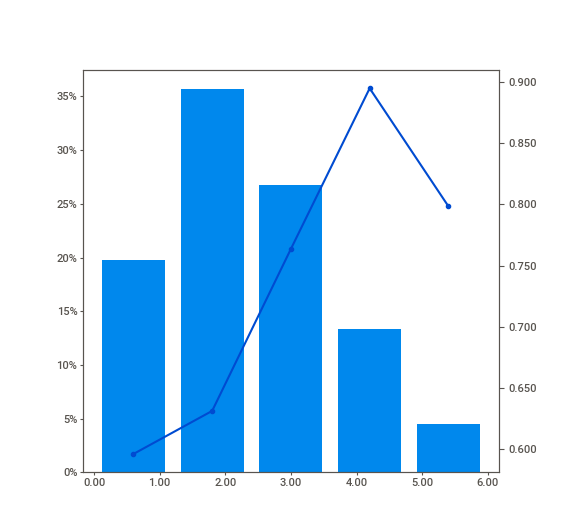
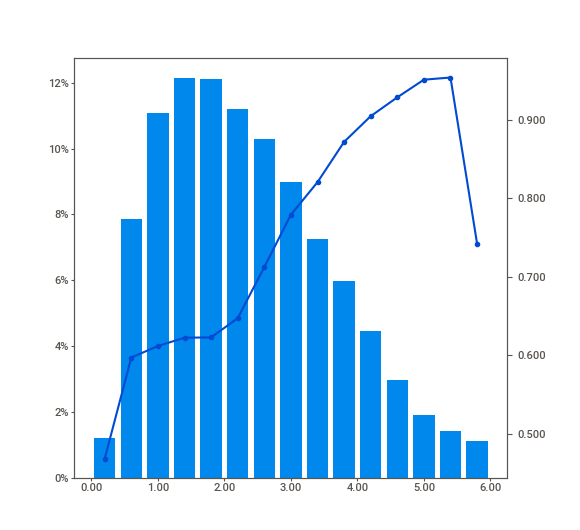
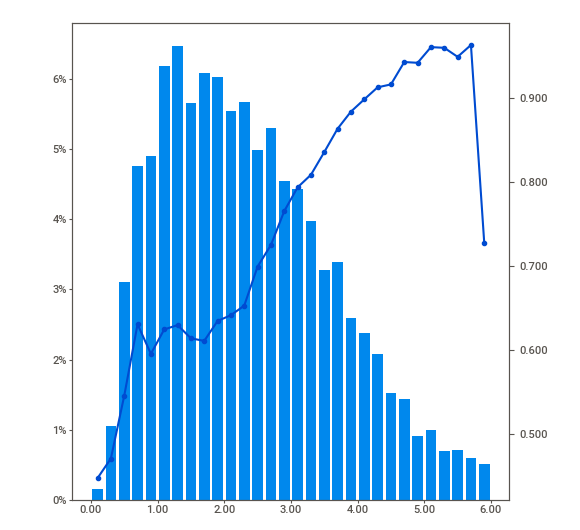
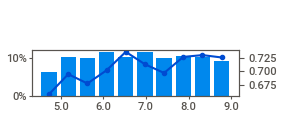
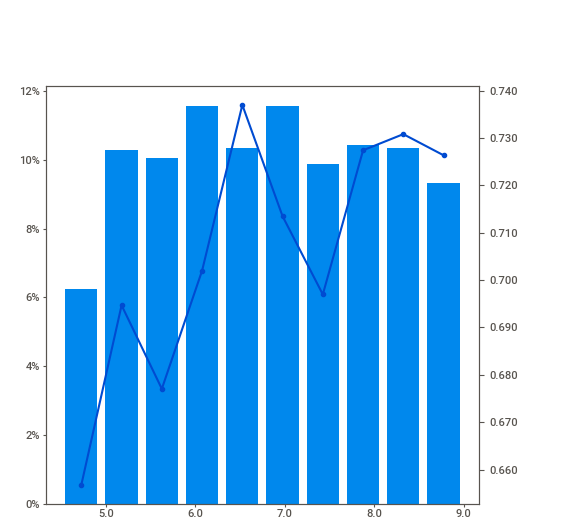
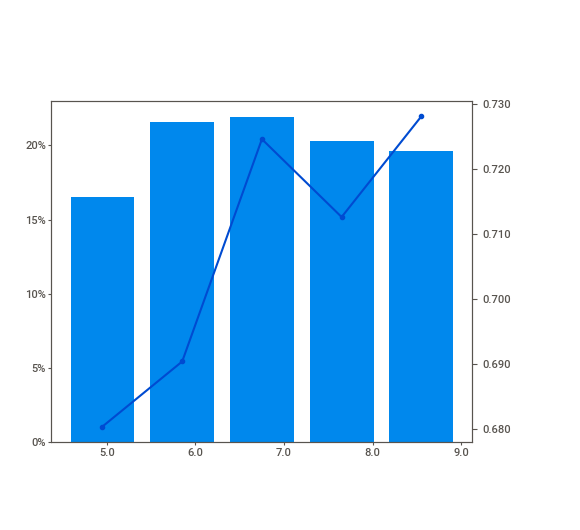
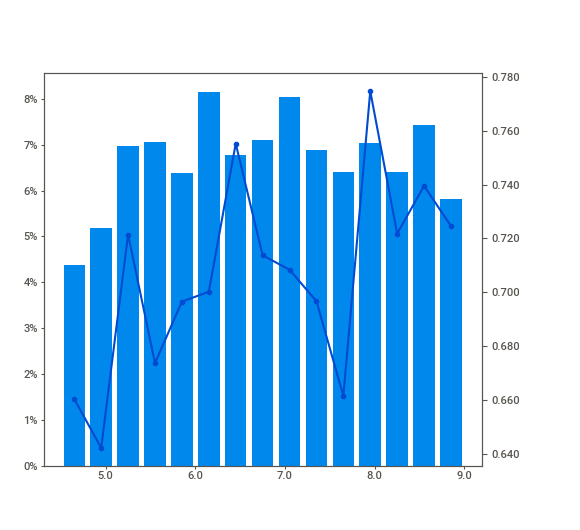
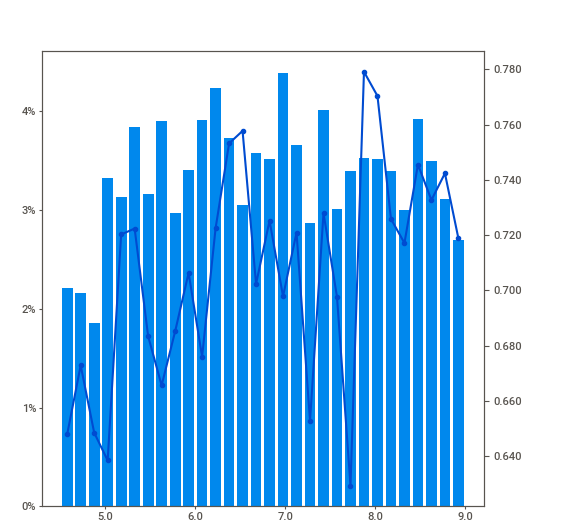
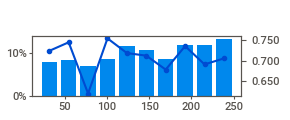
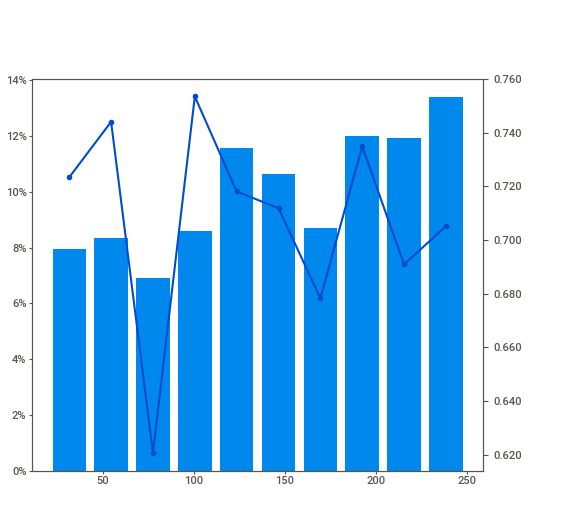
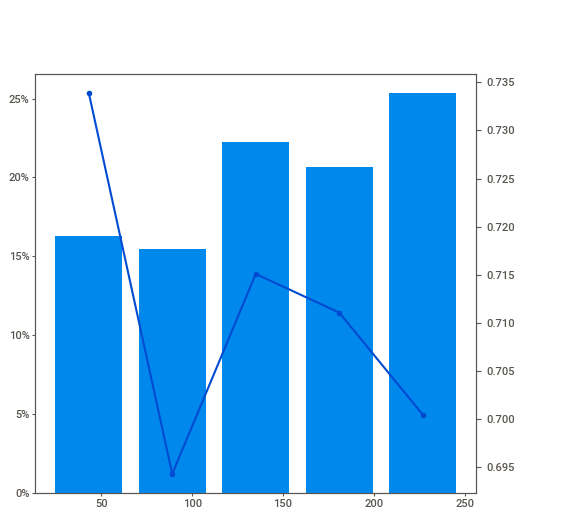
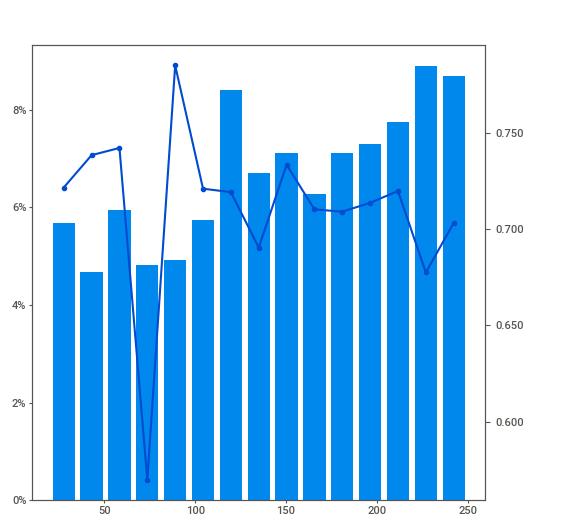
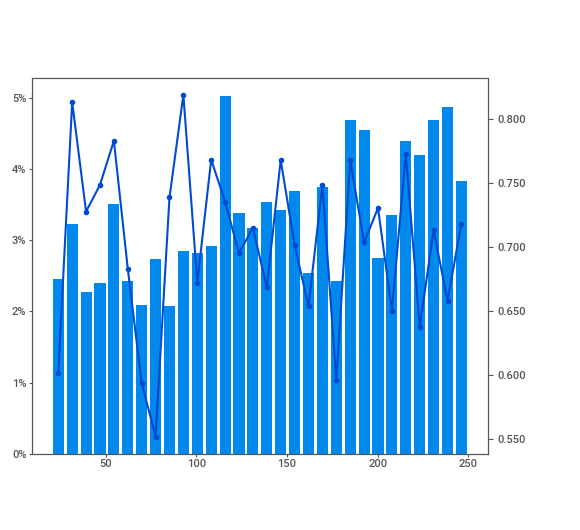
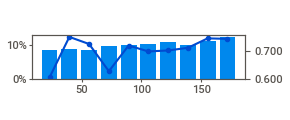
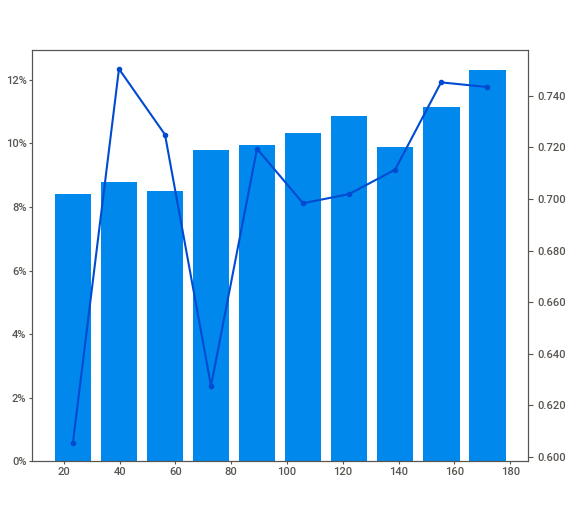
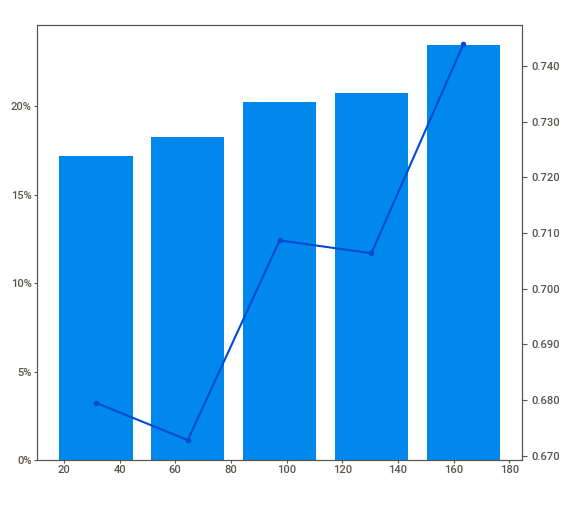
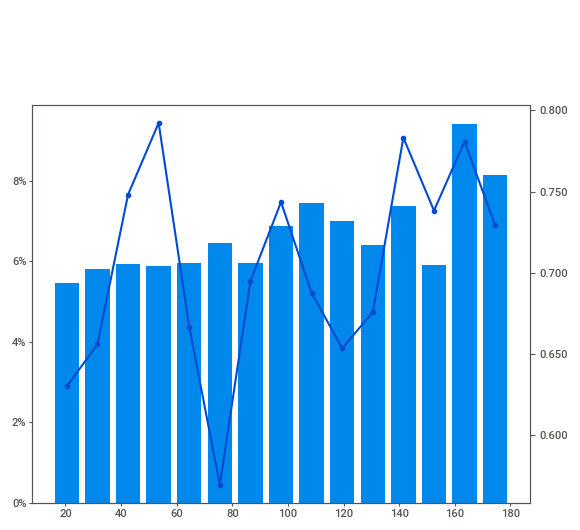
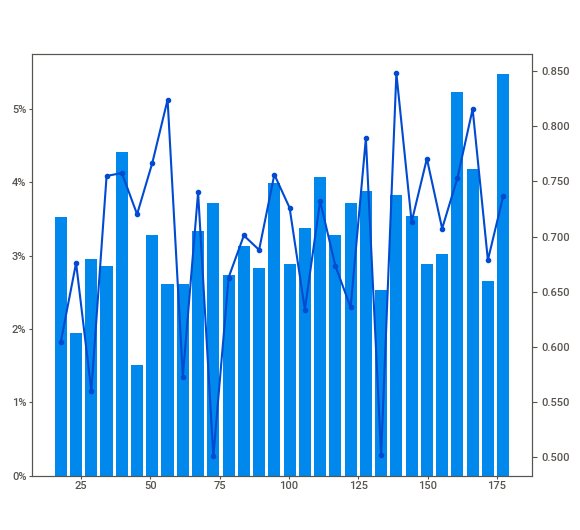
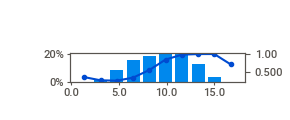
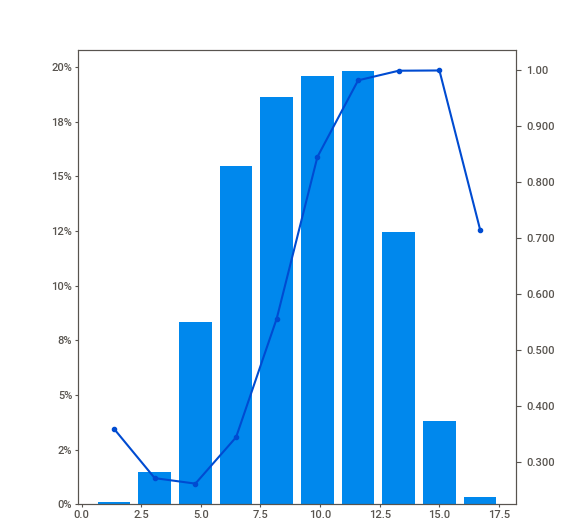
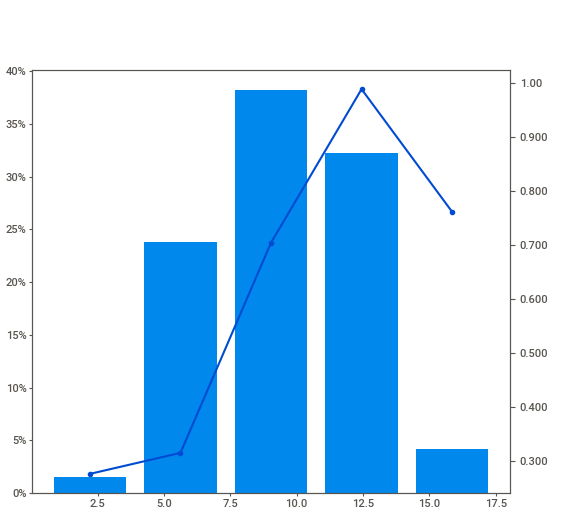
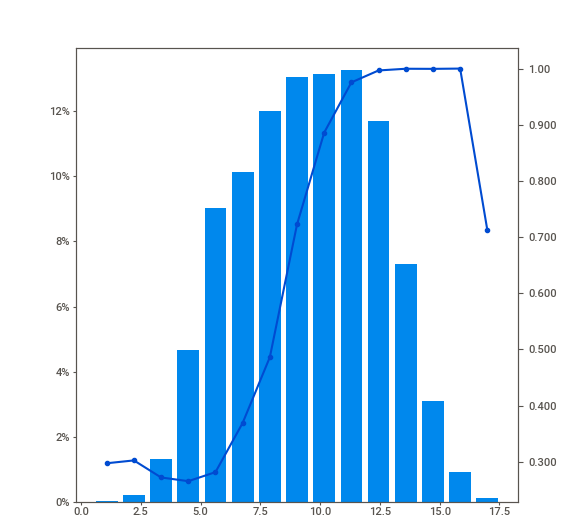
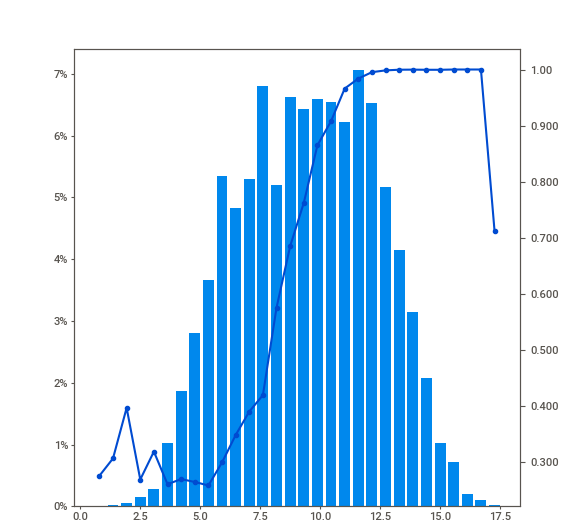
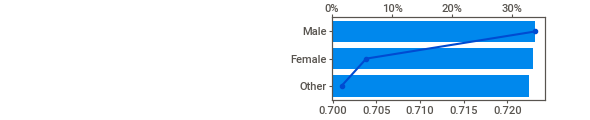
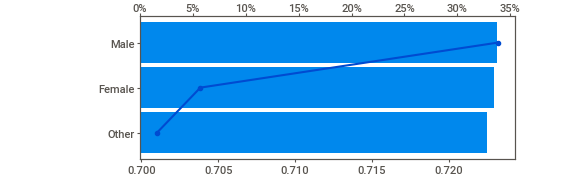
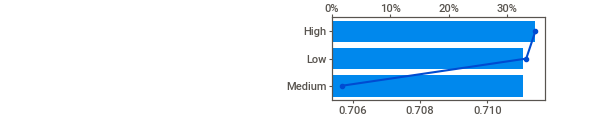
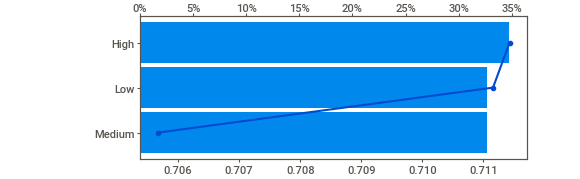
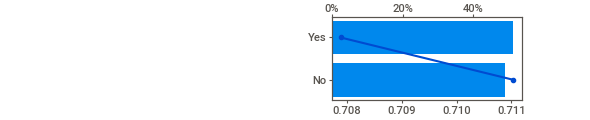
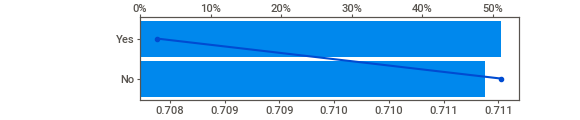
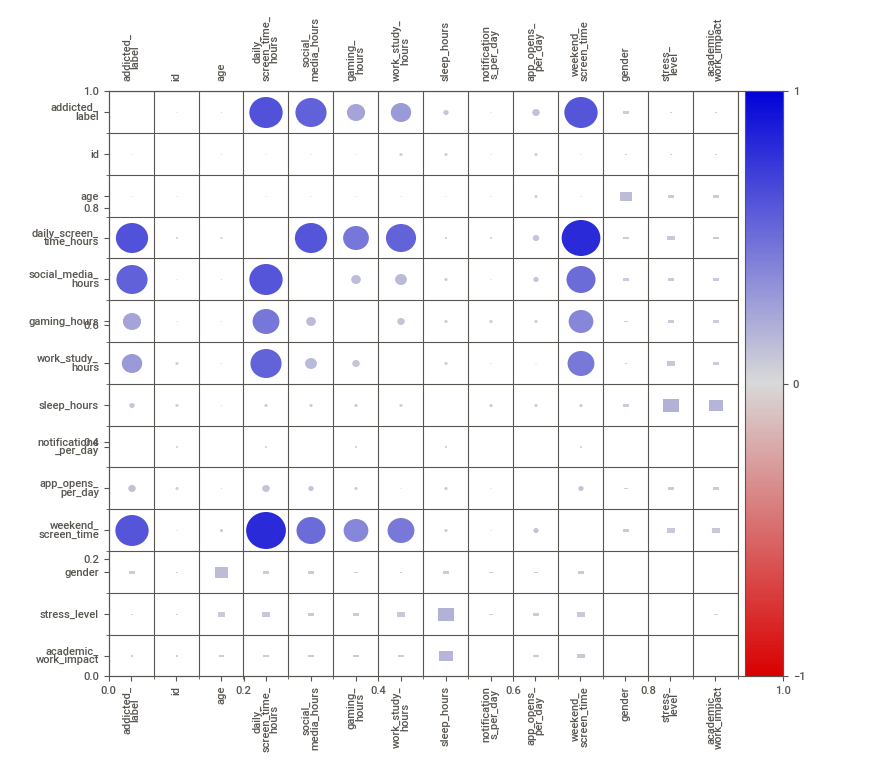
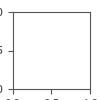

In [7]:
training_report = sv.analyze(
    [training_df, "Training Data"],
    target_feat=TARGET,
    feat_cfg=feat_cfg
)

# Save HTML report file
training_report.show_html(
    filepath="sweetviz_training_profile.html",
    open_browser=False
)

# Render in notebook
training_report.show_notebook(
    w="100%",
    h=1000,
    scale=0.85
)

### Intra-class Comparison (Addicted vs. Not Addicted)

Compare addicted cases (target = 1) versus non-addicted cases (target = 0) within the training data.
*(Saved locally as [sweetviz_addicted_intra.html](sweetviz_addicted_intra.html) for full browser display)*

                                             |                                                                …

Report sweetviz_addicted_intra.html was generated.



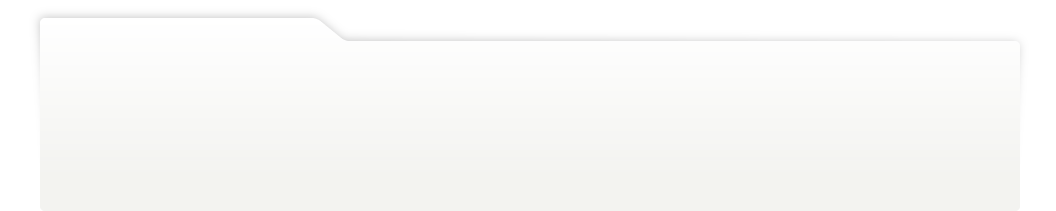
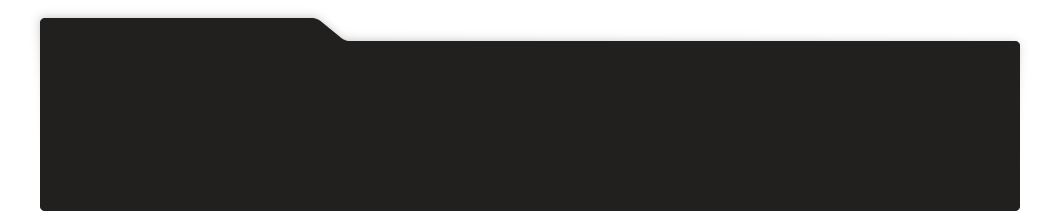
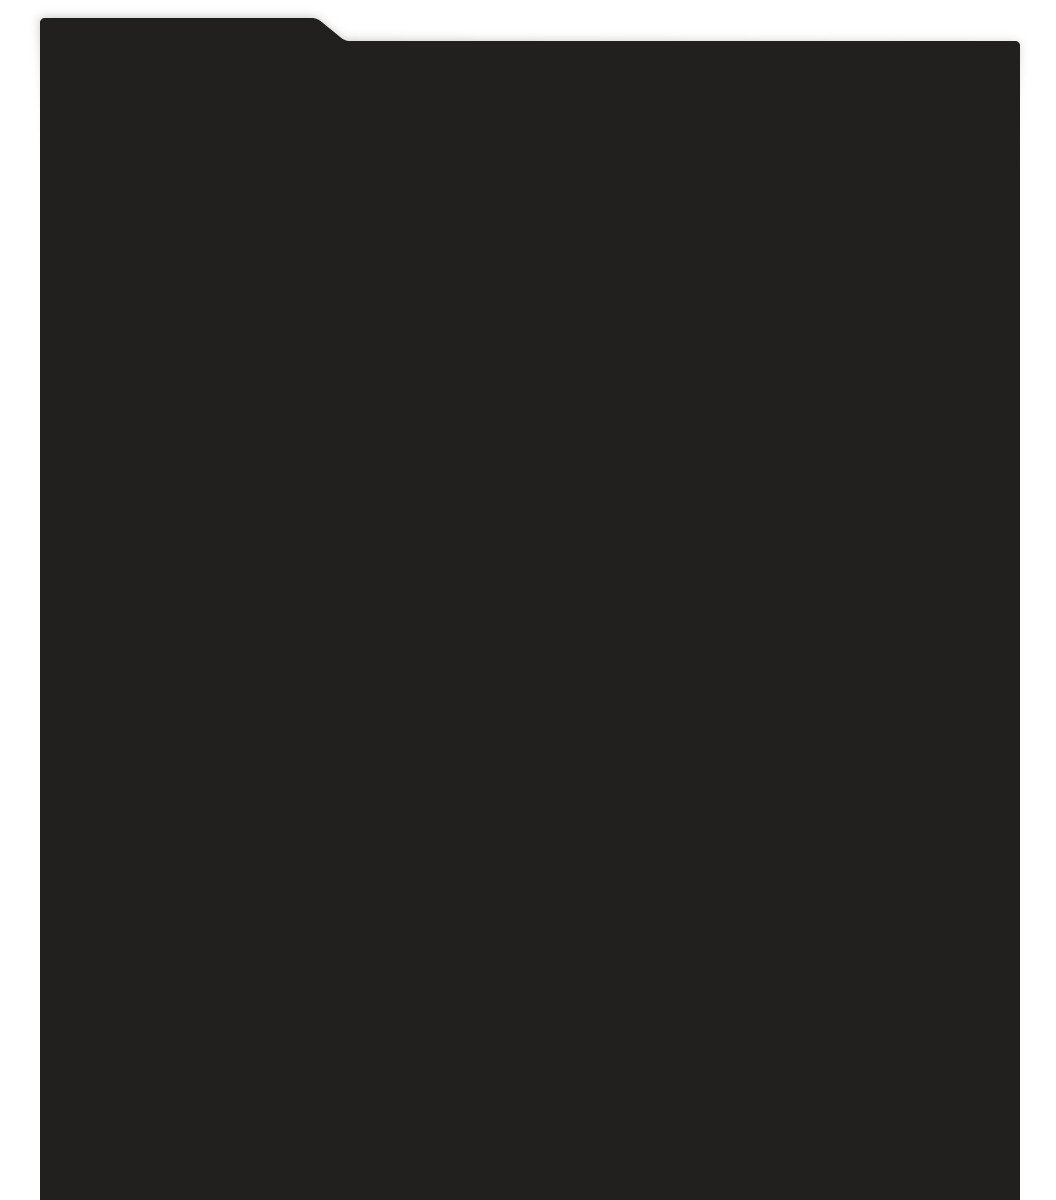
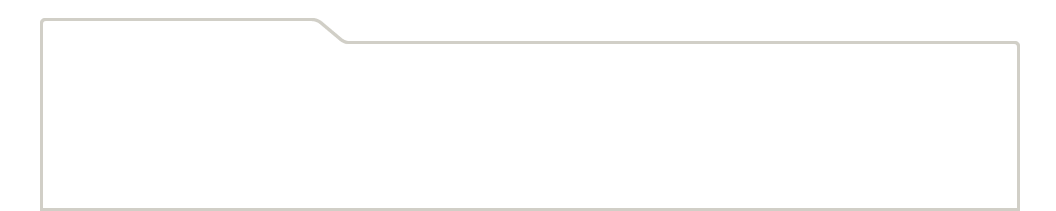
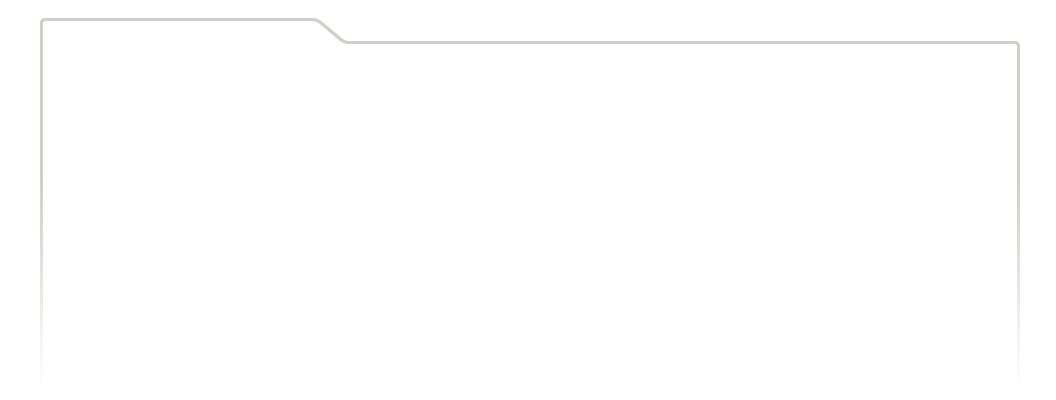
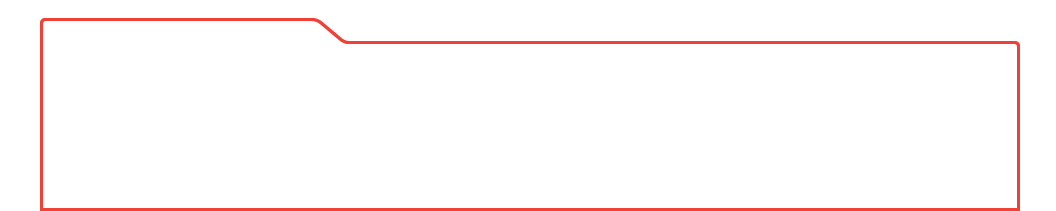
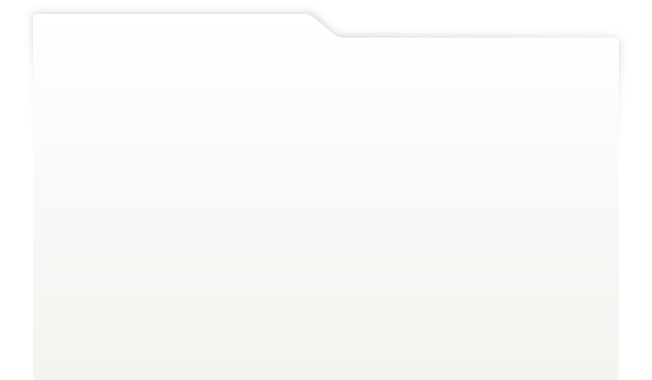
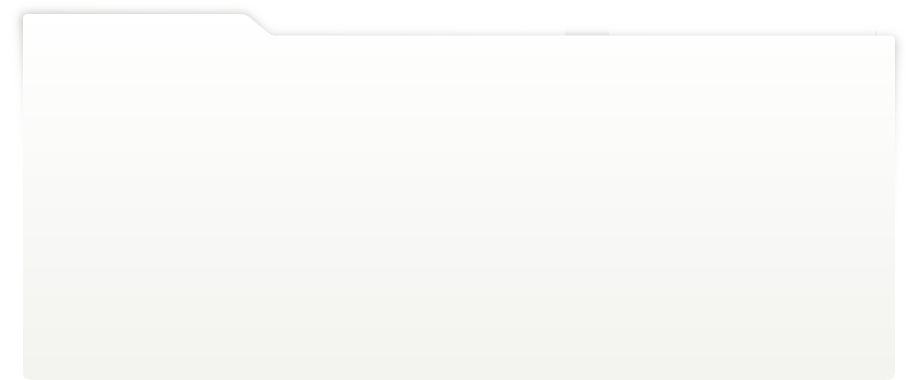
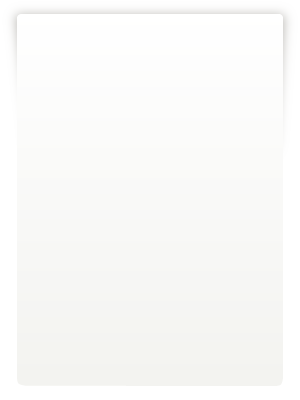
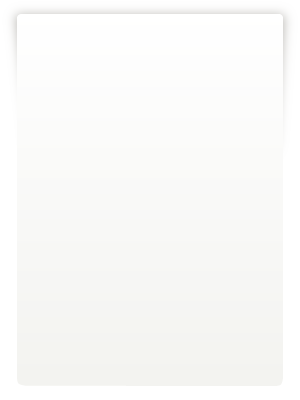
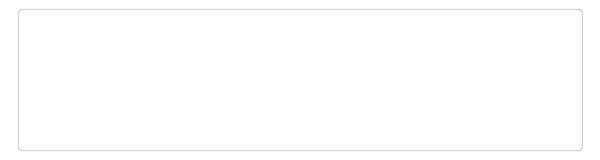
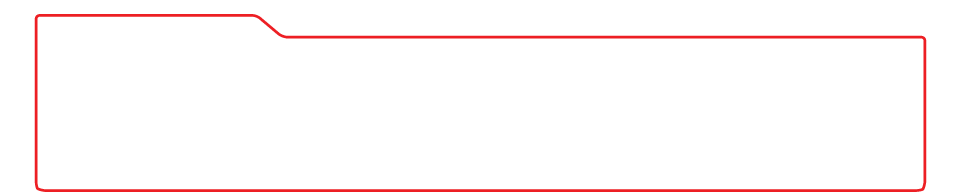
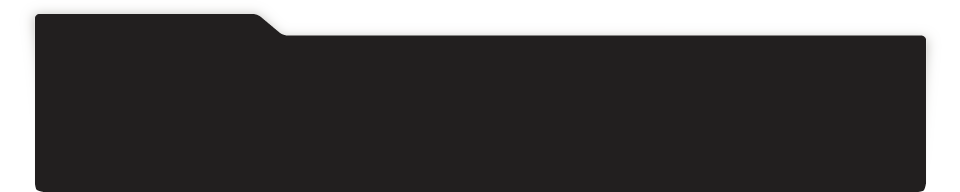
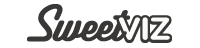
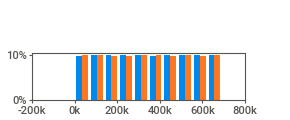
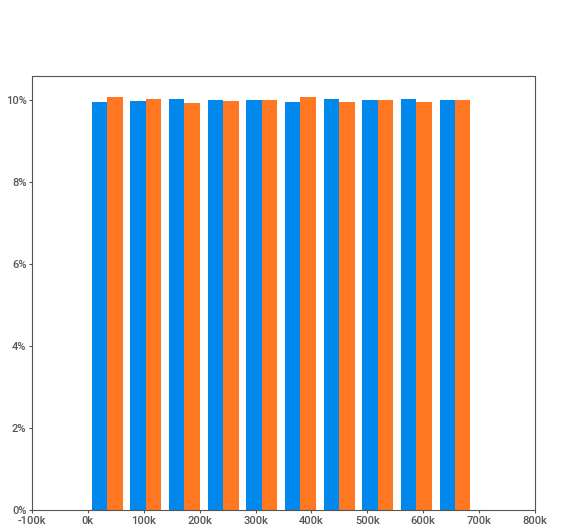
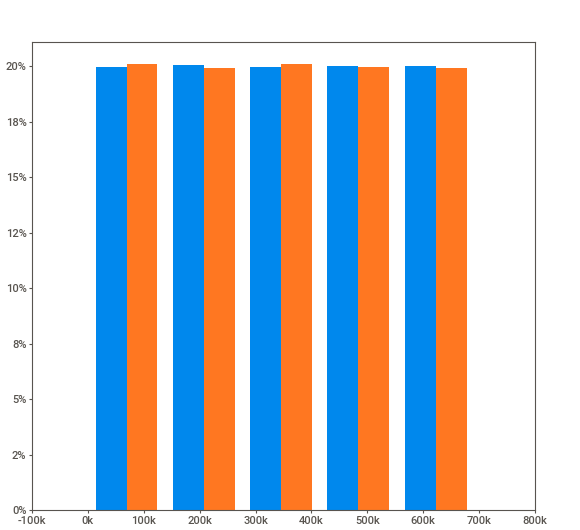
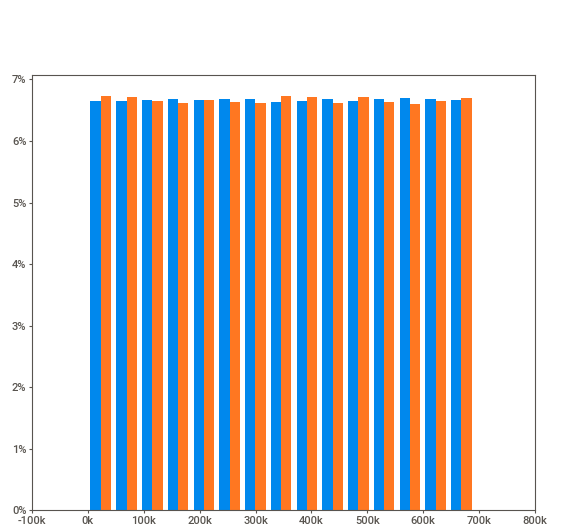
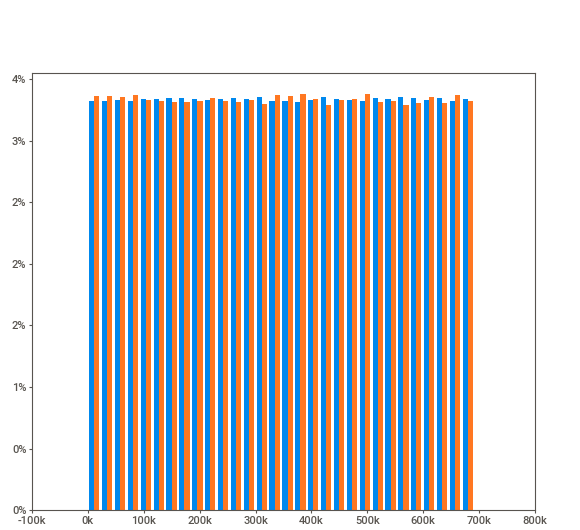
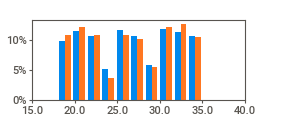
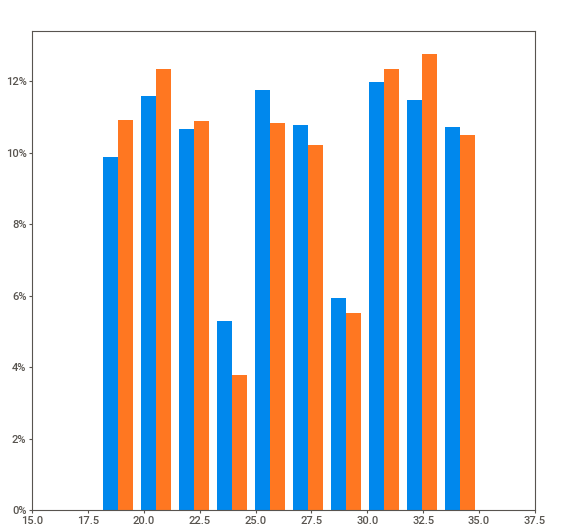
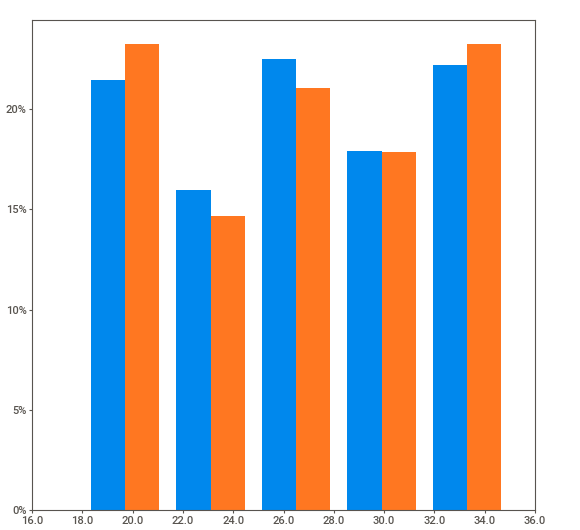
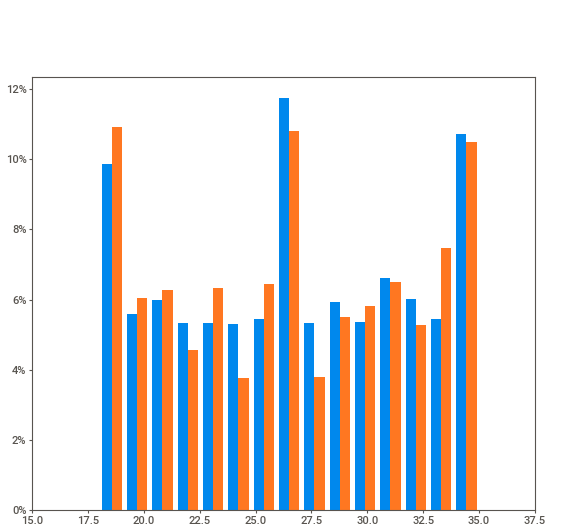
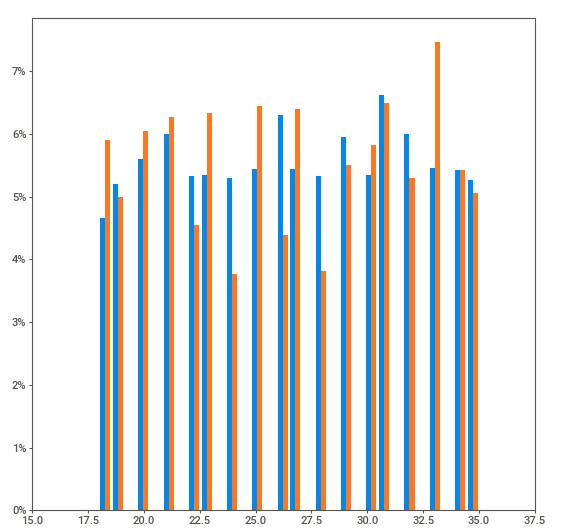
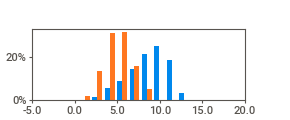
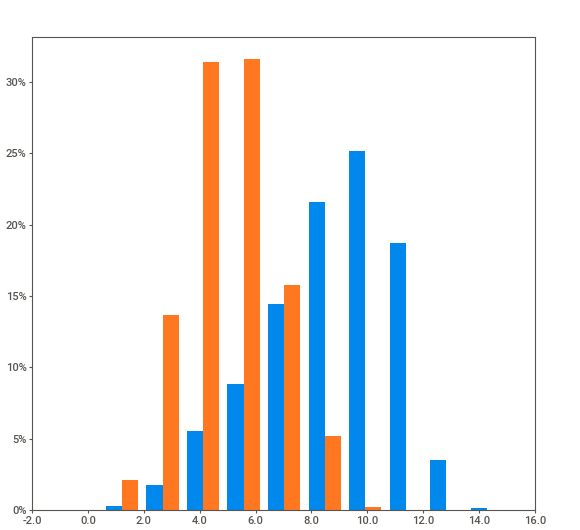
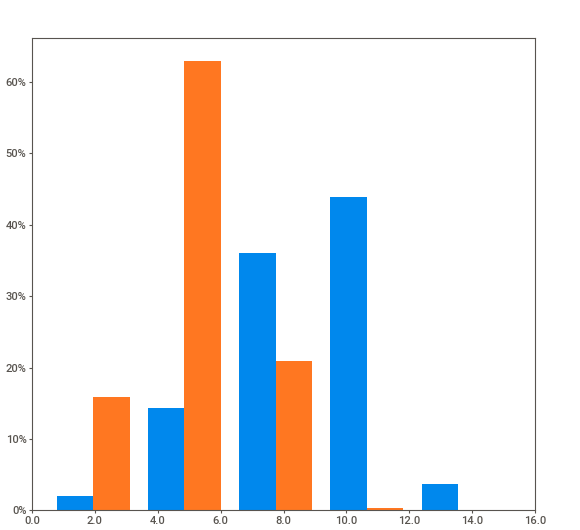
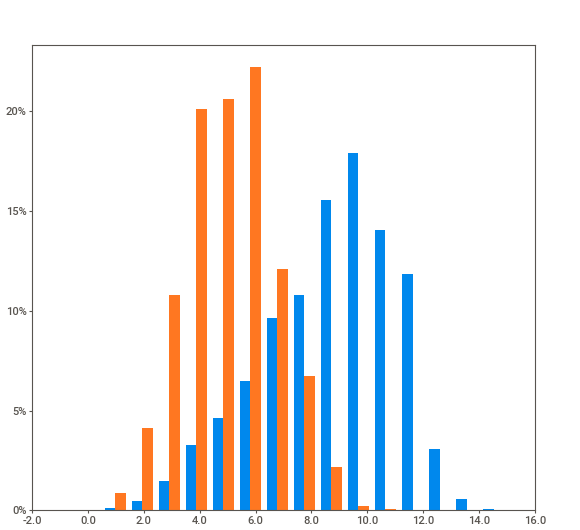
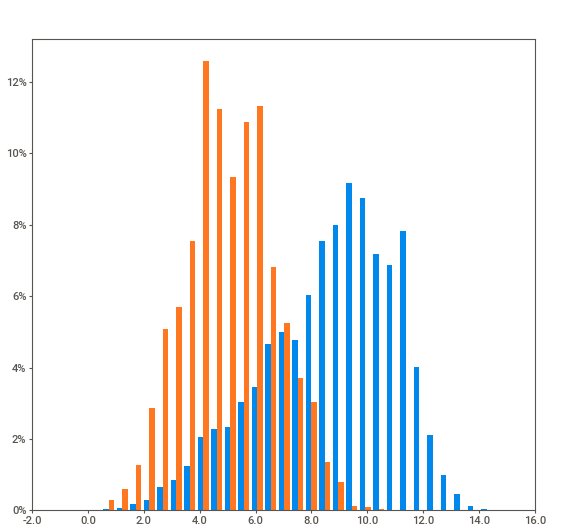
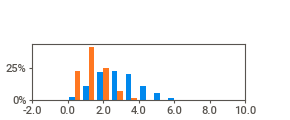
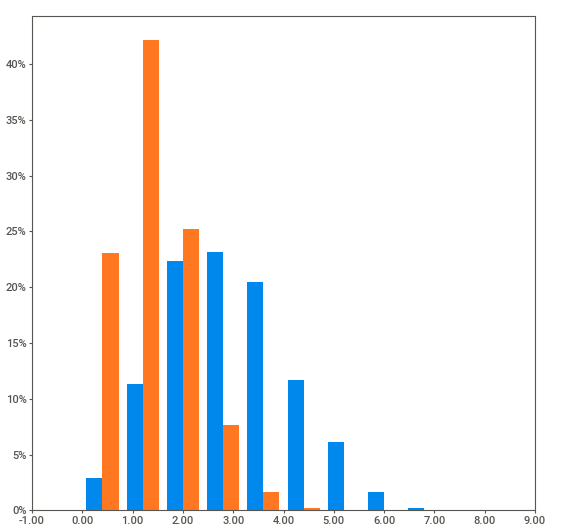
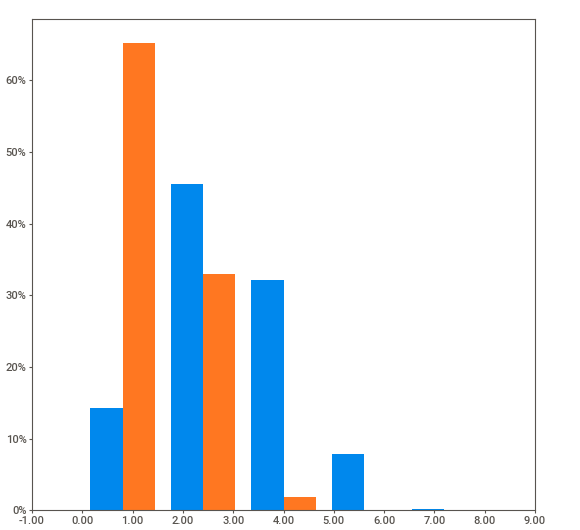
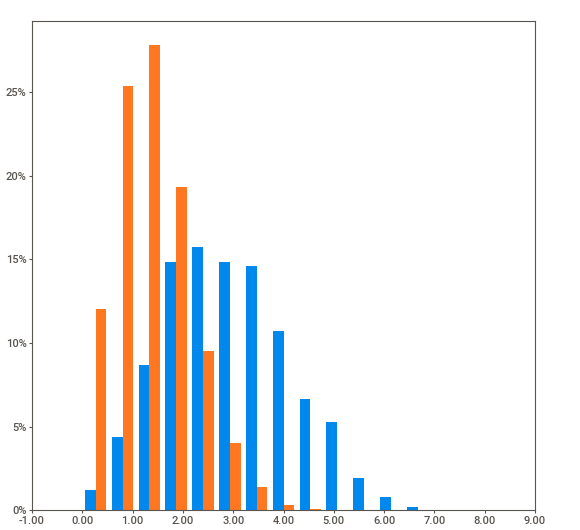
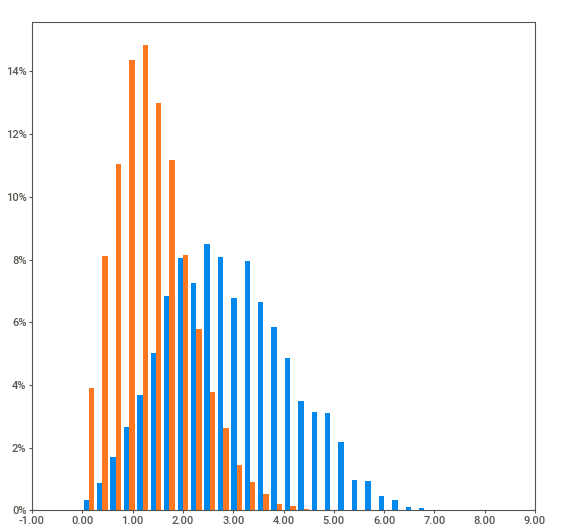
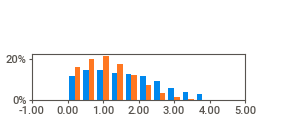
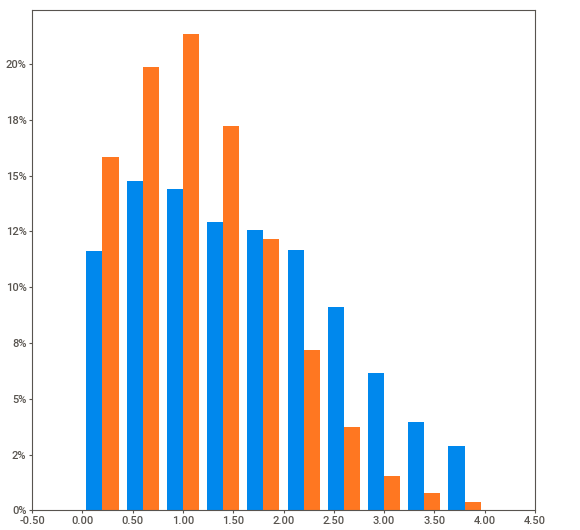
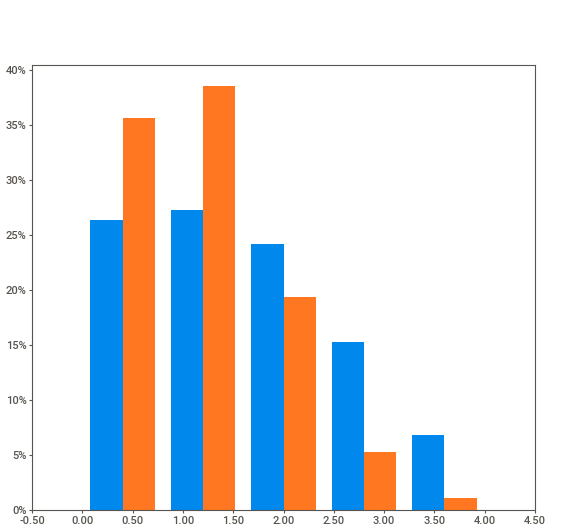
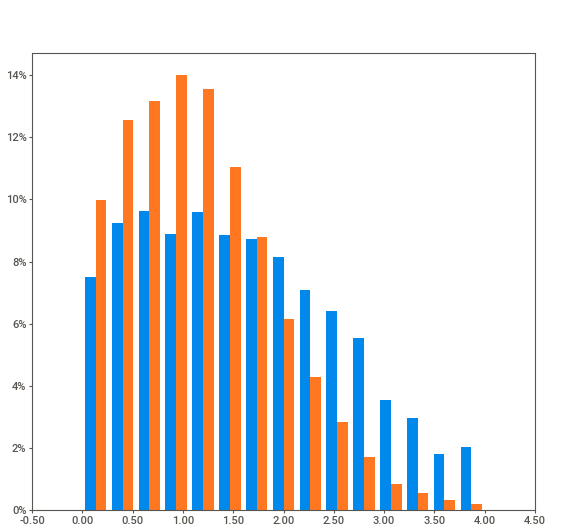
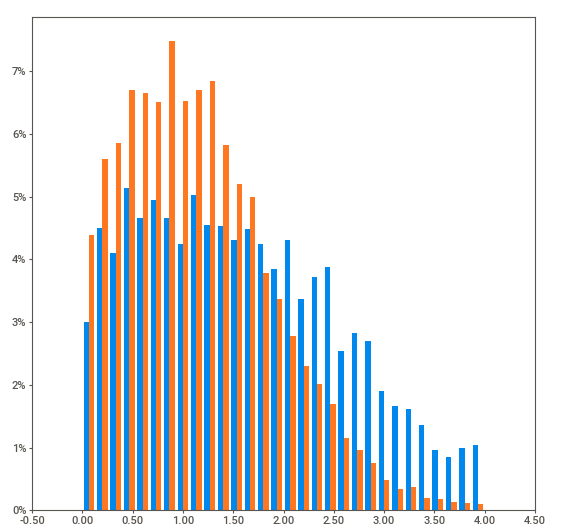
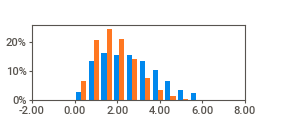
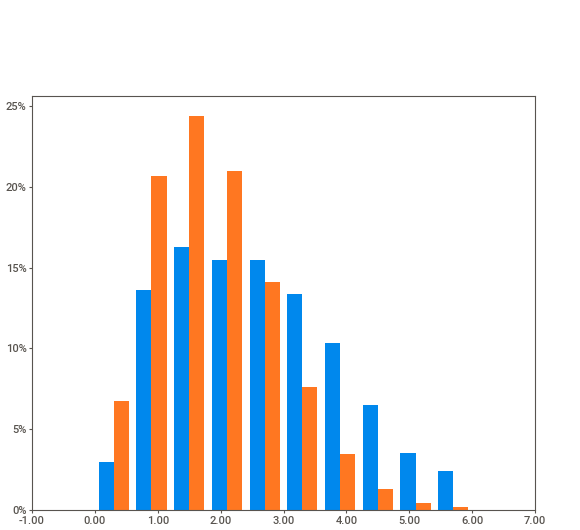
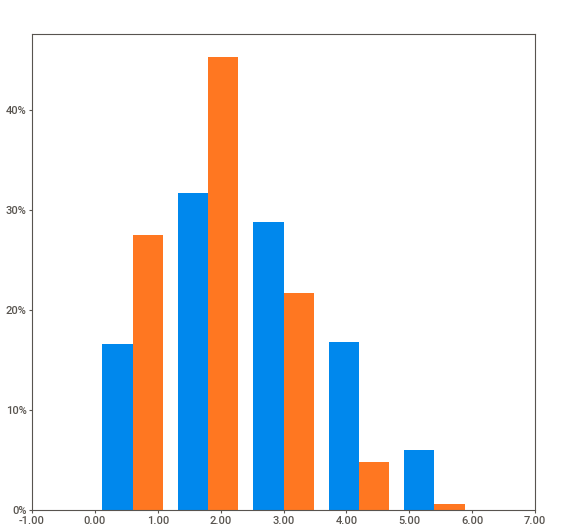
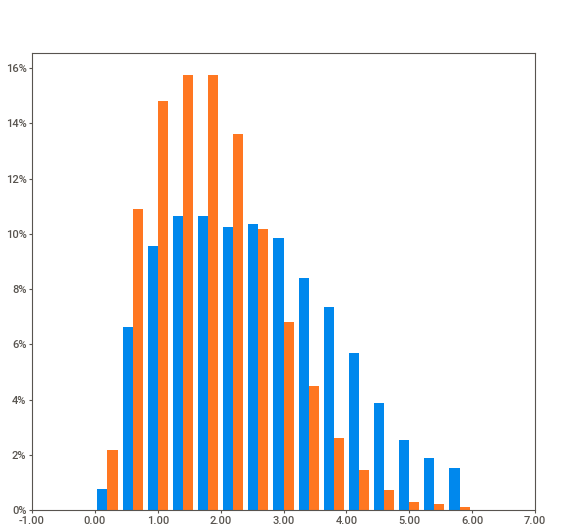
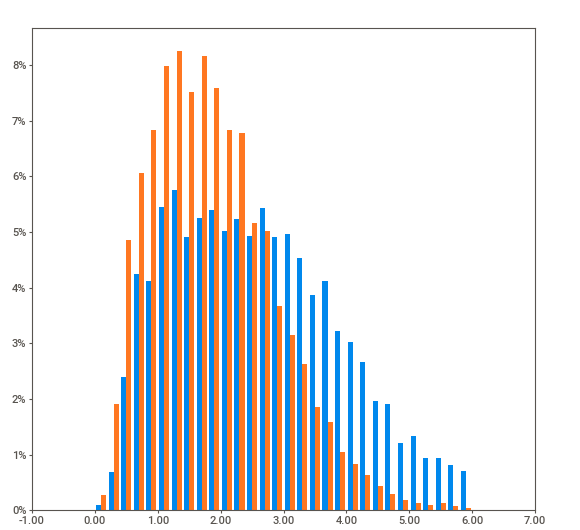
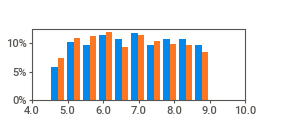
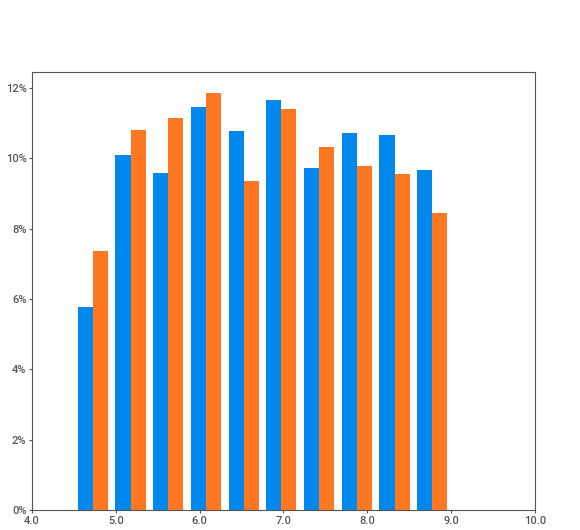
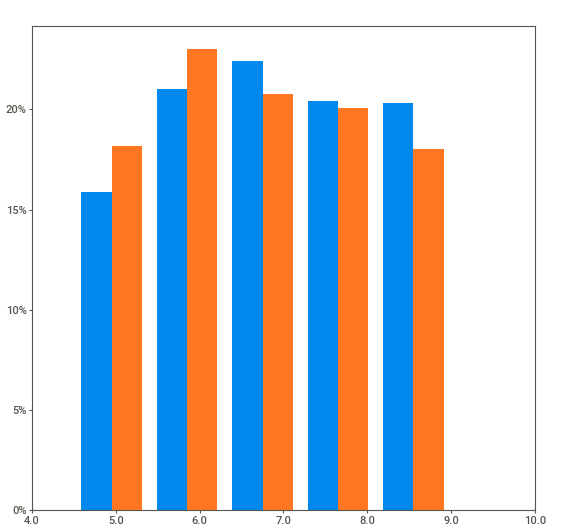
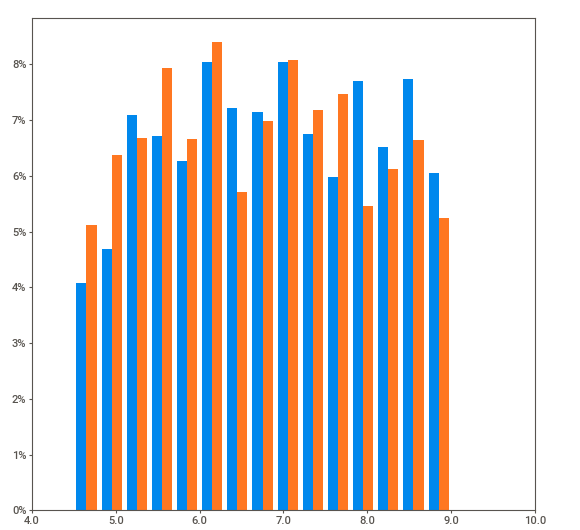
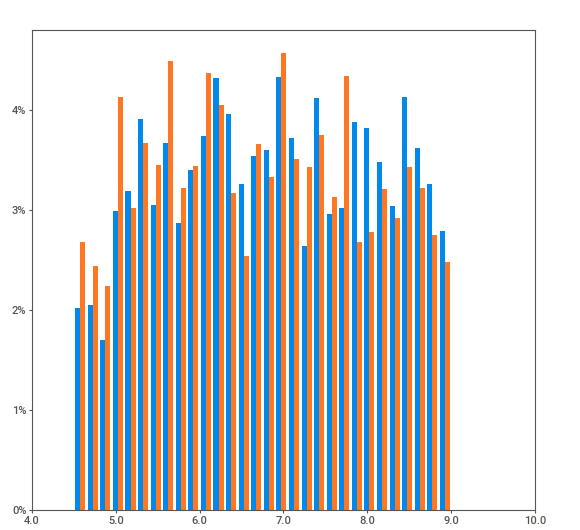
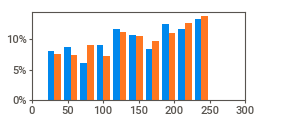
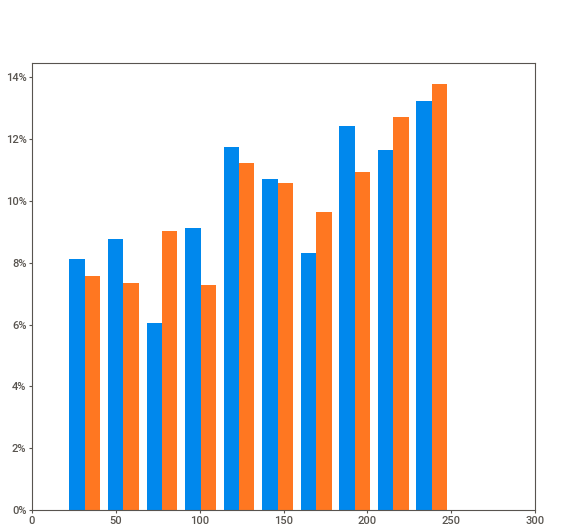
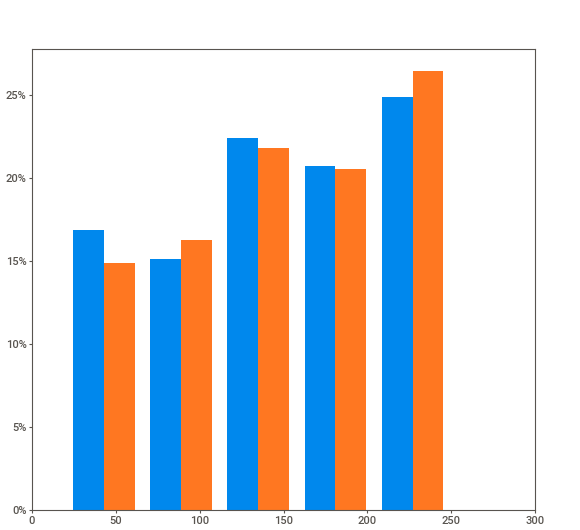
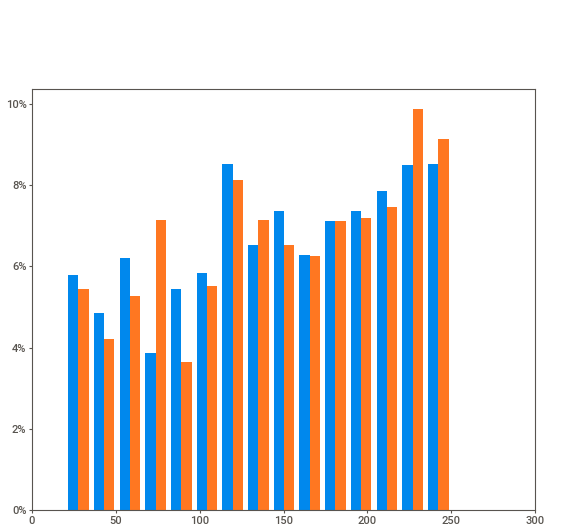
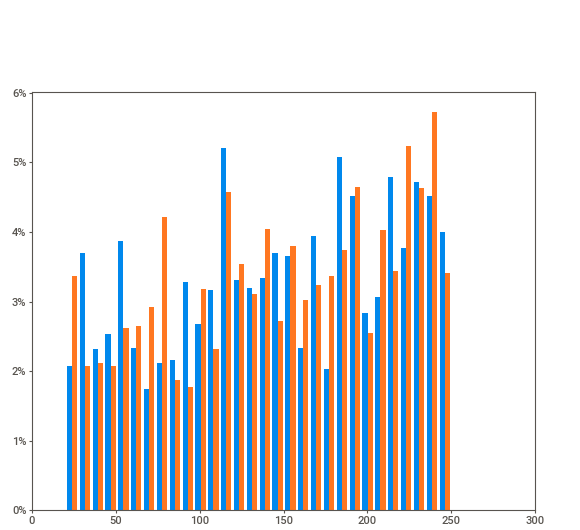
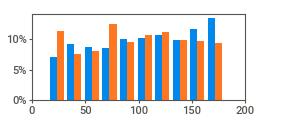
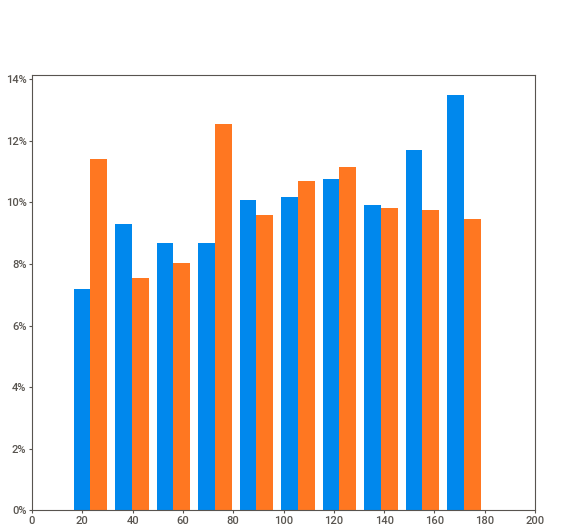
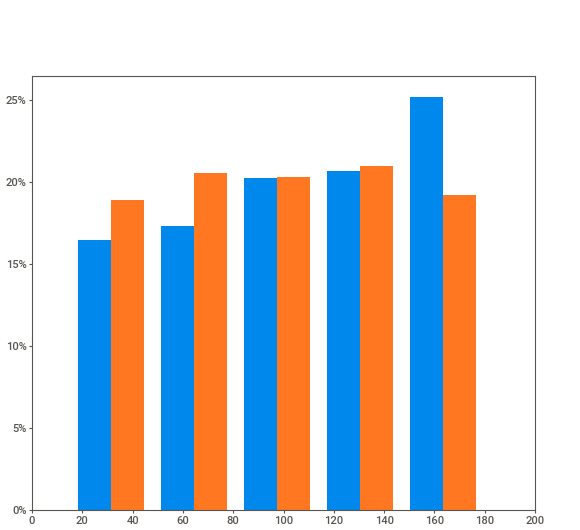
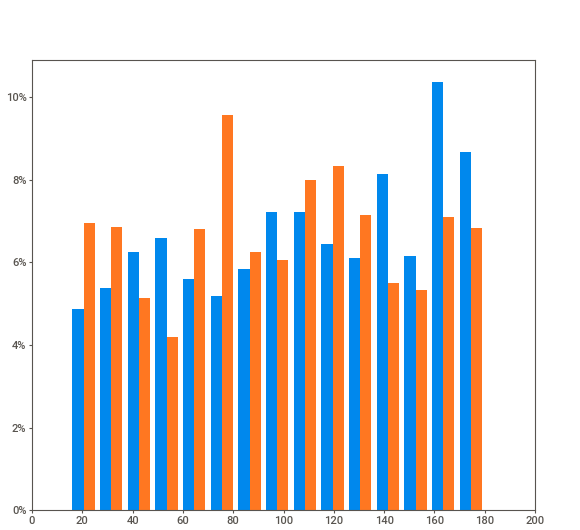
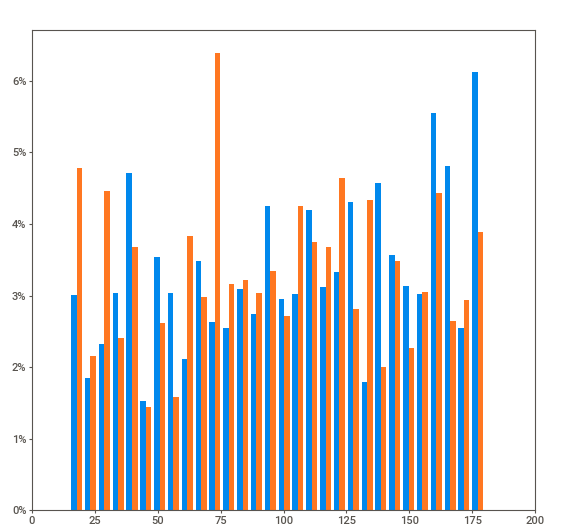
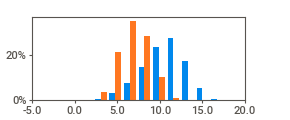
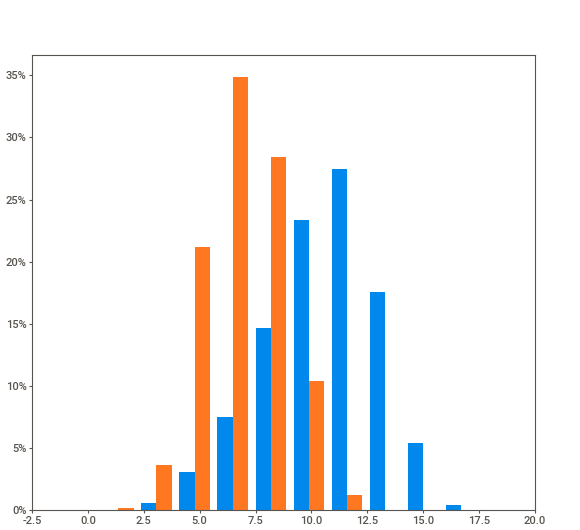
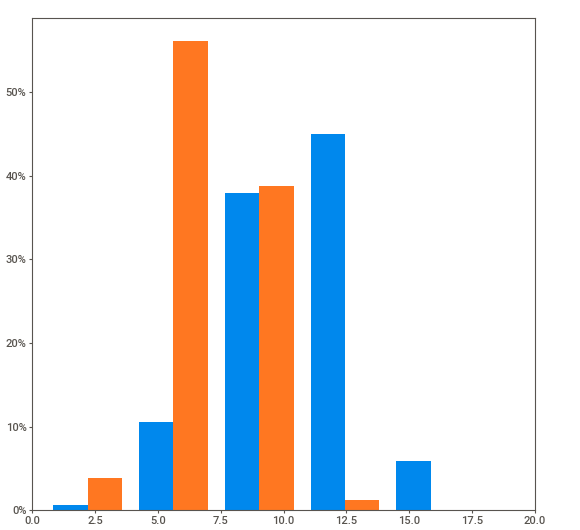
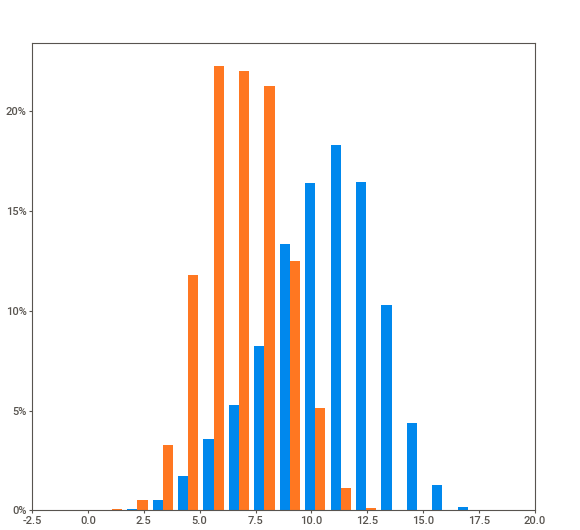
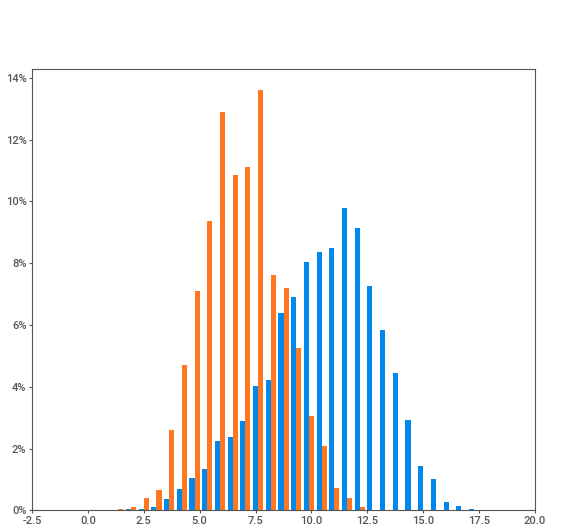
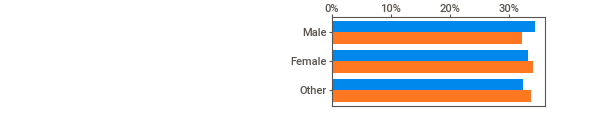
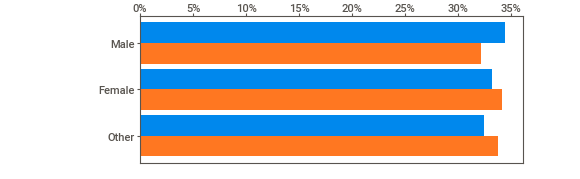
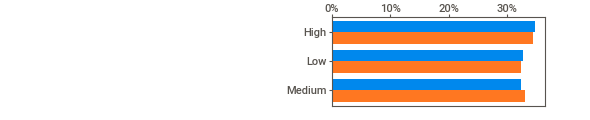
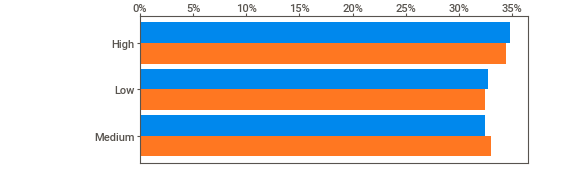
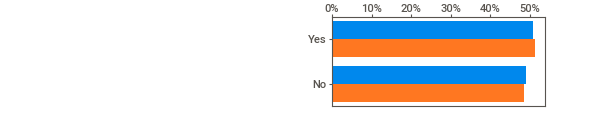
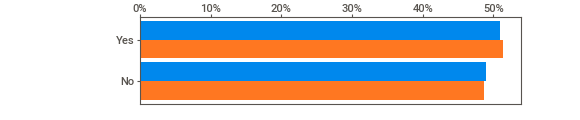
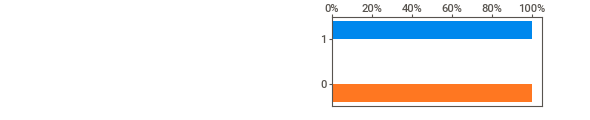
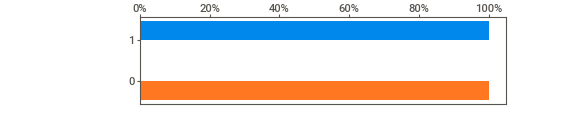
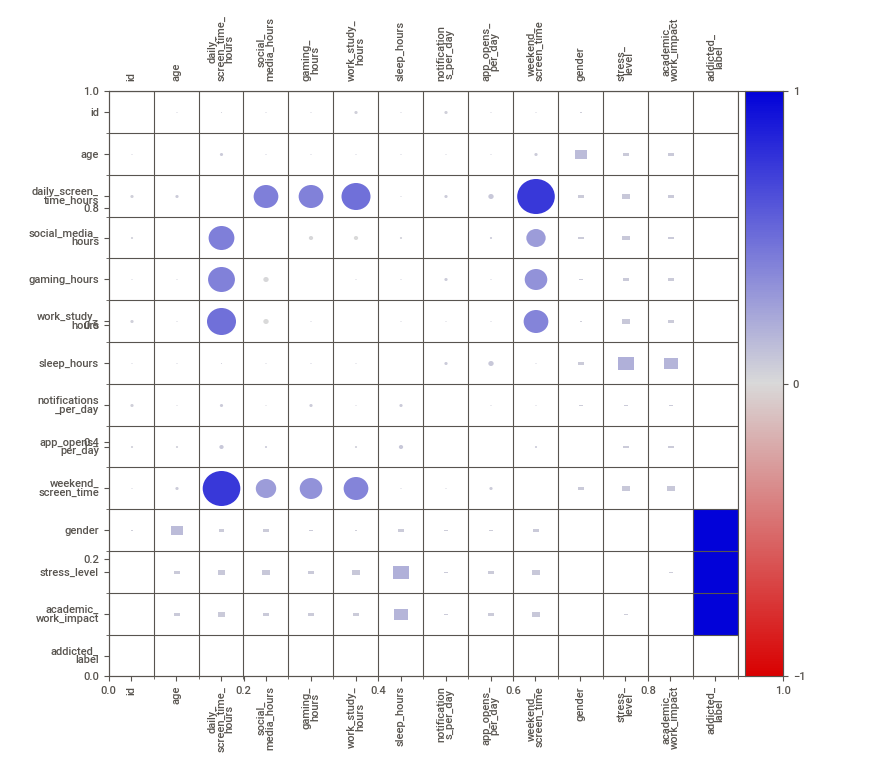
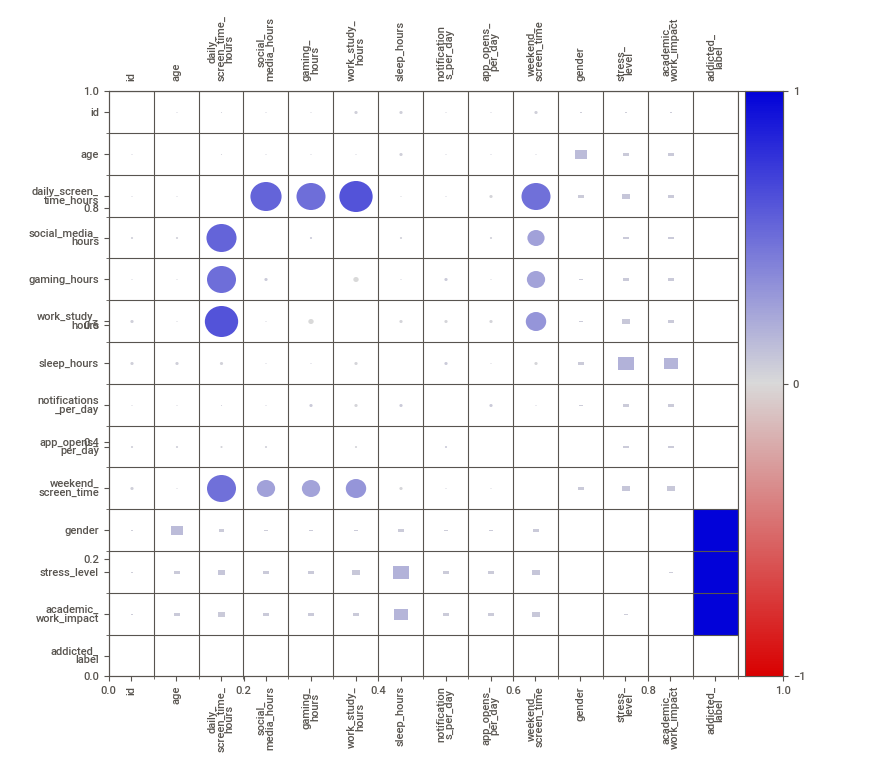

In [8]:
addicted_vs_others_report = sv.compare_intra(
    training_df,
    training_df[TARGET] == 1,
    ["Addicted", "Not Addicted"],
    target_feat=None
)

# Save HTML report file
addicted_vs_others_report.show_html(
    filepath="sweetviz_addicted_intra.html",
    open_browser=False
)

# Render in notebook
addicted_vs_others_report.show_notebook(
    w="100%",
    h=1000,
    scale=0.85
)

## 4. Custom Visualizations (DataVisualizer)

Run our target-aware visualization suite to extract top categorical/numerical signals and plot trends.

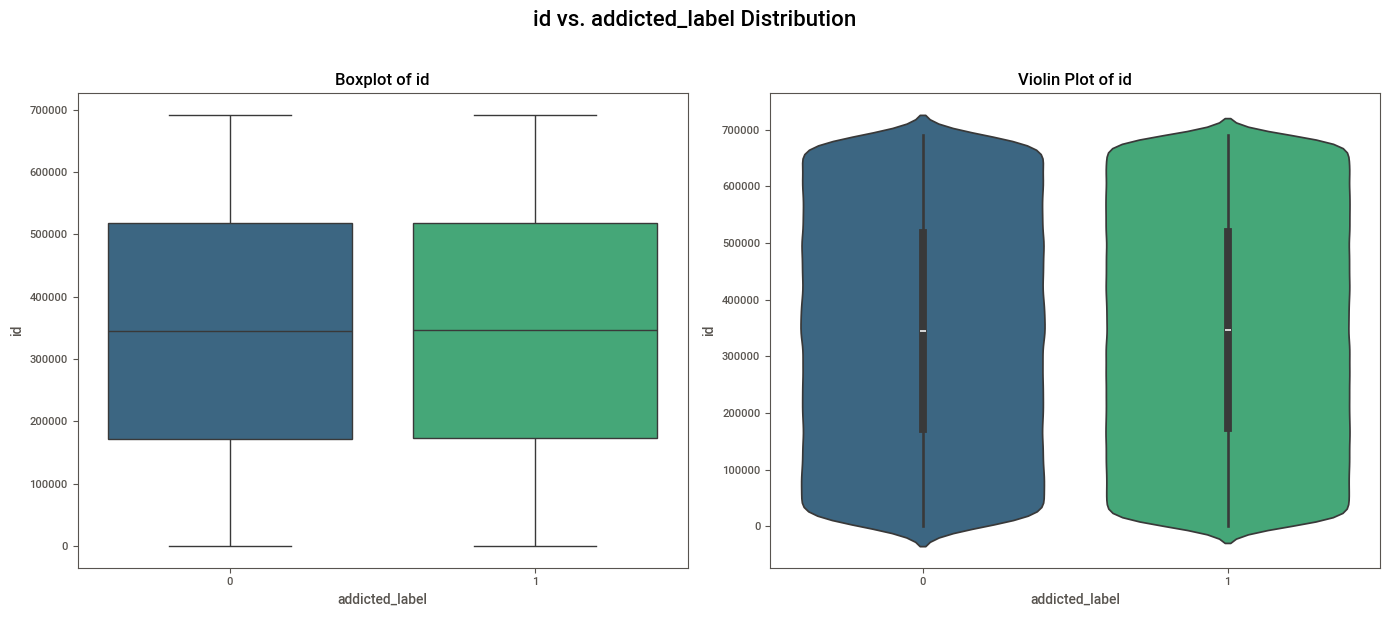

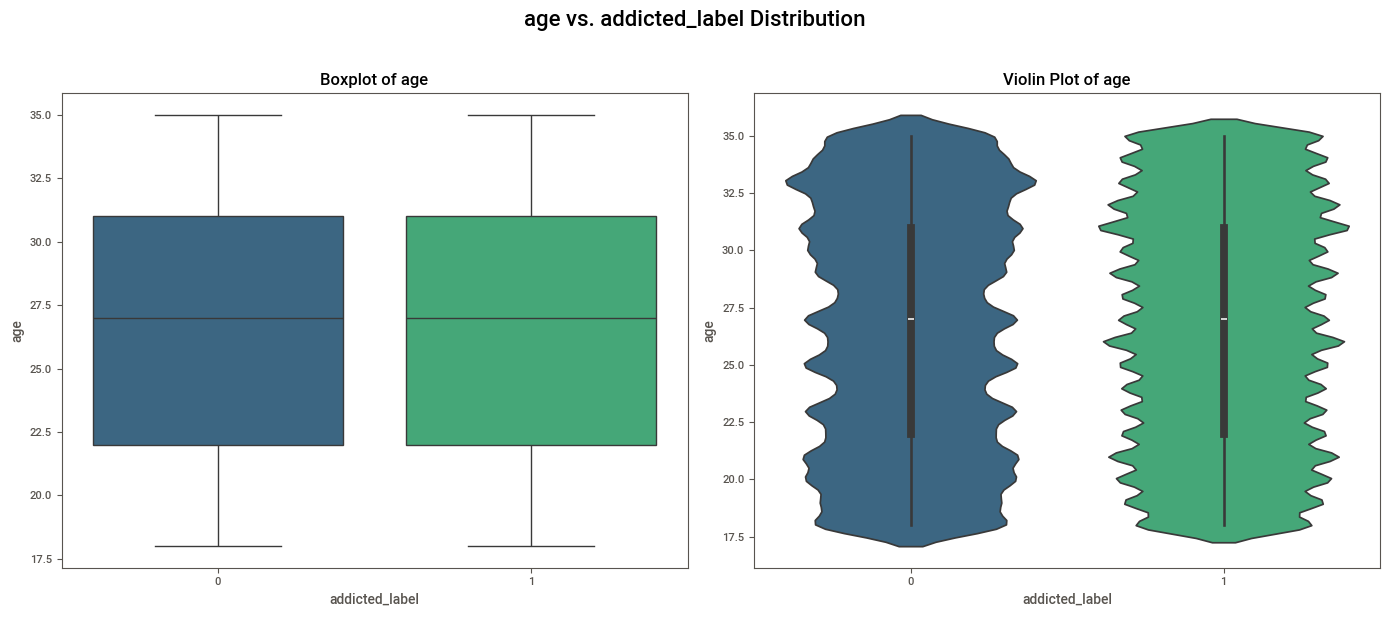

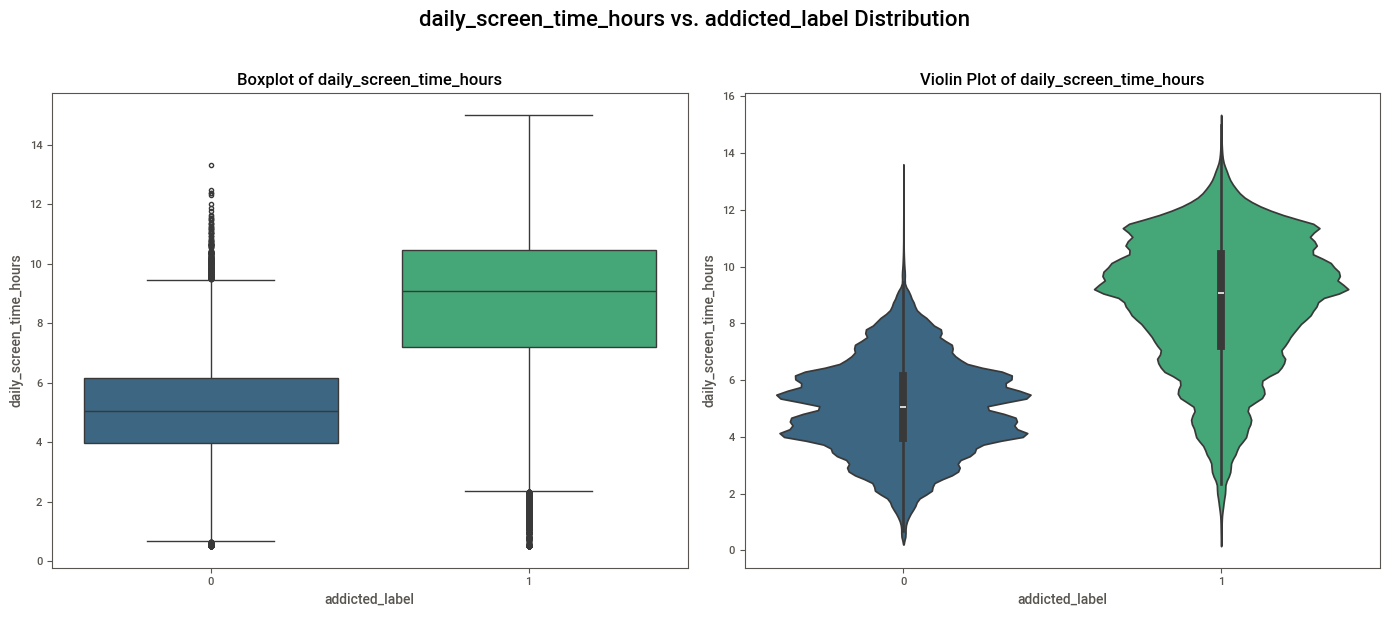

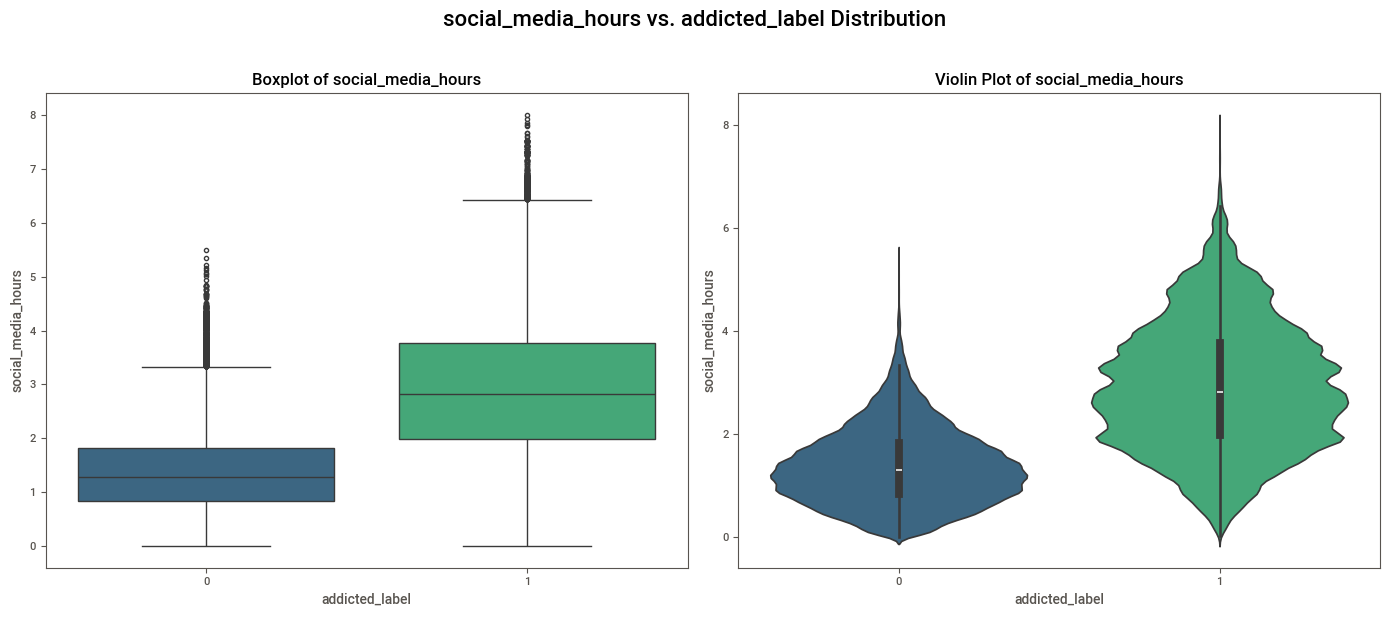

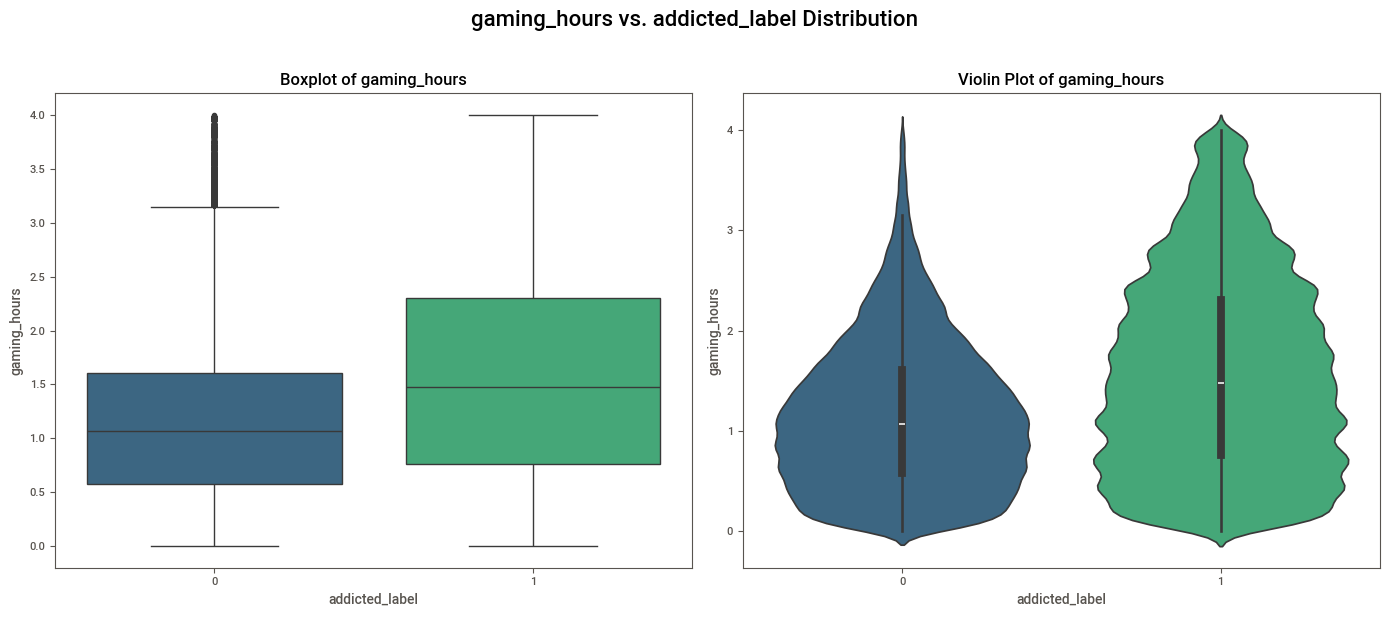

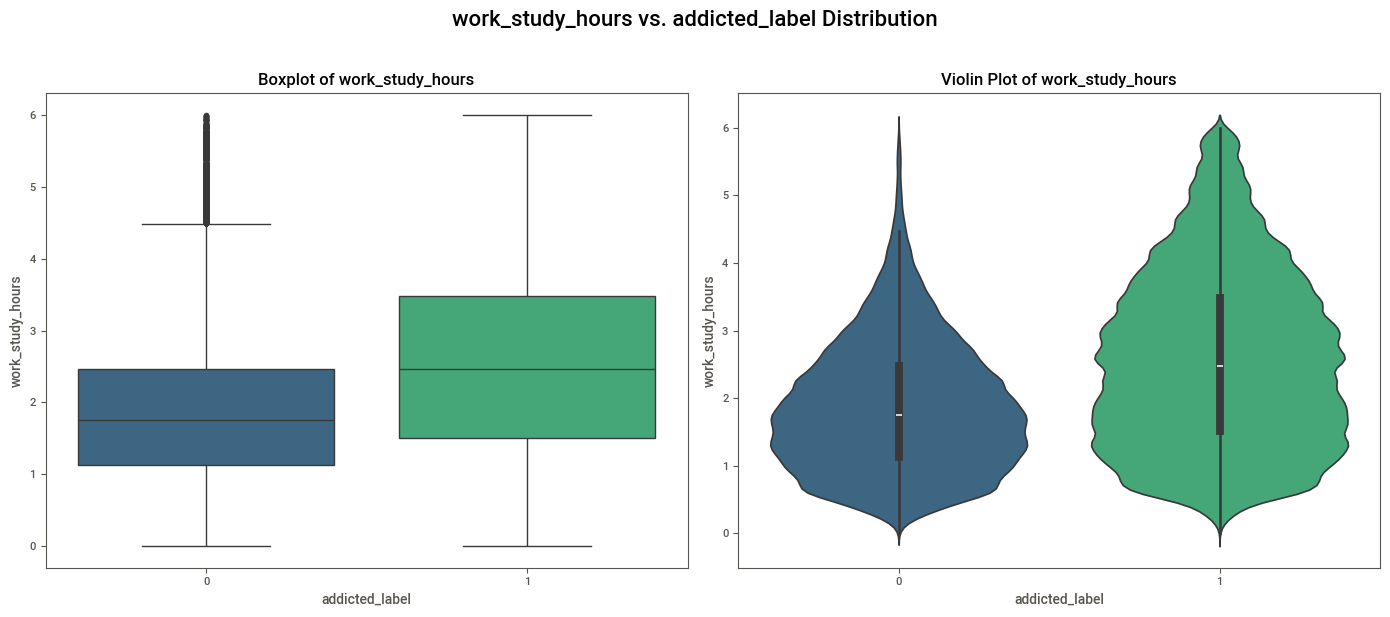

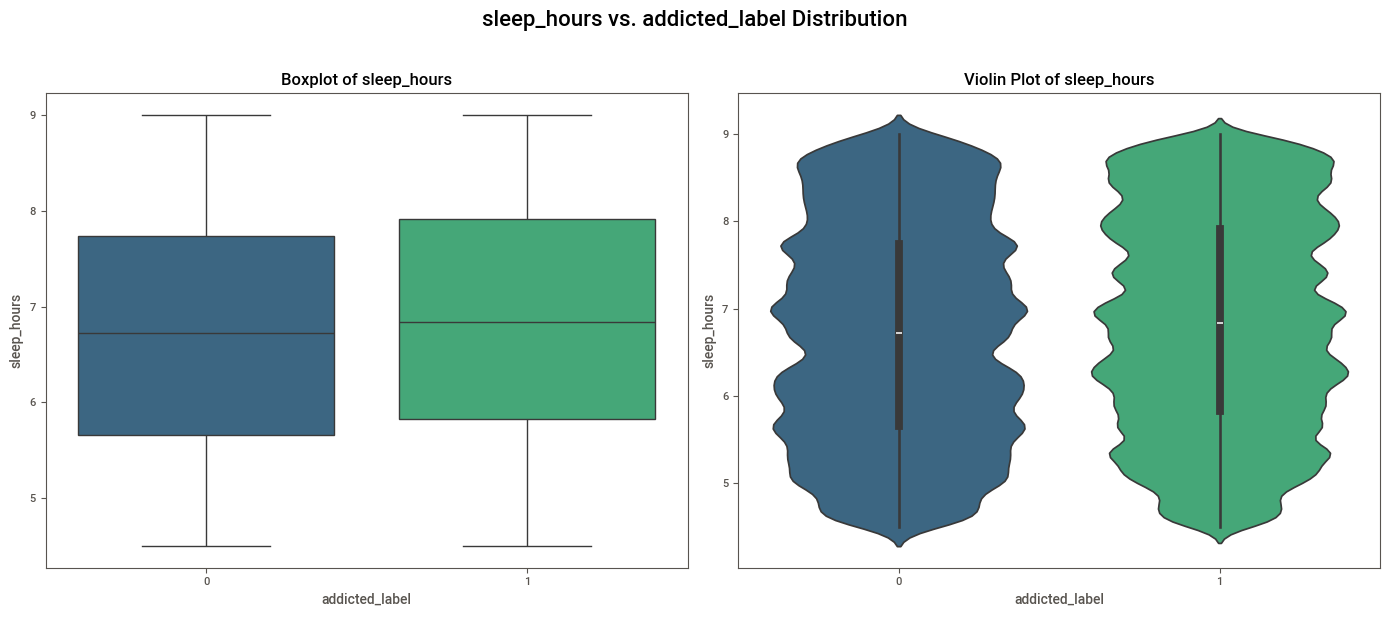

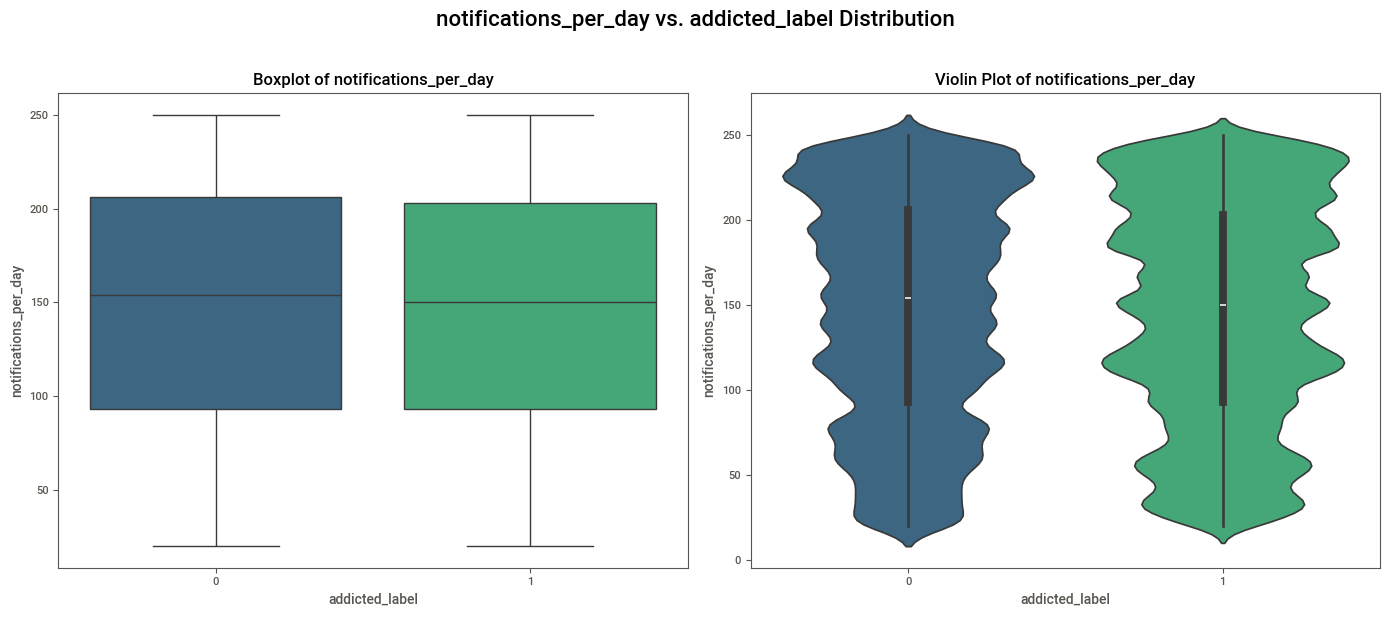

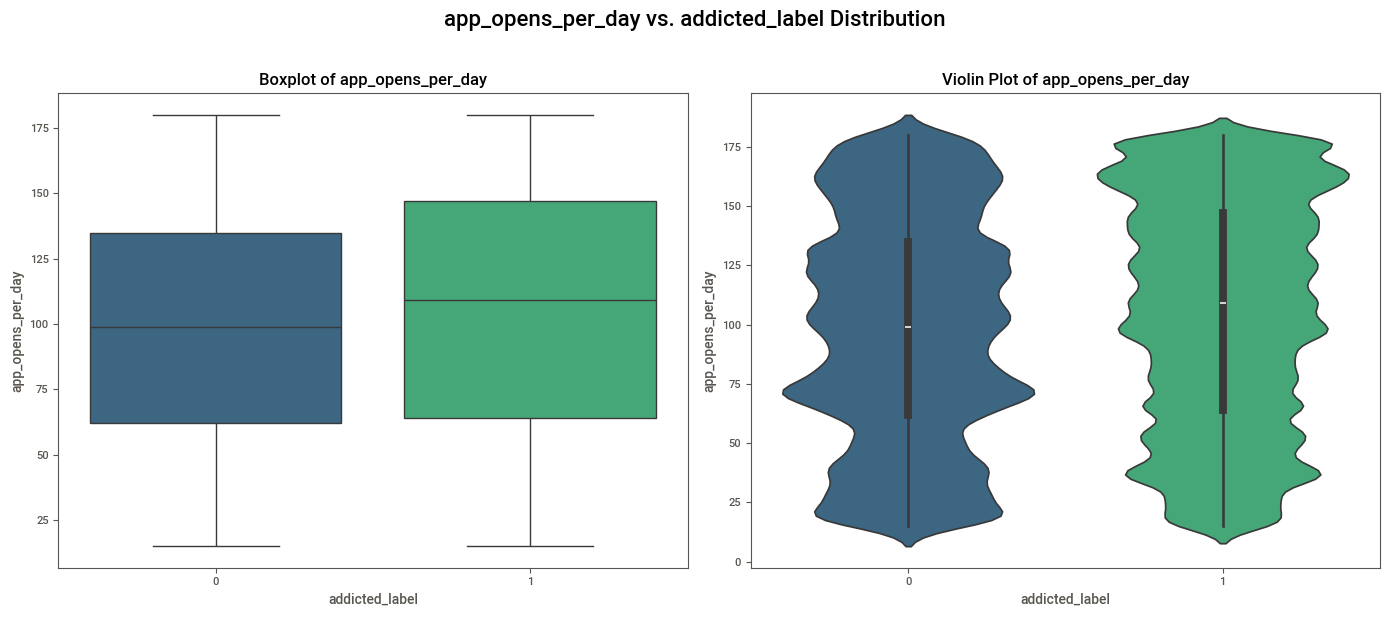

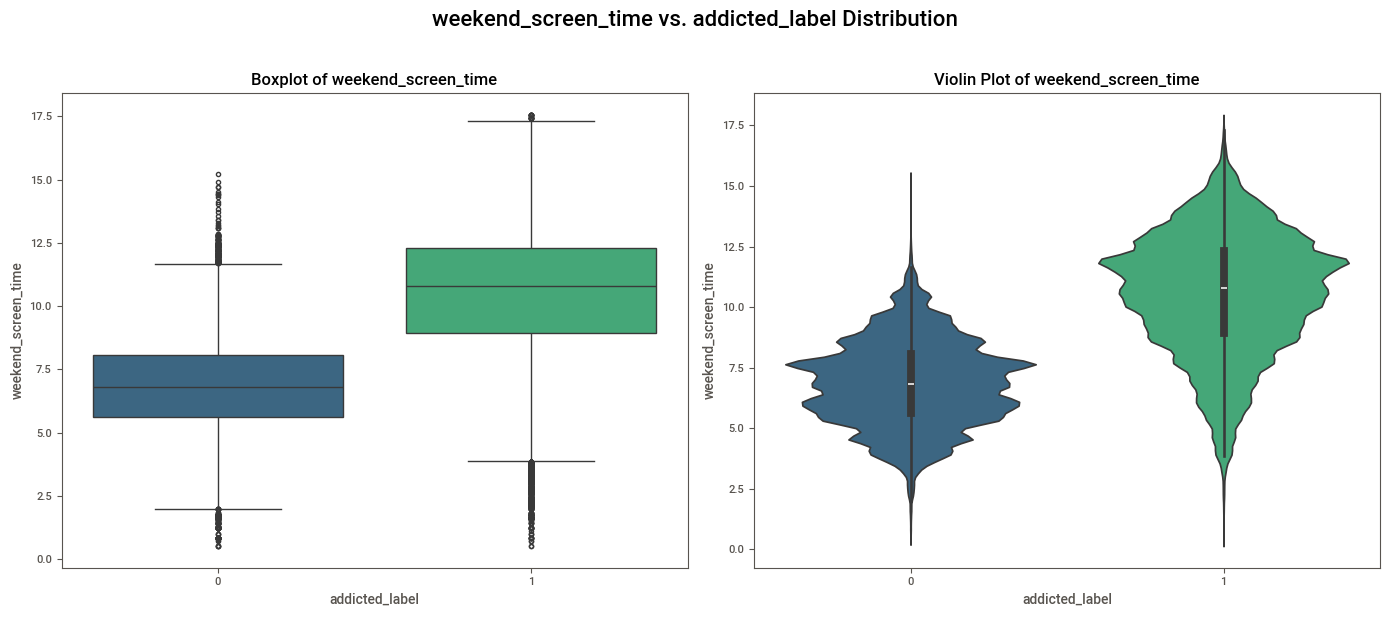

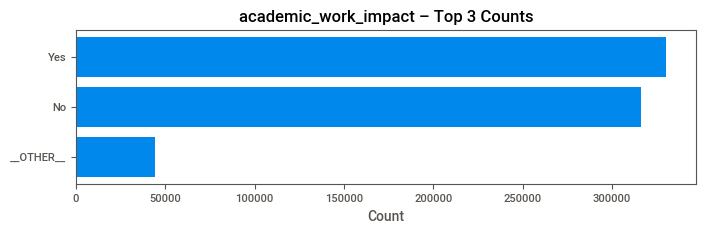

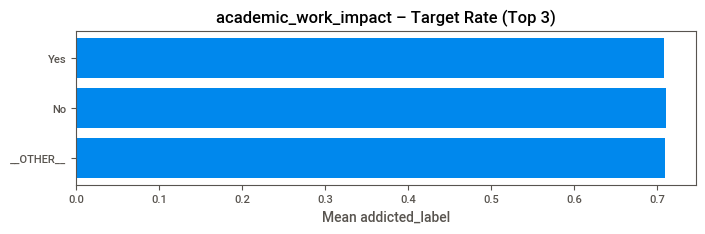

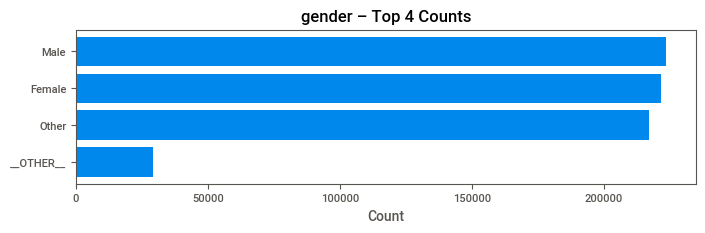

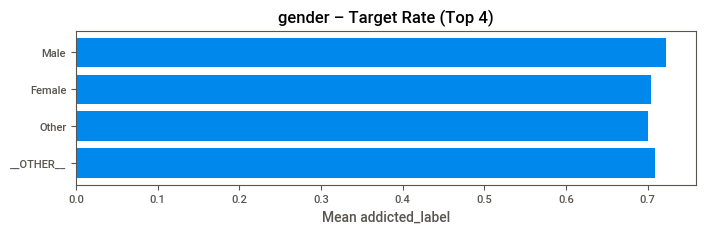

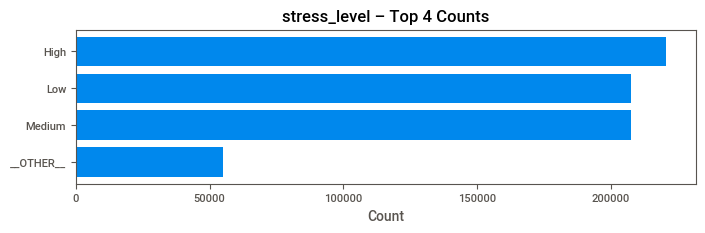

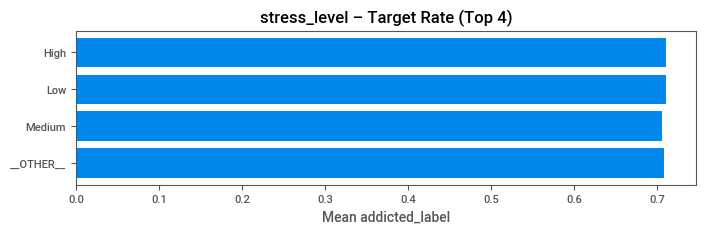

### Numeric x Category Trend

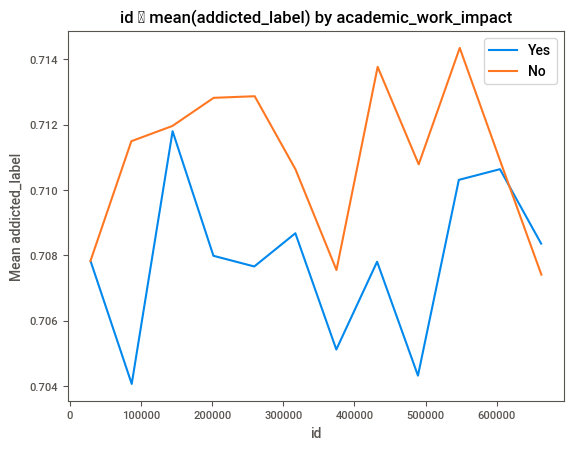

### Category x Category Trend

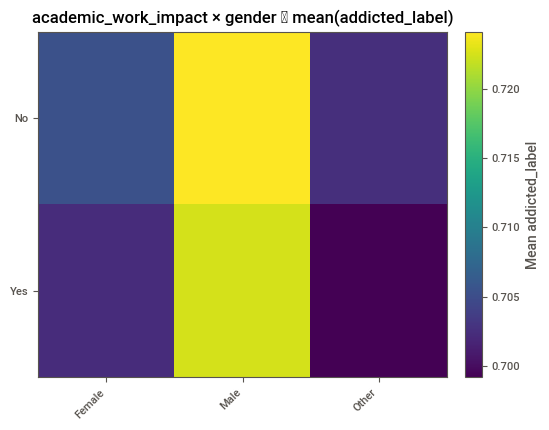

### Feature Signal Ranking

Top numeric (|Spearman|): [('daily_screen_time_hours', 0.6128734473410042), ('weekend_screen_time', 0.5993633404112992), ('social_media_hours', 0.5627198843848257), ('work_study_hours', 0.24362027965578278), ('gaming_hours', 0.19186643841277254), ('app_opens_per_day', 0.06433175798342552), ('sleep_hours', 0.04240351630407031), ('notifications_per_day', -0.012356508798846977), ('age', 0.0035792705980750026), ('id', 0.0010974801968523086)]
Top categorical (range of mean target): [('gender', 0.022178487687926407, 3), ('stress_level', 0.005768169886120056, 3), ('academic_work_impact', 0.0031466311099439537, 2)]


In [9]:
visualizer = DataVisualizer(target=TARGET, seed=helper.primary_seed())
visualizer.run_data_visualization(training_df)

### Correlation and Feature Signal Insights

Spearman rank correlation values between numerical features and `addicted_label` reveal:
1. **Strong Screen-Time Signals**:
   * `daily_screen_time_hours` (Spearman = **`0.6129`**)
   * `weekend_screen_time` (Spearman = **`0.5994`**)
   * `social_media_hours` (Spearman = **`0.5627`**)
2. **Moderate Productivity/Entertainment Signals**:
   * `work_study_hours` (Spearman = **`0.2436`**)
   * `gaming_hours` (Spearman = **`0.1919`**)
3. **Extremely Weak/Flat Signals**:
   * `app_opens_per_day` (Spearman = 0.064), `sleep_hours` (Spearman = 0.042), `notifications_per_day` (Spearman = -0.012), and `age` (Spearman = 0.0036).
   * **Categorical variables** (`gender`, `stress_level`, `academic_work_impact`) show almost identical target rates (~70-72%) across all categories.

**Feature Engineering Strategy**:
* Focus on screen-time ratios (e.g., social media or gaming as a fraction of daily screen time, weekend-to-weekday screen ratio, app opens per screen hour).
* Simple demographic or lifestyle features will likely be ignored by models unless combined into multi-feature interactions (e.g., sleep vs. stress vs. screen time).

## 5. Visualizing Numerical Feature Distributions (Train vs Test)

Overlays KDE plots to visually inspect feature ranges and verify data consistency between splits.

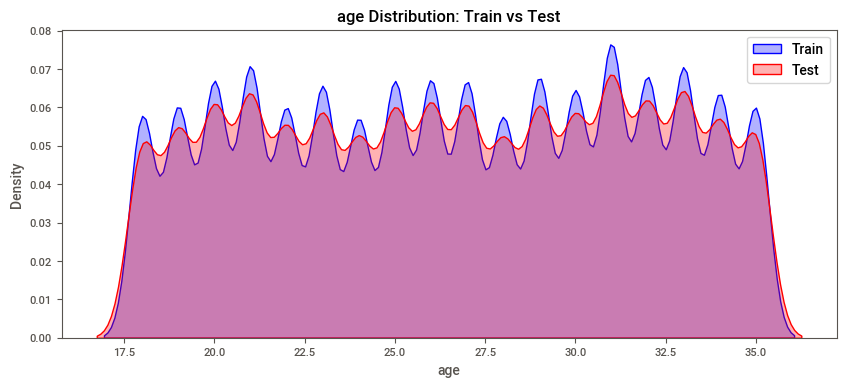

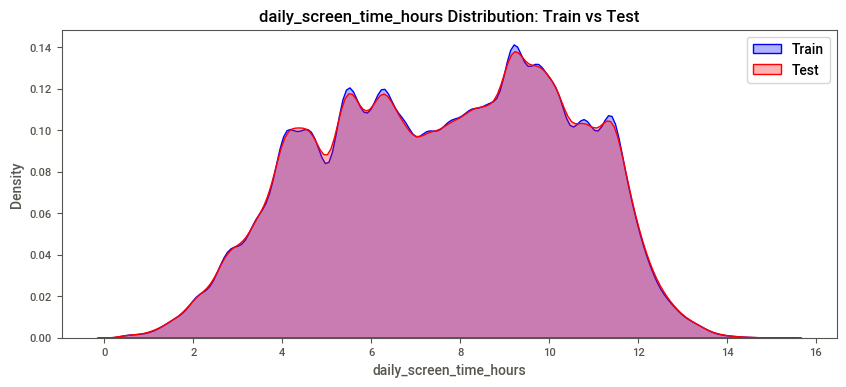

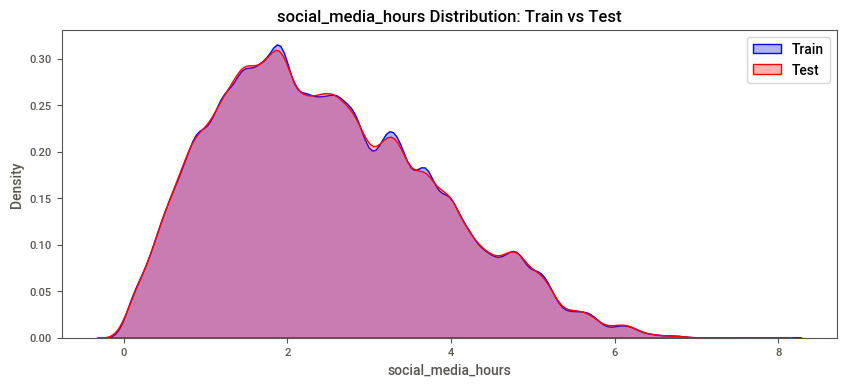

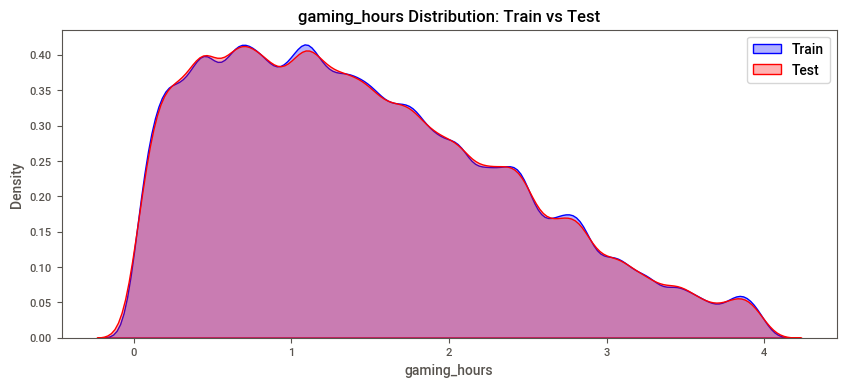

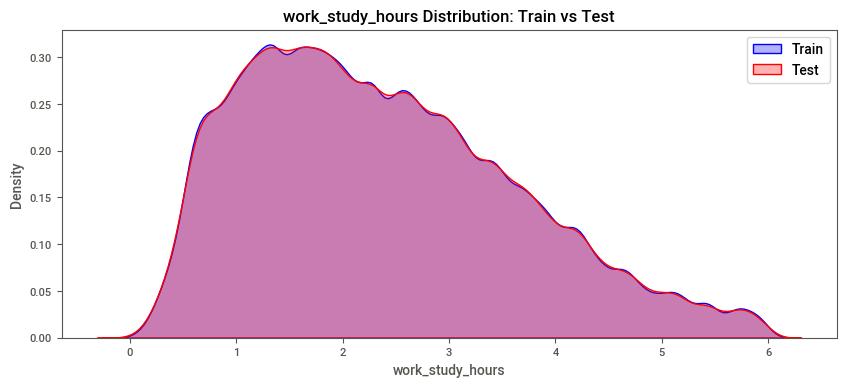

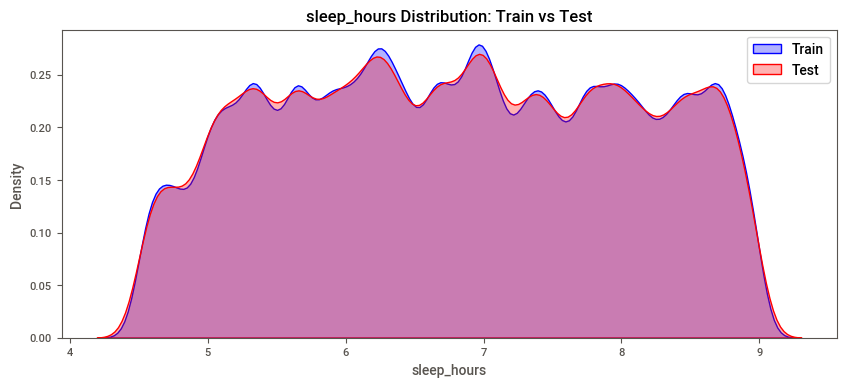

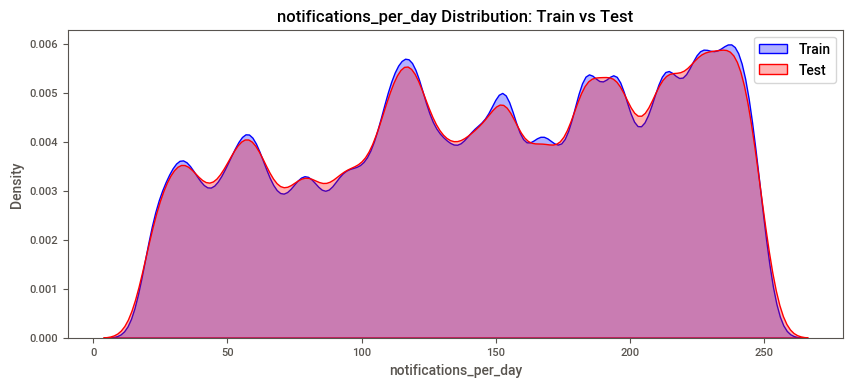

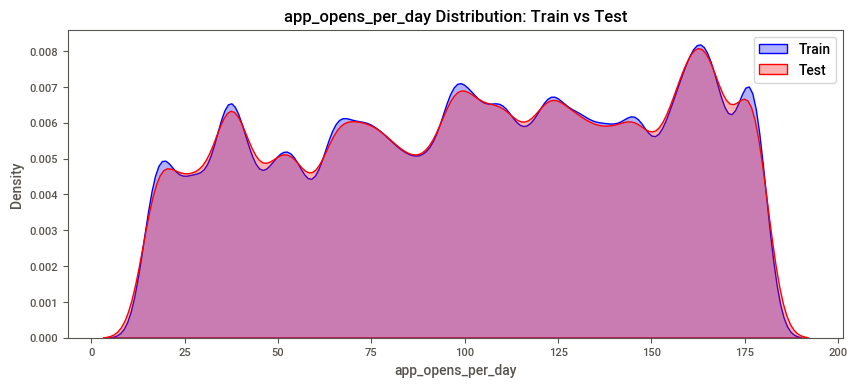

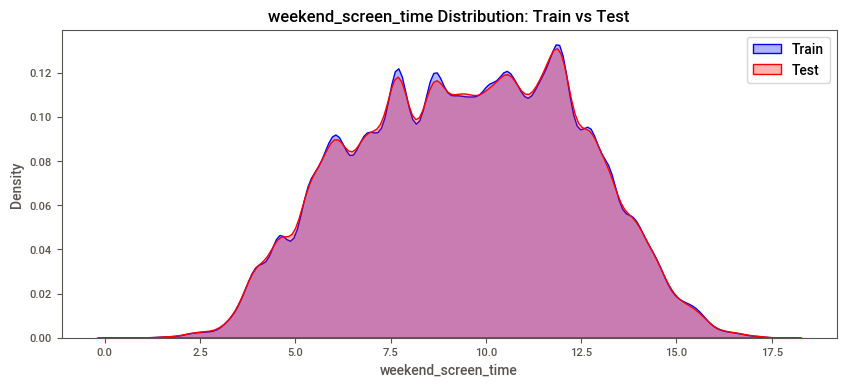

In [10]:
tops = [
    'age',
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time'
]
for top in tops:
    if top in training_df.columns and top in test_df.columns:
        plt.figure(figsize=(10, 4))
        sns.kdeplot(training_df[top].dropna(), label='Train', fill=True, color='blue', alpha=0.3)
        sns.kdeplot(test_df[top].dropna(), label='Test', fill=True, color='red', alpha=0.3)
        plt.title(f'{top} Distribution: Train vs Test')
        plt.xlabel(top)
        plt.ylabel('Density')
        plt.legend()
        plt.show()